# Student Dropout Prediction - Stage 1


In [ ]:
# install necessary libraries
#!pip install keras optuna
#!pip install keras_tuner

import os
import random
import ssl
import sys
from pathlib import Path

import joblib
import keras_tuner as kt
import matplotlib.pyplot as plt
import numpy as np
import optuna
import optuna.visualization as vis
import pandas as pd
import requests
import seaborn as sns
import shap
import tensorflow as tf
import xgboost as xgb
from IPython.display import HTML, display
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras import mixed_precision
from sklearn.metrics import roc_auc_score
from tensorflow.keras.callbacks import EarlyStopping as KerasEarlyStopping
from xgboost.callback import EarlyStopping as XgbEarlyStopping

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / 'src').exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
else:
    raise FileNotFoundError('Could not locate the repository root from the current working directory.')

from src.config import (
    DEFAULT_RANDOM_SEED,
    RUNTIME_DEFAULTS,
    STABILITY_SEEDS,
    TARGET_COLUMN,
    TUNING_ARTIFACT_FILENAMES,
)
from src.lookups import (
    COUNTRY_TO_REGION,
    DEGREE_BACHELOR_SET,
    DEGREE_LEVEL_KEEP_SET,
    DEGREE_MAP,
    DEGREE_MASTER_SET,
    DEGREE_PROFESSIONAL_SET,
)
from src.notebook_helpers import (
    analyze_hp_importance,
    build_binary_classifier,
    build_models_to_plot,
    choose_n_jobs,
    compute_confusion_matrix_elements,
    compute_performance_metrics,
    create_train_val_test_split_and_scale,
    evaluate_and_store_model,
    plot_confusion_matrix,
    plot_distributions_and_qq,
    plot_dropout_rate_by_category,
    plot_grouped_feature_importance,
    plot_hyperparameter_relationships,
    plot_model_confusion_matrix,
    plot_roc_and_pr_curves,
    print_model_metrics,
    set_seed,
)
from src.paths import (
    DATA_DIR,
    FIGURES_DIR,
    MODELS_DIR,
    PROJECT_ROOT,
    TUNING_DIR,
    ensure_directories,
    get_stage_data_path,
    get_stage_paths,
)
from src.tuning_utils import (
    best_params_record,
    load_model_weights,
    load_saved_best_params,
    run_keras_tuner as shared_run_keras_tuner,
    run_optuna_xgb as shared_run_optuna_xgb,
    save_json,
    tuner_trials_to_dataframe,
)

STAGE_NAME = 'stage_1'
stage_paths = get_stage_paths(STAGE_NAME)
STAGE_DATA_PATH = get_stage_data_path(STAGE_NAME)
DATA_CACHE_DIR = stage_paths['DATA_CACHE_DIR']
STAGE_TUNING_DIR = stage_paths['STAGE_TUNING_DIR']
XGB_TUNING_DIR = stage_paths['XGB_TUNING_DIR']
NN_TUNING_DIR = stage_paths['NN_TUNING_DIR']
STAGE_MODEL_DIR = stage_paths['STAGE_MODEL_DIR']
XGB_MODEL_DIR = stage_paths['XGB_MODEL_DIR']
NN_MODEL_DIR = stage_paths['NN_MODEL_DIR']

ensure_directories(
    DATA_CACHE_DIR,
    TUNING_DIR,
    STAGE_TUNING_DIR,
    XGB_TUNING_DIR,
    NN_TUNING_DIR,
    MODELS_DIR,
    STAGE_MODEL_DIR,
    XGB_MODEL_DIR,
    NN_MODEL_DIR,
    FIGURES_DIR,
)

LOAD_SAVED_TUNING = True
RUN_XGB_TUNING = False
RUN_NN_TUNING = False
RESUME_XGB_TUNING = True
RESUME_NN_TUNING = True

XGB_N_TRIALS = 2000
NN_INITIAL_N_TRIALS = 2000
NN_N_TRIALS = 200

RELOAD_DATA_CACHE = RUNTIME_DEFAULTS['RELOAD_DATA_CACHE']

SEED = DEFAULT_RANDOM_SEED
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

degree_map = DEGREE_MAP
keep_levels = DEGREE_LEVEL_KEEP_SET
bachelors = DEGREE_BACHELOR_SET
masters = DEGREE_MASTER_SET
professional = DEGREE_PROFESSIONAL_SET
country_to_region = COUNTRY_TO_REGION


def run_keras_tuner(
    max_trials,
    project_name,
    X_train,
    y_train,
    X_val,
    y_val,
    executions_per_trial=1,
    overwrite=False,
    hp_bs=64,
    artifact_dir=None,
    run_search=True,
    load_saved=True,
    resume_search=True,
    artifact_prefix='',
):
    def build_model_for_tuner(hp):
        return build_binary_classifier(
            input_dim=X_train.shape[1],
            units=hp.Int('units', **SEARCH_SPACE['units']),
            layers=hp.Int('layers', **SEARCH_SPACE['layers']),
            activation=hp.Choice('activation', SEARCH_SPACE['activation']),
            optimizer=hp.Choice('optimizer', SEARCH_SPACE['optimizer']),
            lr=hp.Choice('lr', SEARCH_SPACE['lr']),
            dropout=hp.Float('dropout', **SEARCH_SPACE['dropout']),
            l2_strength=hp.Choice('l2_strength', SEARCH_SPACE['l2_strength']),
        )

    early_stop = KerasEarlyStopping(
        monitor='val_auc',
        mode='max',
        patience=5,
        restore_best_weights=True,
        min_delta=1e-4,
    )

    return shared_run_keras_tuner(
        kt_module=kt,
        build_model=build_model_for_tuner,
        max_trials=max_trials,
        project_name=project_name,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        early_stopping_callback=early_stop,
        seed=SEED,
        artifact_dir=artifact_dir or NN_TUNING_DIR,
        executions_per_trial=executions_per_trial,
        overwrite=overwrite,
        hp_bs=hp_bs,
        run_search=run_search,
        load_saved=load_saved,
        resume_search=resume_search,
        artifact_prefix=artifact_prefix,
    )


def run_optuna_xgb(
    n_trials,
    study_name,
    X_train,
    y_train,
    X_val,
    y_val,
    seed=42,
    overwrite=False,
    n_estimators=3000,
    early_stopping_rounds=30,
    n_jobs=-1,
    artifact_dir=None,
    run_search=True,
    load_saved=True,
    resume_search=True,
):
    return shared_run_optuna_xgb(
        study_name=study_name,
        search_space=XGB_SEARCH_SPACE,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        artifact_dir=artifact_dir or XGB_TUNING_DIR,
        model_dir=XGB_MODEL_DIR,
        seed=seed,
        overwrite=overwrite,
        n_trials=n_trials,
        n_estimators=n_estimators,
        early_stopping_rounds=early_stopping_rounds,
        n_jobs=n_jobs,
        run_search=run_search,
        load_saved=load_saved,
        resume_search=resume_search,
        early_stopping_callback_factory=lambda rounds: XgbEarlyStopping(
            rounds=rounds,
            metric_name='auc',
            maximize=True,
        ),
    )


# Stage 1 data

## Business Background

This dataset is Stage 1 of a three-stage student progression modelling framework.

Stage 1 contains applicant and course-level information that is known at the point of application or admission, prior to programme commencement. 

The objective of this stage is to develop a predictive model that estimates the risk of student drop-out using only intake-available features.

A structured, data-centric approach to feature engineering and selection will be applied to ensure:

- Removal of redundant or high-cardinality noise features
- Appropriate handling of missing values
- Controlled encoding of categorical variables
- Avoidance of temporal leakage


A model with optimised performance metrics that are aligned to minimising the risk of missed opportunities for early intervention measures will help to improve student retention and performance. For example using measures that minimise the risk of false negatives (i.e., failing to identify at-risk students), rather than relying on overall accuracy alone.

An optimised and well-generalised Stage 1 model can support proactive engagement strategies, enabling efficient implementation of intervention measures to improve overall student retention outcomes.

## Data loading

In [52]:

CACHE_PATH = DATA_CACHE_DIR / 'stage_1_data.h5'

hdf_key = 'stage_1_data'

if not RELOAD_DATA_CACHE and CACHE_PATH.exists():
    try:
        stage_1_data = pd.read_hdf(CACHE_PATH, hdf_key)
        print(f'Loaded cached Stage 1 data from {CACHE_PATH}')
    except (OSError, ValueError, KeyError) as e:
        print(f'Failed to load cached Stage 1 data, reloading from CSV: {e}')
        stage_1_data = pd.read_csv(STAGE_DATA_PATH)
        stage_1_data.to_hdf(CACHE_PATH, key=hdf_key, mode='w')
        print(f'Rebuilt cache at {CACHE_PATH}')
else:
    stage_1_data = pd.read_csv(STAGE_DATA_PATH)
    stage_1_data.to_hdf(CACHE_PATH, key=hdf_key, mode='w')
    print(f'Loaded Stage 1 public dataset and refreshed cache at {CACHE_PATH}')

stage_1_data_unmodified = stage_1_data.copy()


Loaded cached Stage 1 data from /home/alextd/projects/student-dropout-prediction/data/cache/stage_1_data.h5


In [53]:
# Display the first few rows of the dataset
stage_1_data.head()


,CentreName,LearnerCode,BookingType,LeadSource,DiscountType,Gender,Age,Nationality,CourseLevel,academic_stage,subject_cluster,delivery_variant,IsFirstIntake,CompletedCourse,dropout,progression_degree_level,ProgressionUniversity
0,UK_SCOT_02,5471702600,Agent,Standard Agent Booking,NaN,Male,27,Chinese,Pre-Masters,Pre Masters,Business_Law_Combined,standard,True,Yes,0,MSc,UK_SCOT_02
1,UK_SCOT_02,5798287286,Agent,Standard Agent Booking,NaN,Male,27,Chinese,Foundation,UG Foundation Programme,Science_Health,standard,False,Yes,0,BSc,UK_SCOT_02
2,UK_SCOT_02,5073159875,Agent,Standard Agent Booking,NaN,Male,25,Chinese,International Year Two,International Year Two,Business_Economics_Finance,standard,False,Yes,0,MA,UK_SCOT_02
3,UK_SCOT_02,9006902202,Agent,Standard Agent Booking,NaN,Male,26,Chinese,International Year Two,International Year Two,Business_Economics_Finance,standard,True,Yes,0,MA,UK_SCOT_02
4,UK_SCOT_02,1792089712,Agent,Standard Agent Booking,NaN,Male,29,Chinese,Pre-Masters,Pre Masters,Business_Law_Combined,standard,True,Yes,0,MSc,UK_SCOT_02


## Data Inspection

First we'll review the data and perform any data cleanse or pre-processing.

### Data Quality Checks

We will perform basic data quality checks, view the dataframe metadata to determine assigned datatypes, and determine the size of the dataset.

Data quality checks:

- Duplicated rows
- Missing data checks
- Trailing / Leading whitespace
- Count of unique values
- Duplicated value analysis

In [54]:
# View the metadata with the info function.
print("Datatypes: \n" + str(stage_1_data.info()) + "\n")


<class 'pandas.core.frame.DataFrame'>
Index: 25059 entries, 0 to 25058
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   CentreName                25059 non-null  object
 1   LearnerCode               25059 non-null  int64 
 2   BookingType               25059 non-null  object
 3   LeadSource                25059 non-null  object
 4   DiscountType              7595 non-null   object
 5   Gender                    25059 non-null  object
 6   Age                       25059 non-null  int64 
 7   Nationality               25059 non-null  object
 8   CourseLevel               25059 non-null  object
 9   academic_stage            25059 non-null  object
 10  subject_cluster           25059 non-null  object
 11  delivery_variant          25059 non-null  object
 12  IsFirstIntake             25059 non-null  bool  
 13  CompletedCourse           25059 non-null  object
 14  dropout                   2

In [55]:
# Check for null values
print(
    "\nData quality check (1) detect null values in columns:\n"
    + str(
        stage_1_data.isna()
        .sum()
        .to_frame("null_count")
        .assign(null_pct=lambda x: (x / len(stage_1_data) * 100).round(2))
        .sort_values(by="null_count", ascending=False)
    )
    + "\n"
)



Data quality check (1) detect null values in columns:
                          null_count  null_pct
DiscountType                   17464     69.69
CentreName                         0      0.00
academic_stage                     0      0.00
progression_degree_level           0      0.00
dropout                            0      0.00
CompletedCourse                    0      0.00
IsFirstIntake                      0      0.00
delivery_variant                   0      0.00
subject_cluster                    0      0.00
CourseLevel                        0      0.00
LearnerCode                        0      0.00
Nationality                        0      0.00
Age                                0      0.00
Gender                             0      0.00
LeadSource                         0      0.00
BookingType                        0      0.00
ProgressionUniversity              0      0.00



In [56]:
# Check for duplicated rows
duplicated_rows = stage_1_data.duplicated().sum()
print(
    "\nData quality check (2) count of duplicated rows: "
    + str(duplicated_rows)
)



Data quality check (2) count of duplicated rows: 0


In [57]:
# check for trailing or leading whitespace in column names
print(
    "\nData quality check (3) check for trailing or leading whitespace in",
    " string columns:",
    stage_1_data.select_dtypes(include=["object", "string"])
    .apply(lambda s: s.str.match(r"^\s+|\s+$", na=False))
    .sum(),
)



Data quality check (3) check for trailing or leading whitespace in  string columns: CentreName                  0
BookingType                 0
LeadSource                  0
DiscountType                0
Gender                      0
Nationality                 0
CourseLevel                 0
academic_stage              0
subject_cluster             0
delivery_variant            0
CompletedCourse             0
progression_degree_level    0
ProgressionUniversity       0
dtype: int64


In [58]:
# count unique values in each column and display count & percentage
print(
    "\nData quality check (4) unique values in each column:\n"
    + str(
        stage_1_data.nunique()
        .to_frame("distinct_count")
        .assign(distinct_pct=lambda x: (x / len(stage_1_data) * 100).round(2))
        .sort_values(by="distinct_count", ascending=True)
    )
    + "\n"
)



Data quality check (4) unique values in each column:
                          distinct_count  distinct_pct
dropout                                2          0.01
BookingType                            2          0.01
Gender                                 2          0.01
CompletedCourse                        2          0.01
IsFirstIntake                          2          0.01
CourseLevel                            4          0.02
delivery_variant                       6          0.02
LeadSource                             7          0.03
academic_stage                         7          0.03
DiscountType                          11          0.04
progression_degree_level              16          0.06
CentreName                            19          0.08
subject_cluster                       20          0.08
ProgressionUniversity                 29          0.12
Age                                   38          0.15
Nationality                           62          0.25
LearnerCode

In [59]:
# count of duplicated values in each column
repeated_unique = stage_1_data.apply(
    lambda s: (s.value_counts(dropna=True) > 1).sum()
)
total_unique = stage_1_data.nunique(dropna=True)

summary = pd.DataFrame(
    {
        "total_unique": total_unique,
        "repeated_unique": repeated_unique,
    }
)

summary["repeated_pct"] = (
    summary["repeated_unique"] / summary["total_unique"] * 100
).round(2)
summary = summary.sort_values("repeated_pct", ascending=False)


print(
    "\nData quality check (5) count of duplicated values in each column:\n"
    + str(summary)
    + "\n"
)



Data quality check (5) count of duplicated values in each column:
                          total_unique  repeated_unique  repeated_pct
CentreName                          19               19        100.00
academic_stage                       7                7        100.00
progression_degree_level            16               16        100.00
dropout                              2                2        100.00
CompletedCourse                      2                2        100.00
IsFirstIntake                        2                2        100.00
delivery_variant                     6                6        100.00
subject_cluster                     20               20        100.00
CourseLevel                          4                4        100.00
Nationality                         62               62        100.00
Gender                               2                2        100.00
LeadSource                           7                7        100.00
BookingType            

**Interpretation**

***Data Summary***

- 25059 records
- 0 duplicated rows
- 1 x numeric (identifier)
    - LearnerCode
- 1 x boolean
    - IsFirstIntake
- Date values stored in text:
    - DateofBirth
- Boolean indicator stored in text:
    CompletedCourse (Yes / No)


***There are null values in the fields:***

- DiscountType (highly sparse) 
- HomeState (missing in 64% of records)
- HomeCity (missing in 14% of records)

- ProgressionDegree (missing in 3.5% of records)
    - High level of cardinality 
    - If retained transformation may be required after further investigation e.g.
        - Grouping
        - Target encoding
        - Addressing missing values after transformation
    - Note the degree level appears to be the first unbroken characters in the field
        - Extract this for further analysis.

***Leading / trailing space***

- HomeCity - trim the three affected fields


***Duplicated identifier fields (initially flagged for investigation)***

- LearnerCode is "almost unique"
    - 24,877 distinct values
    - 182 repeated (0.73%)

This suggests repeat enrolments or data quality issue.


Overall, the dataset exhibits expected cardinality patterns and repetition levels, with one area flagged for further investigation (Repeated LearnerCode). We see high repetition in CentreName, CourseLevel, BookingType which is consistent with low-cardinality categorical variables, low repetition in LearnerCode (this is a near-unique identifier), and moderate repetition in ProgressionDegree (long-tail categorical).



**Provisional Data cleanse actions**

1. **Identifier reuse analysis**
   - Inspect the 182 duplicated learner code rows
   - Either retain (if other values indicate a different course) or drop.
   - Consider adding a new feature (is_repeat_learner)

2. **Convert date values**
   - Convert validated date field to datetime types
   - Add age column and compute age from DateofBirth relative to a fixed reference date.
   - Drop original DateofBirth column

3. **Remove Whitespace**
    - Remove whitespace from the three affected HomeCity field values

4. **Convert Numeric Stored as String to Numeric**
    - Complete conversion - values are counts so convert to INT
    - Check for any conversion failures

5. **Create and Encode Target Variable** 
    - CompletedCourse is one of two values:
        - 'Yes' - Course completed
        - 'No' - Course not completed - indicating drop-out
    - We will binary encode CompletedCourse:
        - 'Yes' = 1
        - 'No' = 0
    - Create a new column 'dropout' which is the inverse of CompletedCourse
        - This is aligned with the modelling objective described in the brief; to predict whether a student will drop out.

6. **Extract Degree Level from ProgressionDegree** 
    - Create column progression_degree_level
    - Map the 1st unbroken string to this value
    - Further refine groupings if needed 

Note: We will decide on imputation strategy after initial data cleanse and completion of EDA.

In [60]:
# Inspect rows with repeated LearnerCode values
repeated_learner_codes = stage_1_data[
    stage_1_data.duplicated(subset=["LearnerCode"], keep=False)
].sort_values("LearnerCode")

print(
    "\nData quality check (6) inspect rows with repeated LearnerCode values:\n"
)

display(
    HTML(
        '<div style="max-height:600px; overflow:auto;">'
        + repeated_learner_codes.to_html()
        + "</div>"
    )
)



Data quality check (6) inspect rows with repeated LearnerCode values:



,CentreName,LearnerCode,BookingType,LeadSource,DiscountType,Gender,Age,Nationality,CourseLevel,academic_stage,subject_cluster,delivery_variant,IsFirstIntake,CompletedCourse,dropout,progression_degree_level,ProgressionUniversity
20946,UK_SCOT_01,66117986,Agent,Sponsor,NaN,Male,24,Saudi,Foundation,UG Foundation Programme,Engineering,standard,False,Yes,0,BEng,UK_SCOT_01
17956,UK_NE_04,66117986,Agent,Sponsor,NaN,Male,24,Saudi,Foundation,International Foundation Year,Engineering,standard,False,Yes,0,BEng,UK_NE_05
9759,UK_NW_01,92376119,Agent,Standard Agent Booking,NaN,Male,28,Chinese,Pre-Masters,Pre Masters,Engineering_Computer_Combined,standard,False,No,1,MSc,UK_NW_01
17107,UK_NE_04,92376119,Agent,Standard Agent Booking,Bursary,Male,28,Chinese,Pre-Masters,Pre Masters,Business_Humanities_Combined,standard,False,Yes,0,MSc,UK_NE_05
8828,OTHER_01,182573716,Agent,Standard Agent Booking,Bursary,Male,24,Egyptian,International Year One,International Year One,Business,accountancy_chartered,False,Yes,0,BSc,UK_NW_02
5187,UK_NE_05,182573716,Agent,Standard Agent Booking,Bursary,Male,24,Egyptian,International Year One,International Year One,Business_Management_Combined,accountancy_chartered,False,Yes,0,UNKNOWN,UK_NE_01
13081,UK_LON_01,209300577,Agent,Standard Agent Booking,Bursary,Male,27,Bangladeshi,International Year One,International Year One,Business_Economics_Finance,standard,False,No,1,BA,UK_LON_01
6708,UK_SE_02,209300577,Agent,Standard Agent Booking,Bursary,Male,27,Bangladeshi,Foundation,International Foundation Year,Business_Economics_Finance,standard,False,Yes,0,BSc,UK_SE_02
13084,UK_LON_01,233851063,Agent,Standard Agent Booking,Bursary,Female,27,Pakistani,International Year One,International Year One,Business_Economics_Finance,standard,False,Yes,0,BA,UK_LON_01
12667,UK_NE_01,233851063,Agent,Standard Agent Booking,Other Scholarships / Bursaries,Female,27,Pakistani,International Year One,International Year One,Business_Management_Combined,standard,False,Yes,0,BA,UK_NE_07


**LearnerCode Investigation**

The repeated LearnerCode values represent real data for learner readmissions - often moving from a Foundation course to an International Year One. As we do not have course start dates we cannot use this aspect of our dataset to generate new useful features (e.g. is_repeat_learner, previously_completed_courses).

The column is an identifier therefore in this case the most appropriate course of action is to keep all rows and drop LearnerCode from our feature set.

This investigation resolves the initially flagged concern regarding LearnerCode reuse.

**Confirmed Initial Data Cleanse Action**

Data cleanse actions required before further analytics.


1. **Remove Identifier**
   - Drop LearnerCode

2. **Convert date values**
   - Convert validated date field to datetime types
   - Add age column and compute age from DateofBirth relative to a fixed reference date.
   - Drop original DateofBirth column

3. **Remove Whitespace**
    - Remove whitespace from the three affected HomeCity field values

4. **Convert Numeric Stored as String to Numeric**
    - Complete conversion - values are counts so convert to INT
    - Check for any conversion failures

5. **Create and Encode Target Variable** 
    - CompletedCourse is one of two values:
        - 'Yes' - Course completed
        - 'No' - Course not completed - indicating drop-out
    - We will binary encode CompletedCourse:
        - 'Yes' = 1
        - 'No' = 0
    - Create a new column 'drop_out' which is the inverse of CompletedCourse
        - This is aligned with the modelling objective described in the brief; to predict whether a student will drop out.

6. **Extract Degree Level from ProgressionDegree** 
    - Create column progression_degree_level
    - Map the 1st unbroken string to this value
    - Further refine groupings if needed 


In [61]:
# Based on the data quality checks, we will drop the LearnerCode column
stage_1_data.drop(columns=["LearnerCode"], inplace=True)



Missing progression degree values were explicitly encoded as UNKNOWN to preserve missing values as a potential signal. Following the exclusion of non-degree values, the progression_degree_level feature shows a long tail of low-frequency degree awards (e.g. LLB = 1).

To balance feature granularity and sparsity, we will group low-frequency degree awards into family-specific categories (other_bachelors, other_masters). We'll keep well-supported degree types as distinct categories.

In [62]:
stage_1_data.head()


,CentreName,BookingType,LeadSource,DiscountType,Gender,Age,Nationality,CourseLevel,academic_stage,subject_cluster,delivery_variant,IsFirstIntake,CompletedCourse,dropout,progression_degree_level,ProgressionUniversity
0,UK_SCOT_02,Agent,Standard Agent Booking,NaN,Male,27,Chinese,Pre-Masters,Pre Masters,Business_Law_Combined,standard,True,Yes,0,MSc,UK_SCOT_02
1,UK_SCOT_02,Agent,Standard Agent Booking,NaN,Male,27,Chinese,Foundation,UG Foundation Programme,Science_Health,standard,False,Yes,0,BSc,UK_SCOT_02
2,UK_SCOT_02,Agent,Standard Agent Booking,NaN,Male,25,Chinese,International Year Two,International Year Two,Business_Economics_Finance,standard,False,Yes,0,MA,UK_SCOT_02
3,UK_SCOT_02,Agent,Standard Agent Booking,NaN,Male,26,Chinese,International Year Two,International Year Two,Business_Economics_Finance,standard,True,Yes,0,MA,UK_SCOT_02
4,UK_SCOT_02,Agent,Standard Agent Booking,NaN,Male,29,Chinese,Pre-Masters,Pre Masters,Business_Law_Combined,standard,True,Yes,0,MSc,UK_SCOT_02


### Missing Data Analysis

We will now investigate columns with missing data:

- Quantify missingness per column
- Examine row-level missingness
- Evaluate missingness vs target signal

In [63]:
##investigate null and zero values in the numeric columns to see if there are
# any patterns in the dropout rate for those with null or zero values compared
# to those with positive values.
for col in [
    "DiscountType",
]:
    print(col)
    print(
        stage_1_data.assign(
            category=lambda df: np.select(
                [df[col].isna(), df[col] == 0],
                ["NULL", "ZERO"],
                default="PRESENT",
            )
        )
        .groupby("category")["dropout"]
        .agg(count="size", dropout_rate="mean")
    )
    print()

col = "progression_degree_level"
print(col)
print(
    stage_1_data.assign(
        category=lambda df: np.select(
            [df[col] == "UNKNOWN", df[col].isna()],
            ["UNKNOWN", "NULL"],
            default="PRESENT",
        )
    )
    .groupby("category")["dropout"]
    .agg(count="size", dropout_rate="mean")
)
print()


DiscountType
          count  dropout_rate
category                     
NULL      17464      0.106562
PRESENT    7595      0.249243

progression_degree_level
          count  dropout_rate
category                     
PRESENT   24184      0.134965
UNKNOWN     875      0.560000



### Feature Screening

The following features will be dropped:

**HomeState & HomeCity**

- High Cardinality (HomeState & HomeCity)
- High percentage of missing values (HomeState -> 64.38%) 
- Missing vs present shows limited signal when compared with the target
- Hard to encode meaningfully

The following feature will be added:

**DiscountType**

| Category | DropOut    |
| -------- | ---------- |
| NULL     | 10.6%      |
| PRESENT  | 24.9%      |

The dropout-rate difference suggests the absence carries information rather than random missingness. For example no value may indicate that the learner in question paid full un-discounted price for the course.

The variable will be retained and a decision made on encoding strategy (e.g. replace with None or NoDiscount) following EDA.


**Nationality**

- High Cardinality


**progression_degree_missing**

Progression degree not being present has a meaningful correlation with the dropout rate.

The missingness signal will be retained in a new progression_degree_missing (bool)

- Value = true when Progression Degree = null
- Otherwise value = false

***Assumption***

The intended progression degree pathway is declared at or prior to enrolment and is therefore known at intake. This value is valid for the Stage 1 model features.

Note: Verified that ProgressionDegree values remain unchanged across the Stage 1–3 datasets; the field is treated as intake-available and time-invariant.


**High Cardinality Data Analysis**

Next we'll investigate remaining columns with high cardinality



In [64]:
# Display Nationality vs dropout rate
display(
    HTML(
        '<div style="max-height:400px; overflow:auto;">'
        + stage_1_data.groupby("Nationality")["dropout"]
        .agg(count="size", dropout_rate="mean")
        .sort_values("count", ascending=False)
        .to_html()
        + "</div>"
    )
)


,count,dropout_rate
Nationality,,
Chinese,9042,0.041141
Indian,2072,0.490347
Bangladeshi,2007,0.647733
Pakistani,1973,0.284845
Hong Kong Chinese,1278,0.019562
Kuwaiti,893,0.080627
Saudi,762,0.060367
Egyptian,640,0.029687
Emirati,415,0.033735


**High Cardinality Fields Interpretation**

**CourseName**

The field contains structured components that typically encode:

- Academic Stage (e.g. INTERNATIONAL YEAR ONE)
- Subject (e.g ACCOUNTING AND FINANCE)
- Delivery Variant (e.g. ACCELERATED)

We can significantly reduce cardinality by extracting these values form the field and grouping, which will prevents sparsity introduced by one-hot encoding raw CourseName


**Nationality**

This feature can be grouped geographically to reduce cardinality. The most obvious option is by continent, however this is not recommended as doing so would merge materially different course completion behaviours into a single category, reducing predictive power and signal.

If we collapsed the following to asia:

| Nationality       | Count |   Dropout |
| ----------------- | ----: | --------: |
| Chinese           | 9,042 |  **4.1%** |
| Indian            | 2,072 | **49.1%** |
| Bangladeshi       | 2,007 | **64.8%** |
| Pakistani         | 1,973 | **28.5%** |
| Hong Kong Chinese | 1,278 |  **2.0%** |
| Kuwaiti           |   893 |  **8.1%** |
| Saudi             |   762 |  **6.1%** |


The following would be mixed:

Chinese (4%)
Indian (49%)
Bangladeshi (65%)
Pakistani (28%)

This is undesirable since it collapses strong predictive signal.

However, to reduce dimensionality we can justify grouping as follows:

- Retain countries with >= 30 entries

- Group rare nationalities to:

    - Asia_Other
    - Europe_Other
    - Africa_Other
    - Americas_Other
    - Middle_East_Other (optional)
    - Oceania_Other

Countries with ≥ 30 entries are retained individually, while lower-frequency nationalities are grouped regionally to prevent sparse categories.



In [65]:

def collapse_rare_nationality(country, rare_countries, country_to_region):
    if country not in rare_countries:
        return country
    return f"{country_to_region.get(country, 'Other')}_Other"

counts = stage_1_data["Nationality"].value_counts()
threshold = 30
rare_countries = set(counts[counts < threshold].index)

stage_1_data["Nationality"] = stage_1_data["Nationality"].apply(
    collapse_rare_nationality, args=(rare_countries, country_to_region)
)


In [66]:
# Display the new delivery_variant feature
display(
    HTML(
        '<div style="max-height:400px; overflow:auto;">'
        + stage_1_data["Nationality"].value_counts().to_frame().to_html()
        + "</div>"
    )
)


,count
Nationality,
Chinese,9042
Indian,2072
Bangladeshi,2007
Pakistani,1973
Hong Kong Chinese,1278
Kuwaiti,893
Saudi,762
Egyptian,640
Emirati,415


In [67]:
# display distinct value counts from progression_degree_level
print(
    stage_1_data["progression_degree_level"]
    .value_counts(dropna=False)
    .to_frame()
)


                          count
progression_degree_level       
BSc                        8130
BA                         6015
MSc                        4646
BEng                       2037
MA                          931
UNKNOWN                     875
LLB                         788
Other                       707
MPHARM                      249
MEng                        208
other_bachelors             129
other_masters               104
BBA                          81
LLM                          71
MBA                          58
MPLAN                        30


In [68]:
# create progression_degree_missing column to flag missing values in the
# original ProgressionDegree column before we dropped it
stage_1_data["progression_degree_missing"] = (
    stage_1_data["progression_degree_level"] == "UNKNOWN"
)


In [69]:
# view the first few rows of the final cleaned dataset
stage_1_data.head()


,CentreName,BookingType,LeadSource,DiscountType,Gender,Age,Nationality,CourseLevel,academic_stage,subject_cluster,delivery_variant,IsFirstIntake,CompletedCourse,dropout,progression_degree_level,ProgressionUniversity,progression_degree_missing
0,UK_SCOT_02,Agent,Standard Agent Booking,NaN,Male,27,Chinese,Pre-Masters,Pre Masters,Business_Law_Combined,standard,True,Yes,0,MSc,UK_SCOT_02,False
1,UK_SCOT_02,Agent,Standard Agent Booking,NaN,Male,27,Chinese,Foundation,UG Foundation Programme,Science_Health,standard,False,Yes,0,BSc,UK_SCOT_02,False
2,UK_SCOT_02,Agent,Standard Agent Booking,NaN,Male,25,Chinese,International Year Two,International Year Two,Business_Economics_Finance,standard,False,Yes,0,MA,UK_SCOT_02,False
3,UK_SCOT_02,Agent,Standard Agent Booking,NaN,Male,26,Chinese,International Year Two,International Year Two,Business_Economics_Finance,standard,True,Yes,0,MA,UK_SCOT_02,False
4,UK_SCOT_02,Agent,Standard Agent Booking,NaN,Male,29,Chinese,Pre-Masters,Pre Masters,Business_Law_Combined,standard,True,Yes,0,MSc,UK_SCOT_02,False



### Exploratory Data Analysis

Generate descriptive statistics and visualise the data to explore patterns, distributions, and trends in the data.

**Descriptive Statistics**

We will now generate descriptive statistics (including percentile values for all numeric columns in the dataset), and document any insights this provides about the data.



In [70]:
# Use df.describe to generate descriptive stats of numeric and categorical
# columns including specified percentiles for numeric columns
stage_1_data.describe(
    include="all", percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]
).fillna(0).T.sort_index()


,count,unique,top,freq,mean,std,min,5%,25%,50%,75%,95%,max
Age,25059.0,0.0,0.0,0.0,25.02554,3.166425,19.0,21.0,23.0,24.0,27.0,30.0,63.0
BookingType,25059,2,Agent,21878,0,0,0,0,0,0,0,0,0
CentreName,25059,19,UK_NE_04,5877,0,0,0,0,0,0,0,0,0
CompletedCourse,25059,2,Yes,21305,0,0,0,0,0,0,0,0,0
CourseLevel,25059,4,Foundation,14666,0,0,0,0,0,0,0,0,0
DiscountType,7595,11,Bursary,3561,0,0,0,0,0,0,0,0,0
Gender,25059,2,Male,15655,0,0,0,0,0,0,0,0,0
IsFirstIntake,25059,2,False,22035,0,0,0,0,0,0,0,0,0
LeadSource,25059,7,Standard Agent Booking,20284,0,0,0,0,0,0,0,0,0
Nationality,25059,58,Chinese,9042,0,0,0,0,0,0,0,0,0


In [71]:
# We can also group by the target variable to see if there are any differences
# in the distribution of age between those who completed the course and those
# who did not.
stage_1_data.groupby("dropout")["Age"].describe()


,count,mean,std,min,25%,50%,75%,max
dropout,,,,,,,,
0,21305.0,24.992678,3.256027,19.0,23.0,24.0,27.0,63.0
1,3754.0,25.212040,2.592556,20.0,23.0,25.0,27.0,47.0



**EDA Interpretation (non-categorical)**


**Target Variable – dropout**

- The dropout rate is 15.0%, indicating a moderately imbalanced target variable.
- Most students complete their course, with 85% classified as completions.

**Age**

- The mean age is 25.2 years with a standard deviation of 3.18, indicating a relatively tight distribution.
- Most students fall within the 23–27 year interquartile range
- The minimum age is 20, while the maximum age (63) represents a small number of mature students.

Overall, age appears reasonably well-behaved with moderate right skew.


**Data Visualisation**

1. **Numerical Fields**

Visualise the numeric data with box-plots and histograms to further understand the data patterns, distributions, and trends.

2. **Categorical Fields**

We will plot the mean target value by each categorical variable (grouped by the value)


3. **Missing data vs signal**

For fields missing data, plot the null / non-null vs dropout to gain insight into the meaning of the missing value


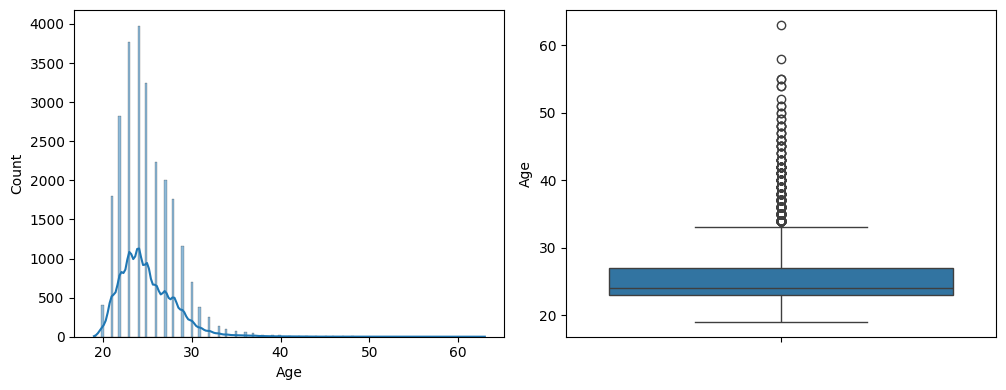

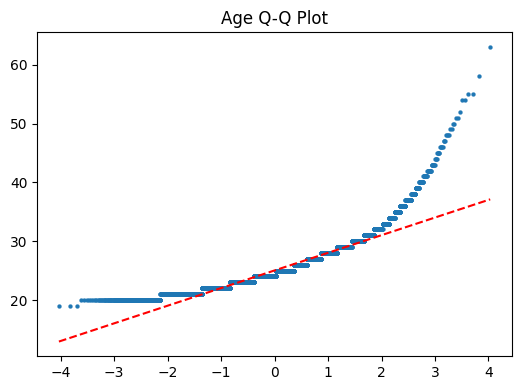

In [72]:
# choose columns to plot - exclude categorical columns
cols = ["Age"]

# plot histograms and boxplots for the numeric columns to visualise their
# distributions and check for outliers

plot_distributions_and_qq(stage_1_data, cols)


### Target Variable Analysis

**Target Bar Plot**

We will plot overall target distribution to determine the balance.

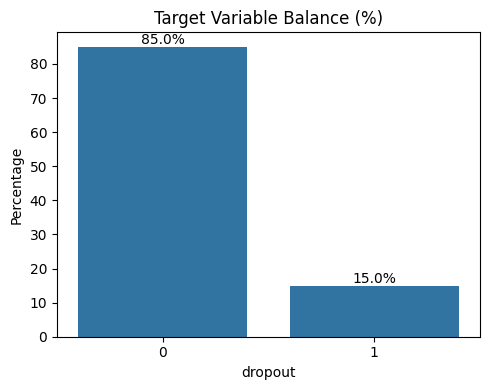

In [73]:
# plot the balance of the target variable Dropout as a bar chart showing
# percentage of each class
target_counts = (
    stage_1_data["dropout"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("percentage")
    .reset_index()
)

plt.figure(figsize=(5, 4))
ax = sns.barplot(x="dropout", y="percentage", data=target_counts)

plt.title("Target Variable Balance (%)")
plt.ylabel("Percentage")
plt.xlabel("dropout")

# Annotate bars properly
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.1f}%",
        (p.get_x() + p.get_width() / 2.0, height),
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()


**Class Imbalance Check**

Confirmed: 

- 85% complete
- 15% dropout

This is imbalanced, and should be considered when creating test / train / validation - use stratified split

When evaluating model performance consider imbalance when assessing accuracy measures.


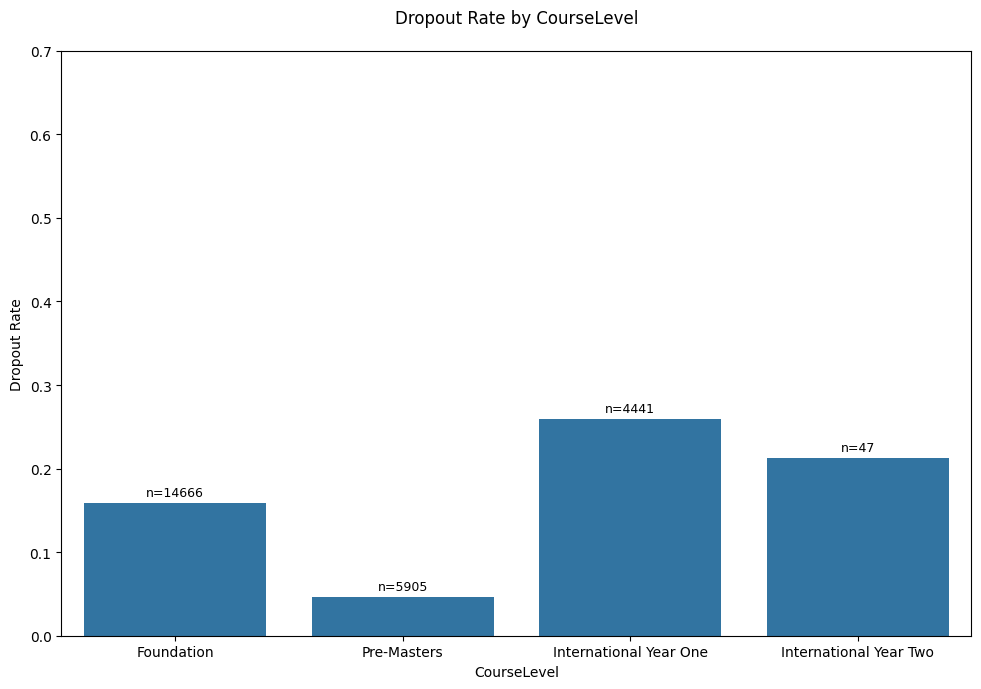

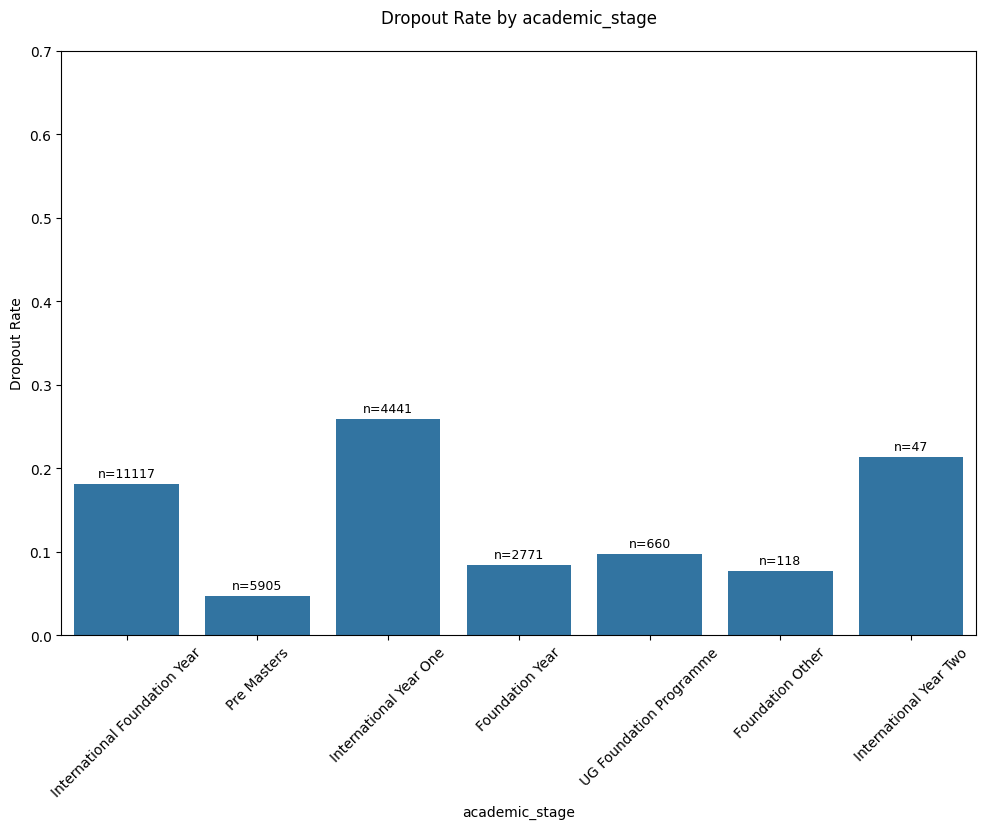

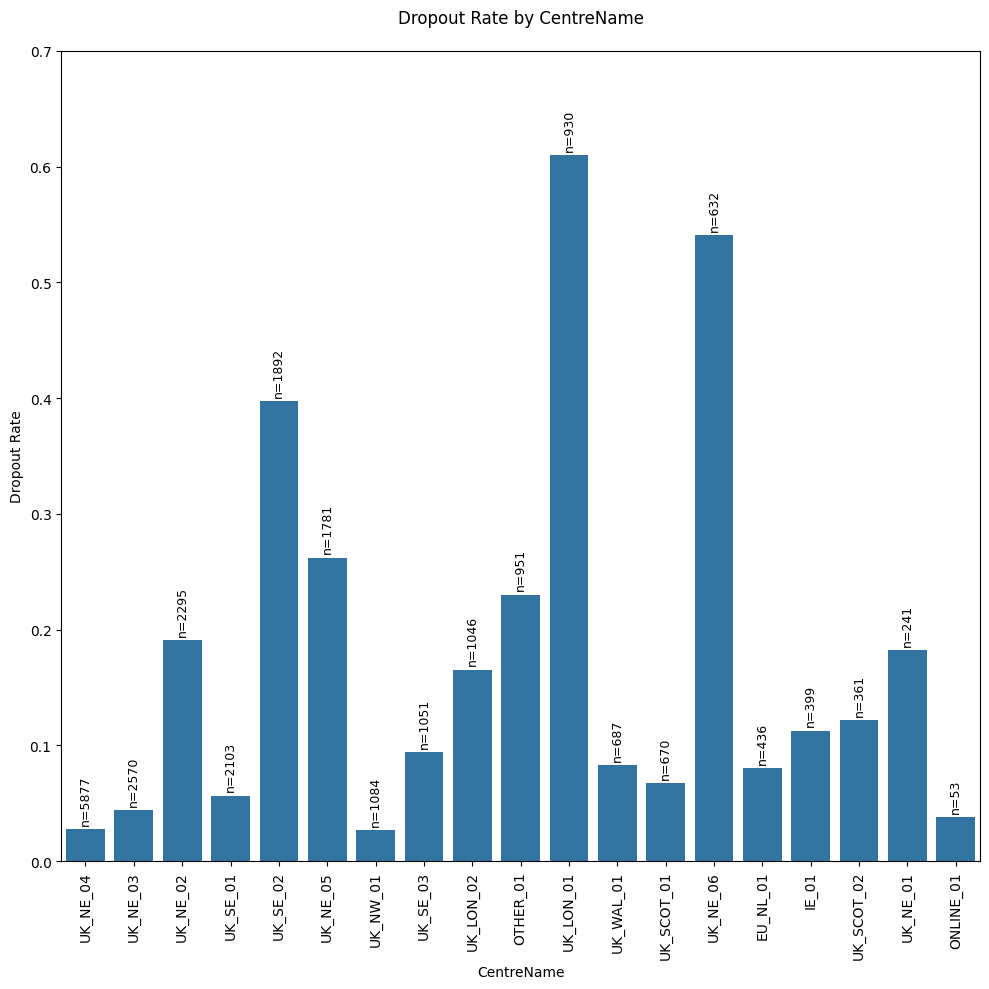

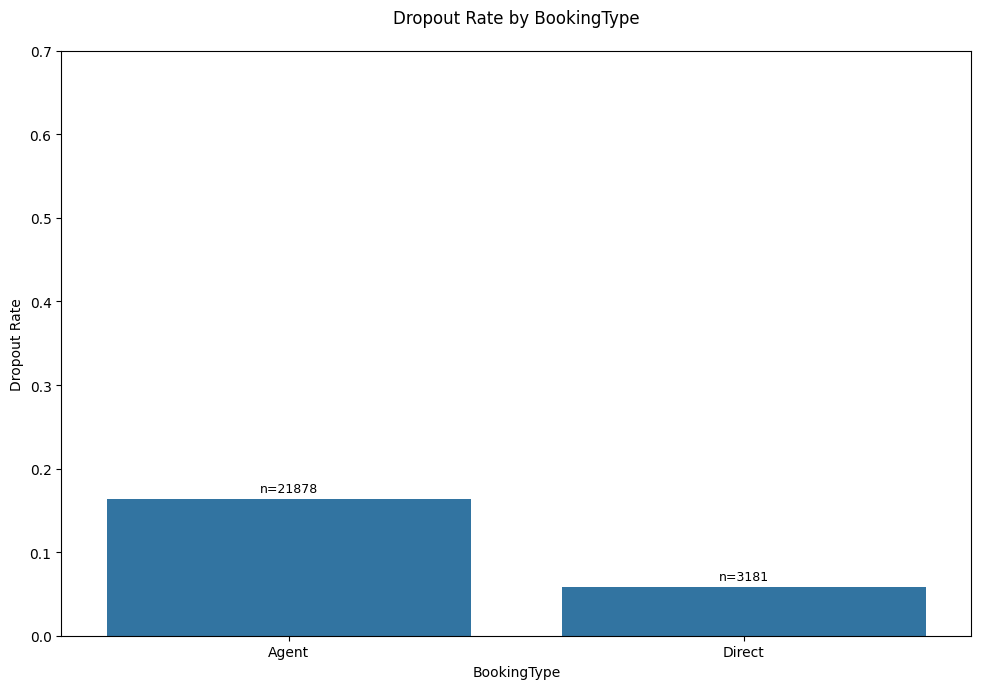

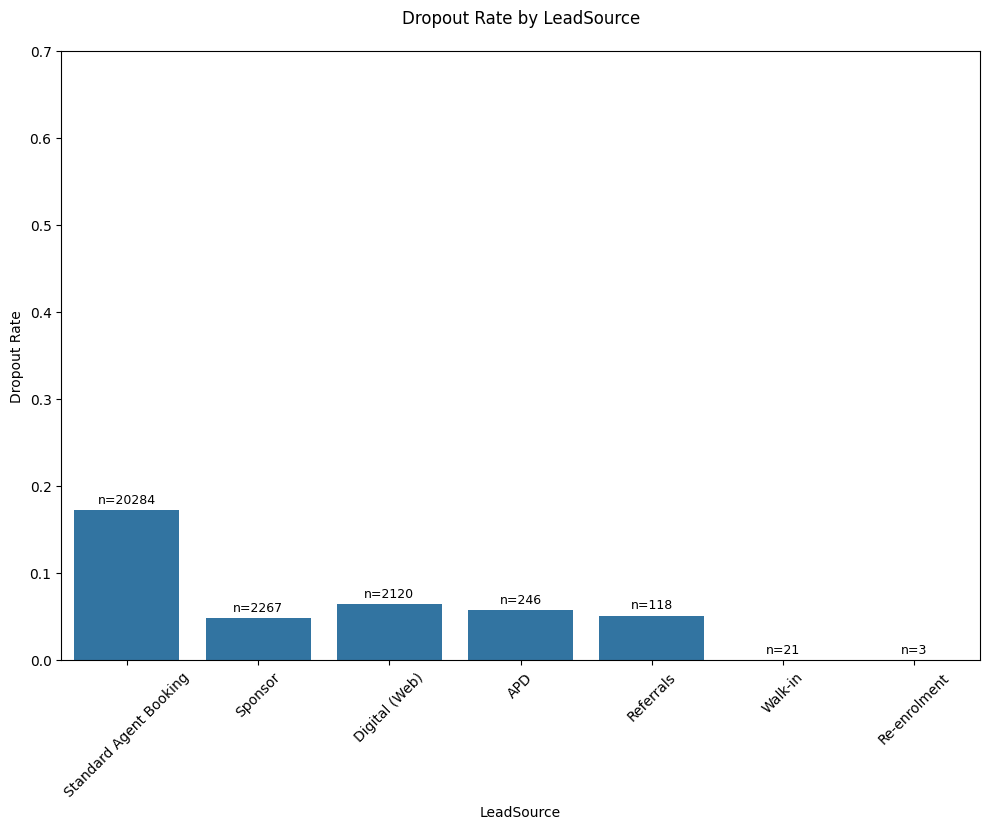

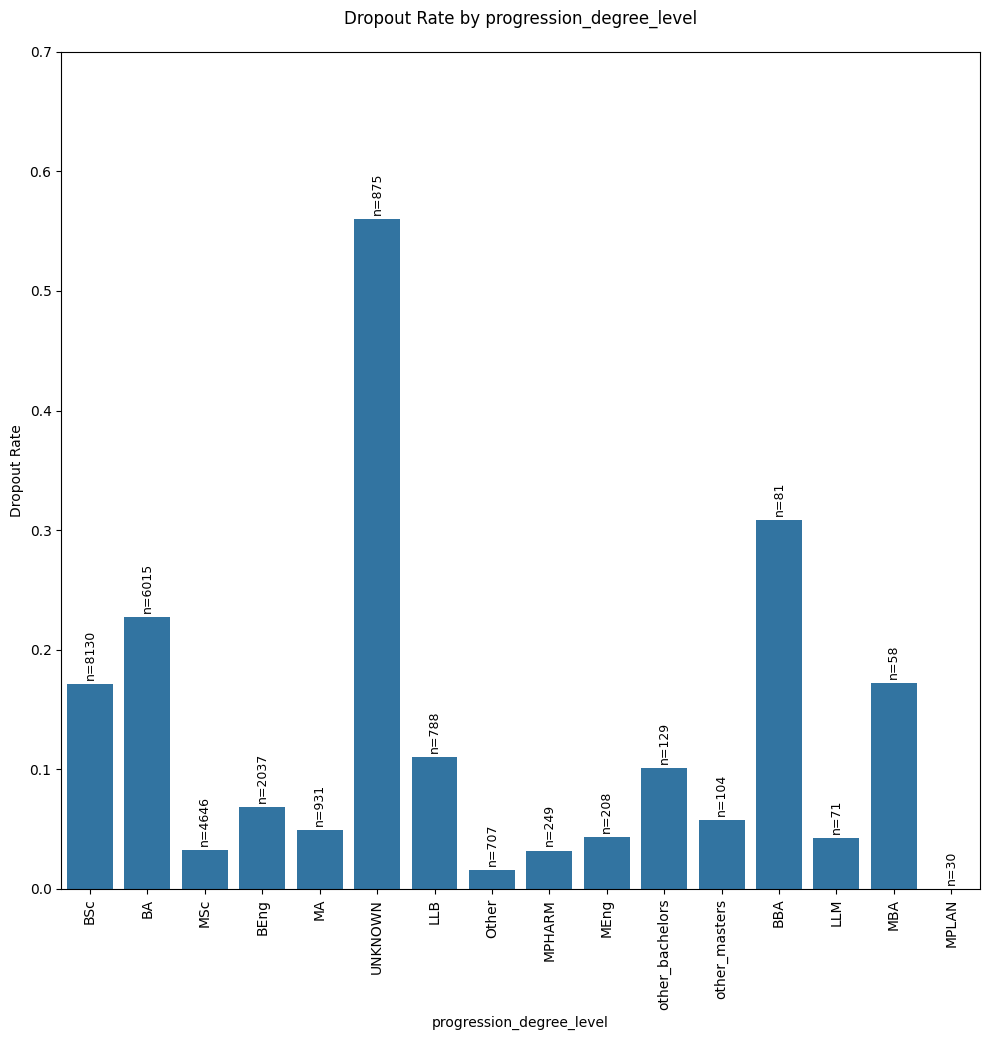

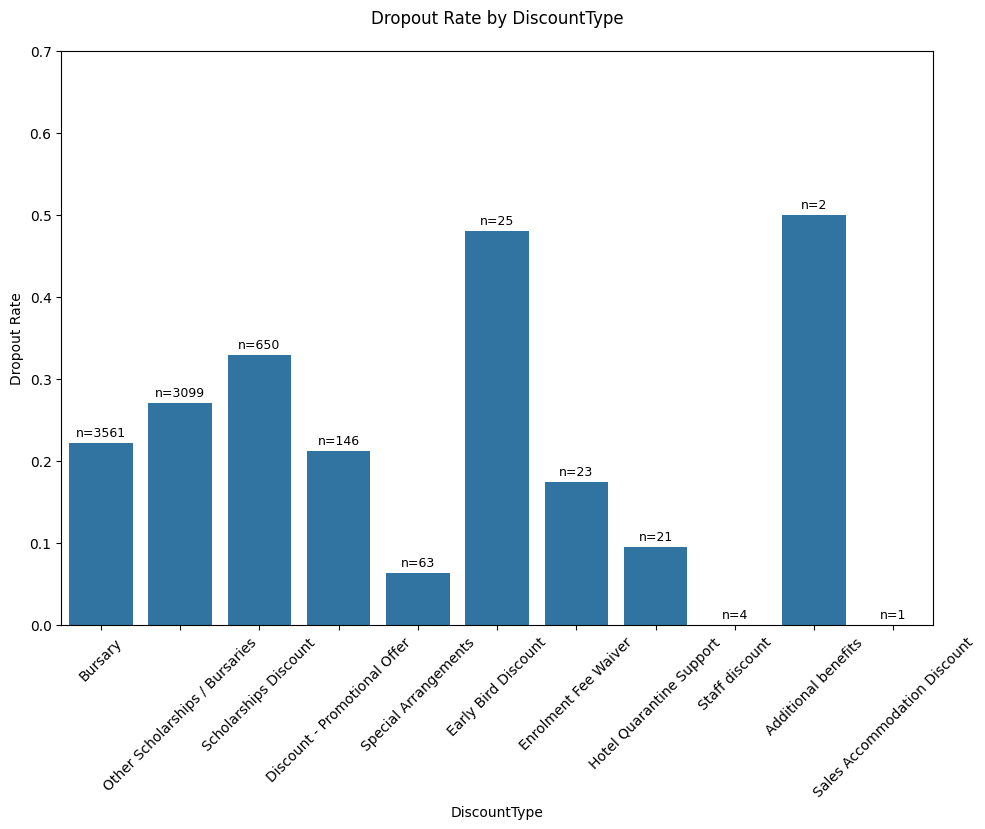

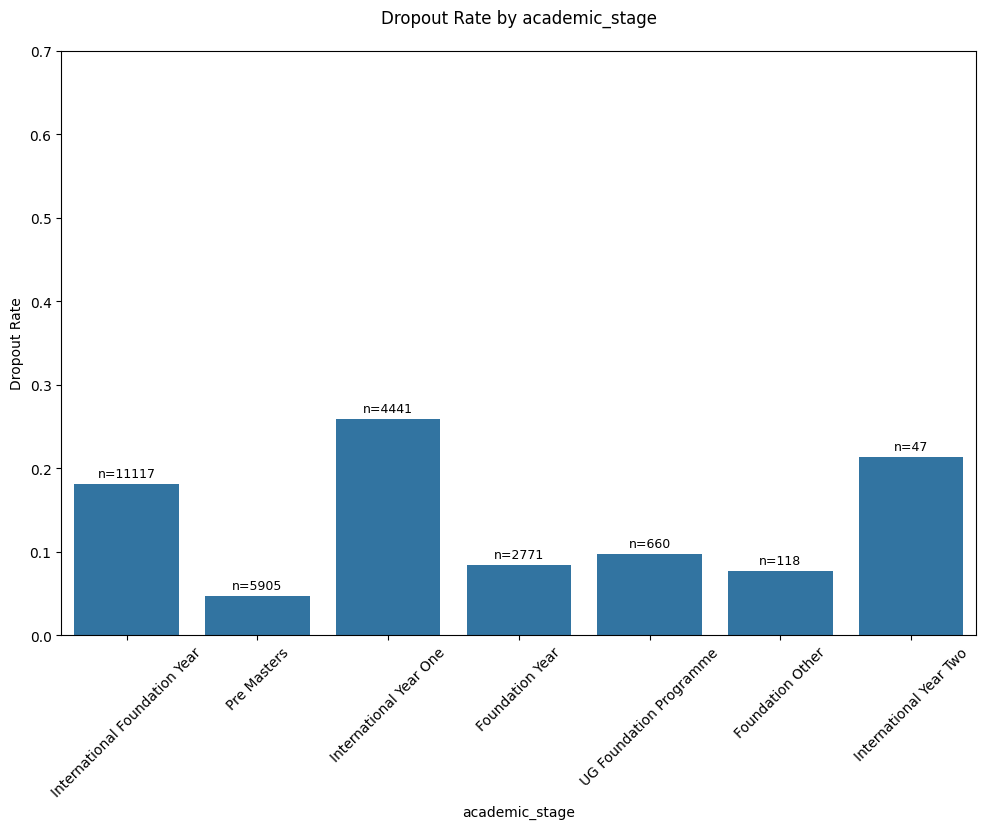

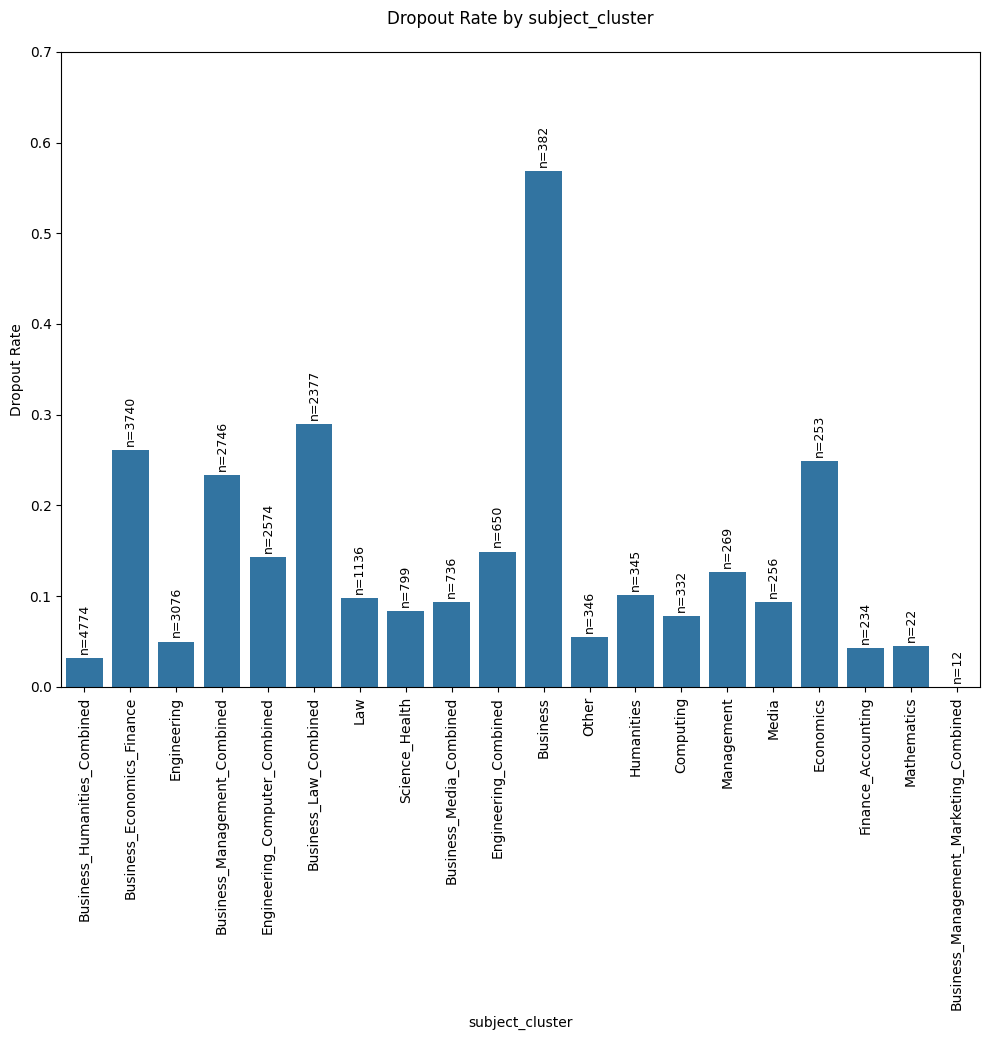

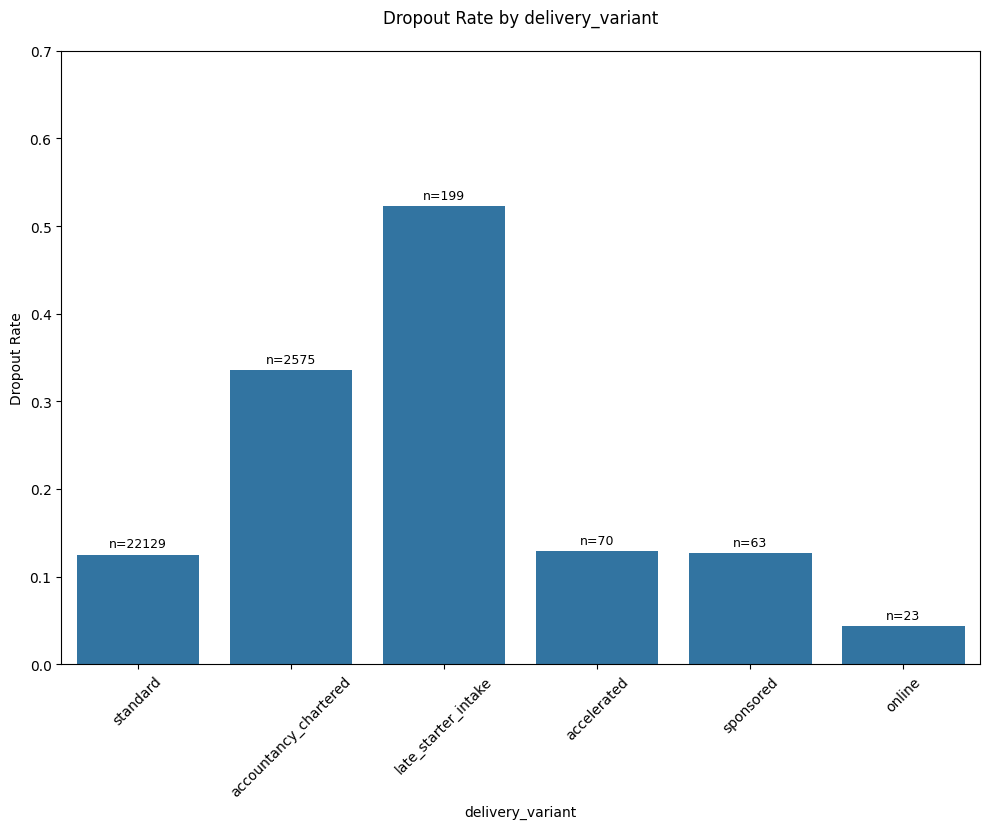

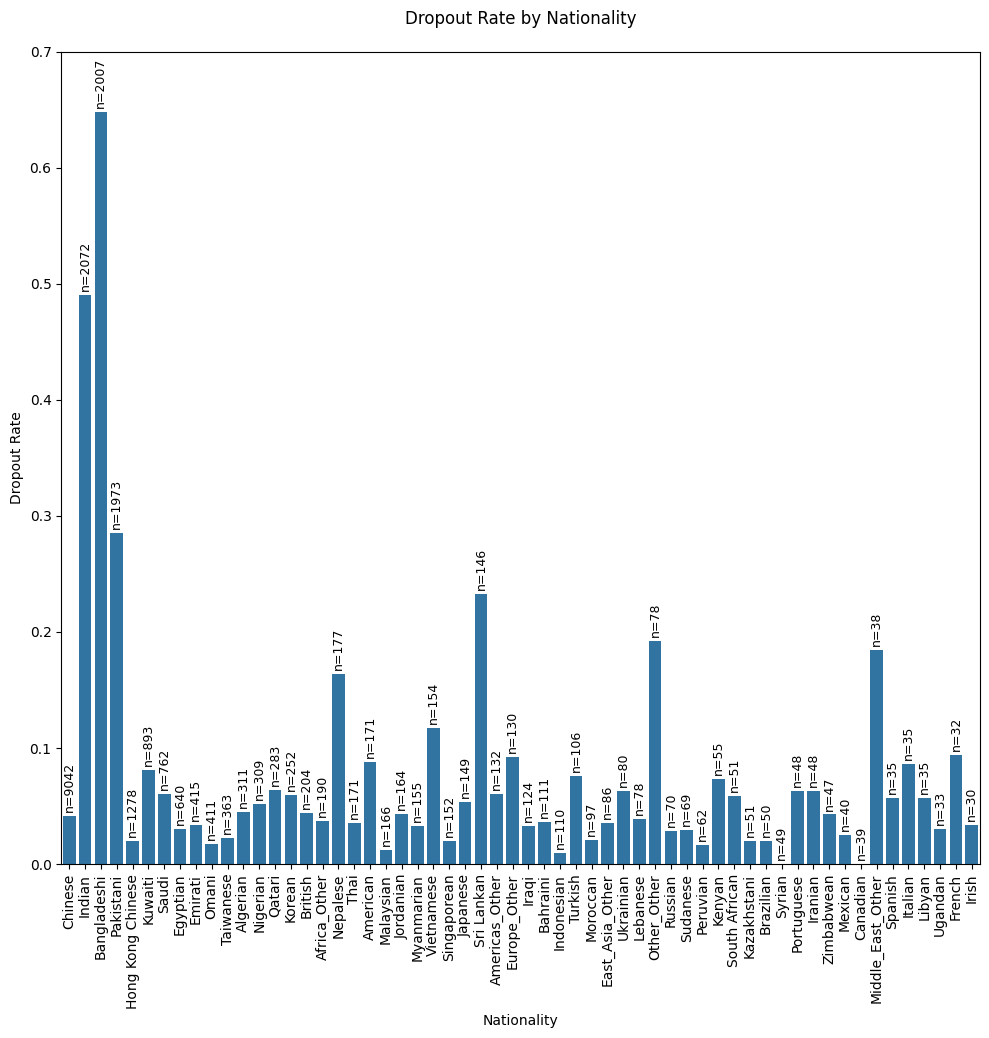

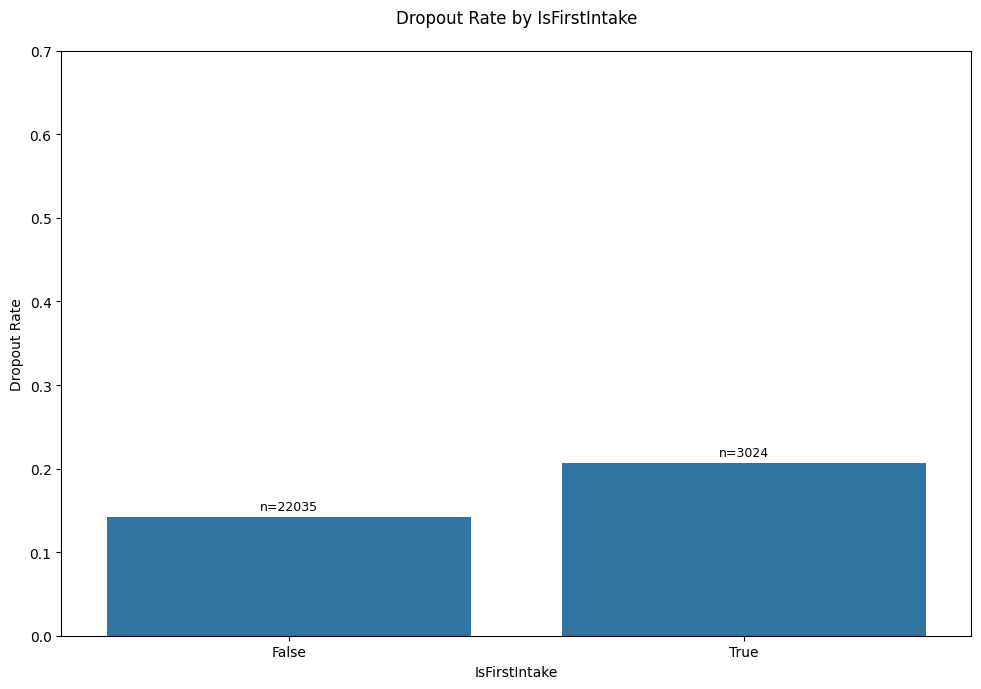

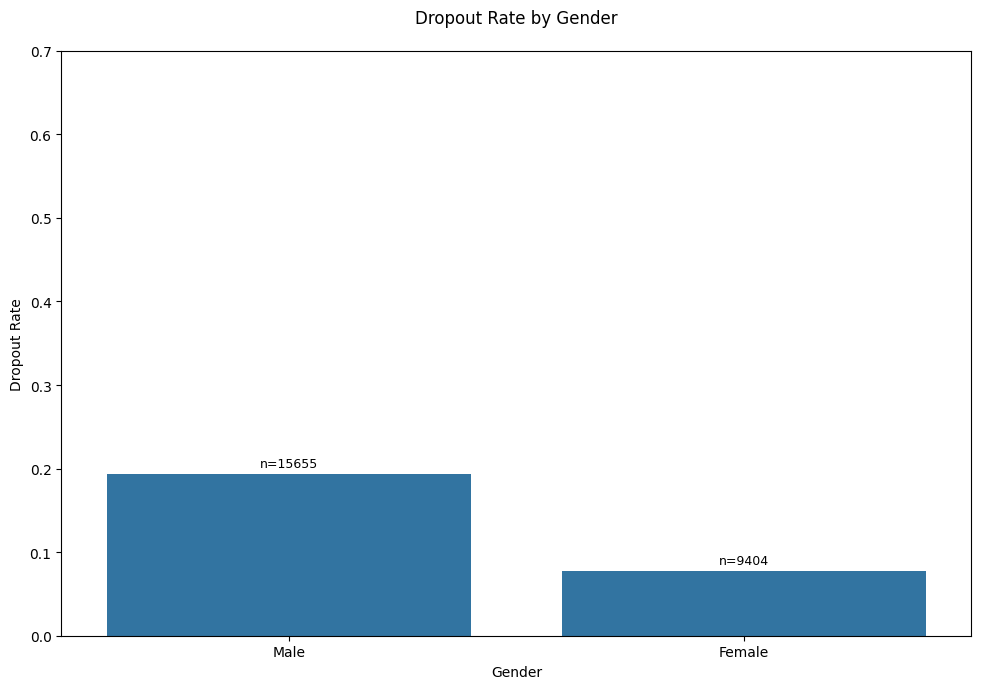

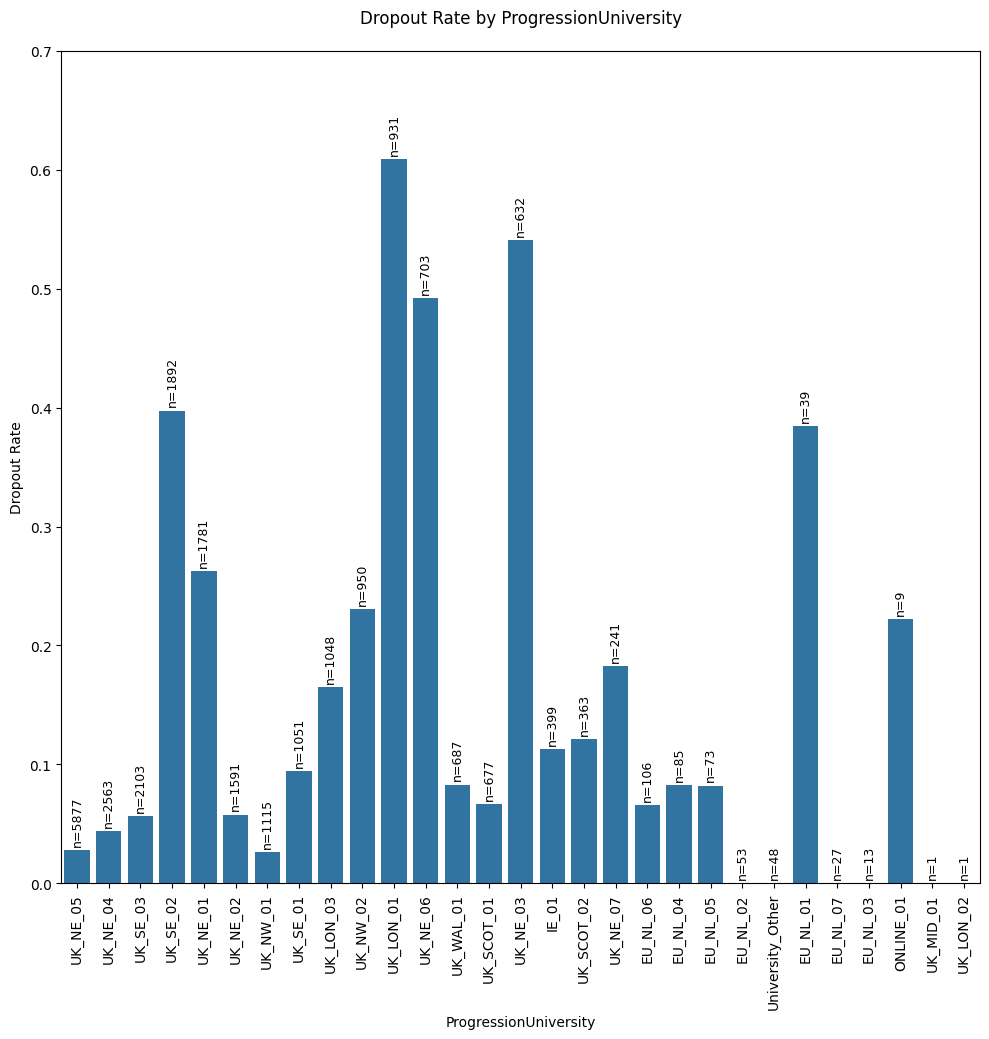

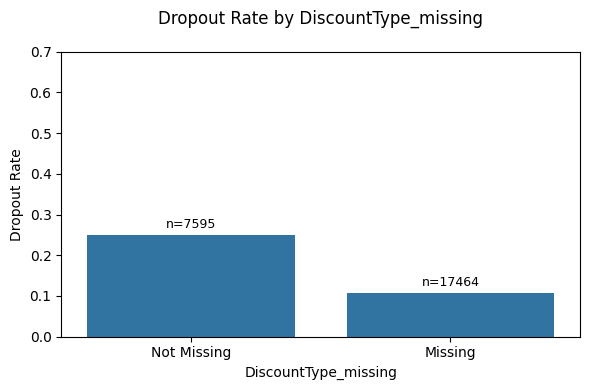

In [74]:
categorical_features = [
    "CourseLevel",
    "academic_stage",
    "CentreName",
    "BookingType",
    "LeadSource",
    "progression_degree_level",
    "DiscountType",
    "academic_stage",
    "subject_cluster",
    "delivery_variant",
    "Nationality",
    "IsFirstIntake",
    "Gender",
    "ProgressionUniversity",
]


target_col = TARGET_COLUMN

# For each categorical feature, we will group by the feature and calculate
# the count and dropout rate for each category, then plot the dropout
# rate by category using the shared config constants from src/config.py.
for col in categorical_features:
    summary = (
        stage_1_data.groupby(col)[target_col]
        .agg(count="size", dropout_rate="mean")
        .sort_values("count", ascending=False)
        .reset_index()
    )
    plot_dropout_rate_by_category(summary, col)

sparse_categorical_features = ["DiscountType"]

for col in sparse_categorical_features:
    missing_col = f"{col}_missing"

    summary = (
        stage_1_data.assign(**{missing_col: stage_1_data[col].isna()})
        .groupby(missing_col)[TARGET_COLUMN]
        .agg(count="size", dropout_rate="mean")
        .reset_index()
    )

    summary[missing_col] = summary[missing_col].map({True: "Missing", False: "Not Missing"})
    summary[missing_col] = pd.Categorical(
        summary[missing_col],
        categories=["Not Missing", "Missing"],
        ordered=True,
    )
    summary = summary.sort_values(missing_col)

    plot_dropout_rate_by_category(summary, missing_col, figsize=(6, 4))


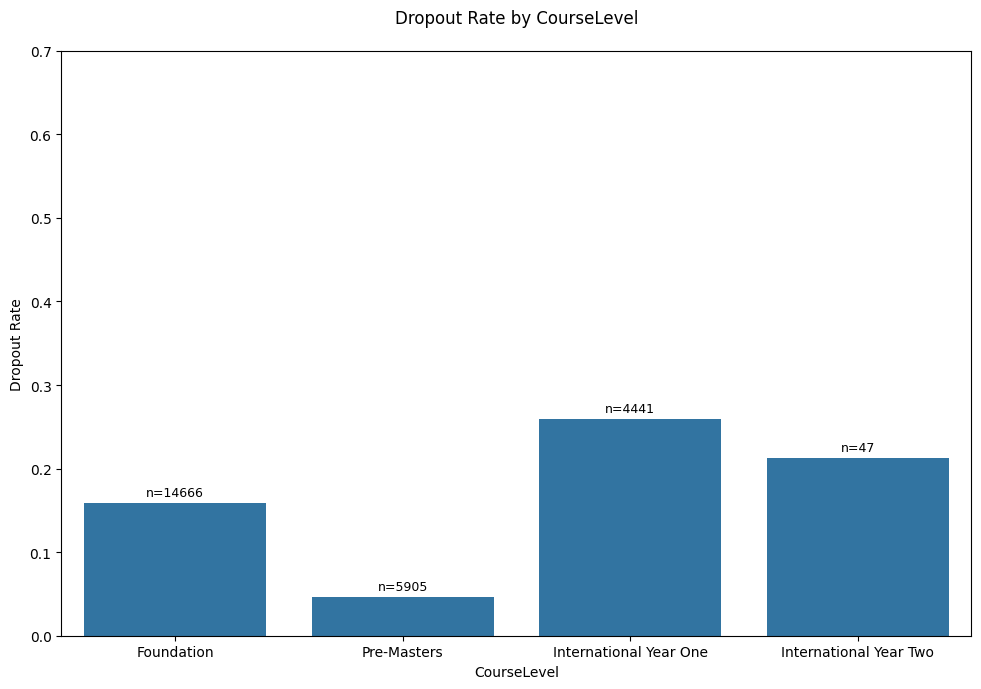

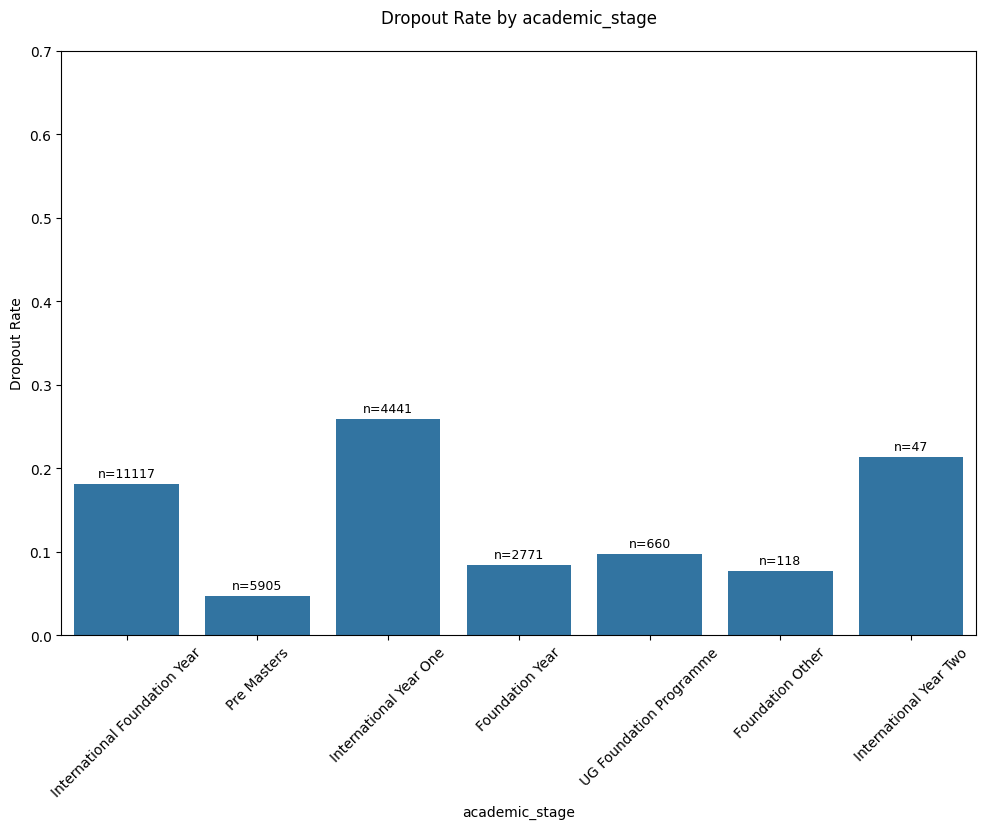

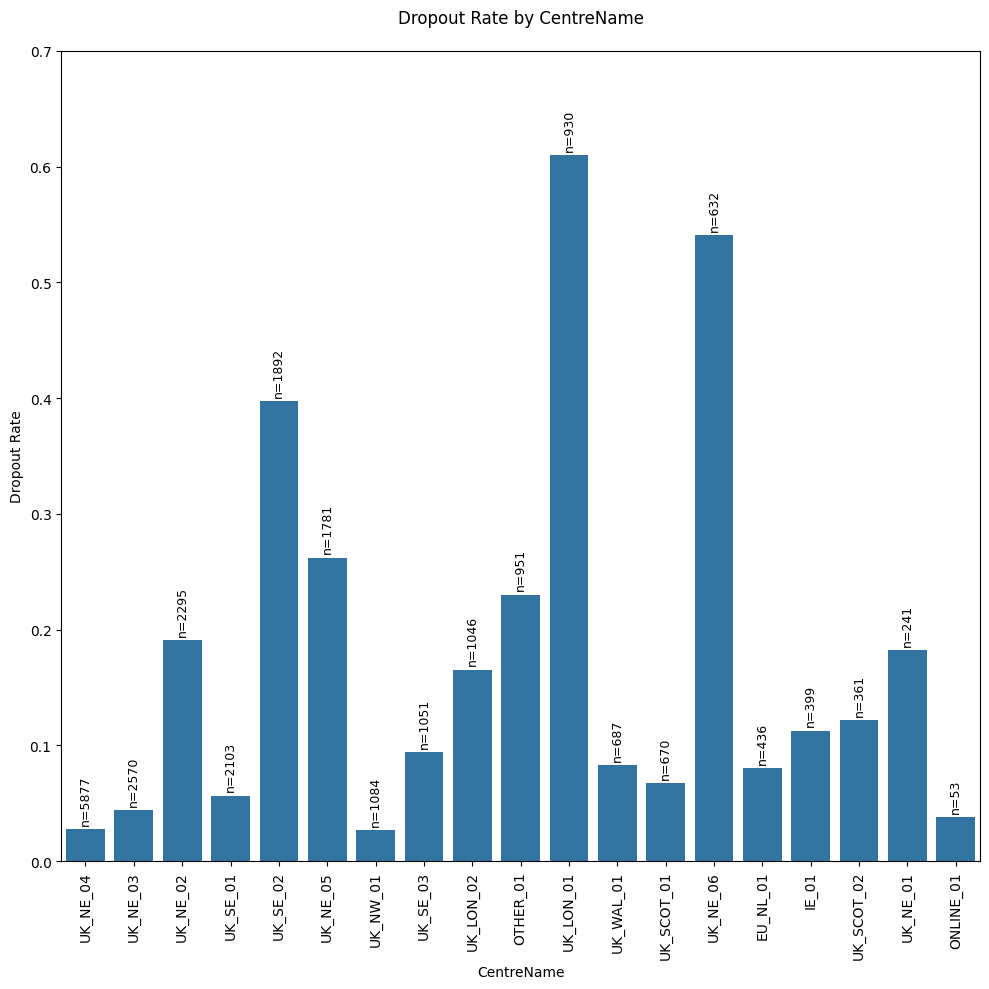

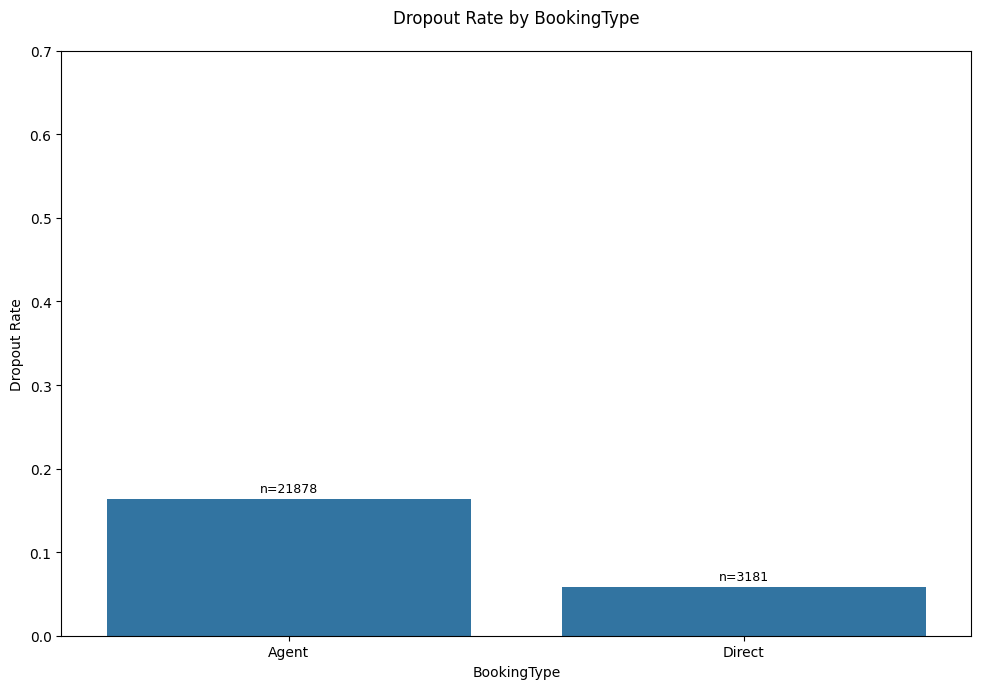

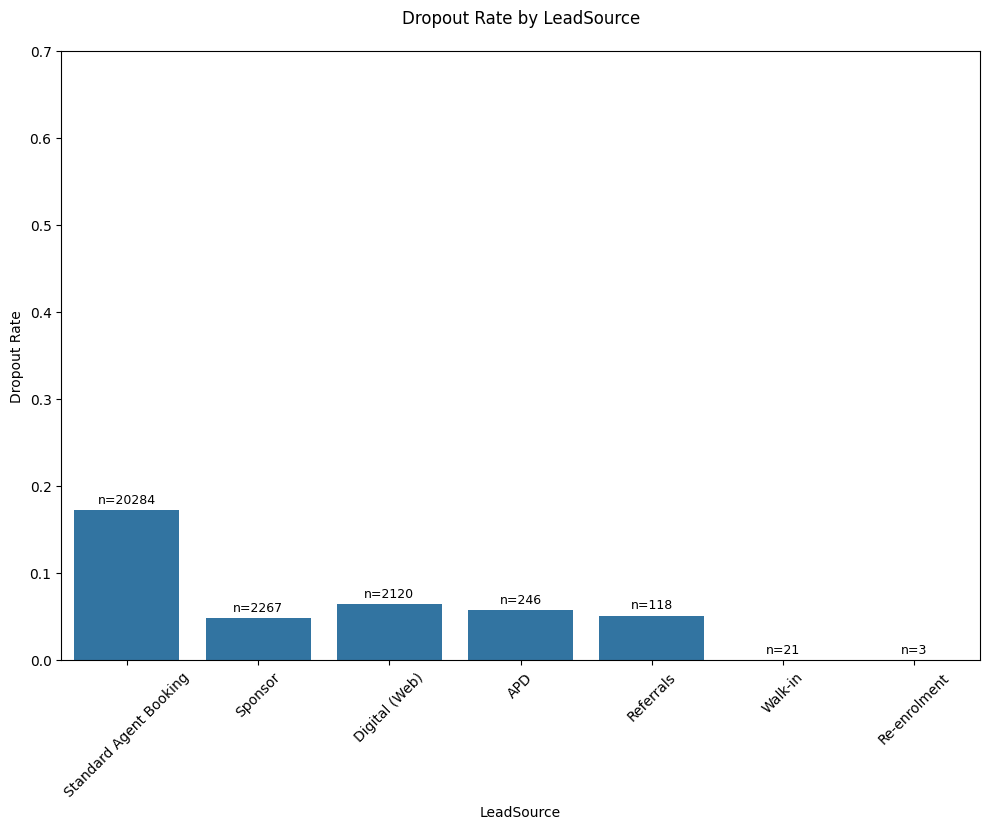

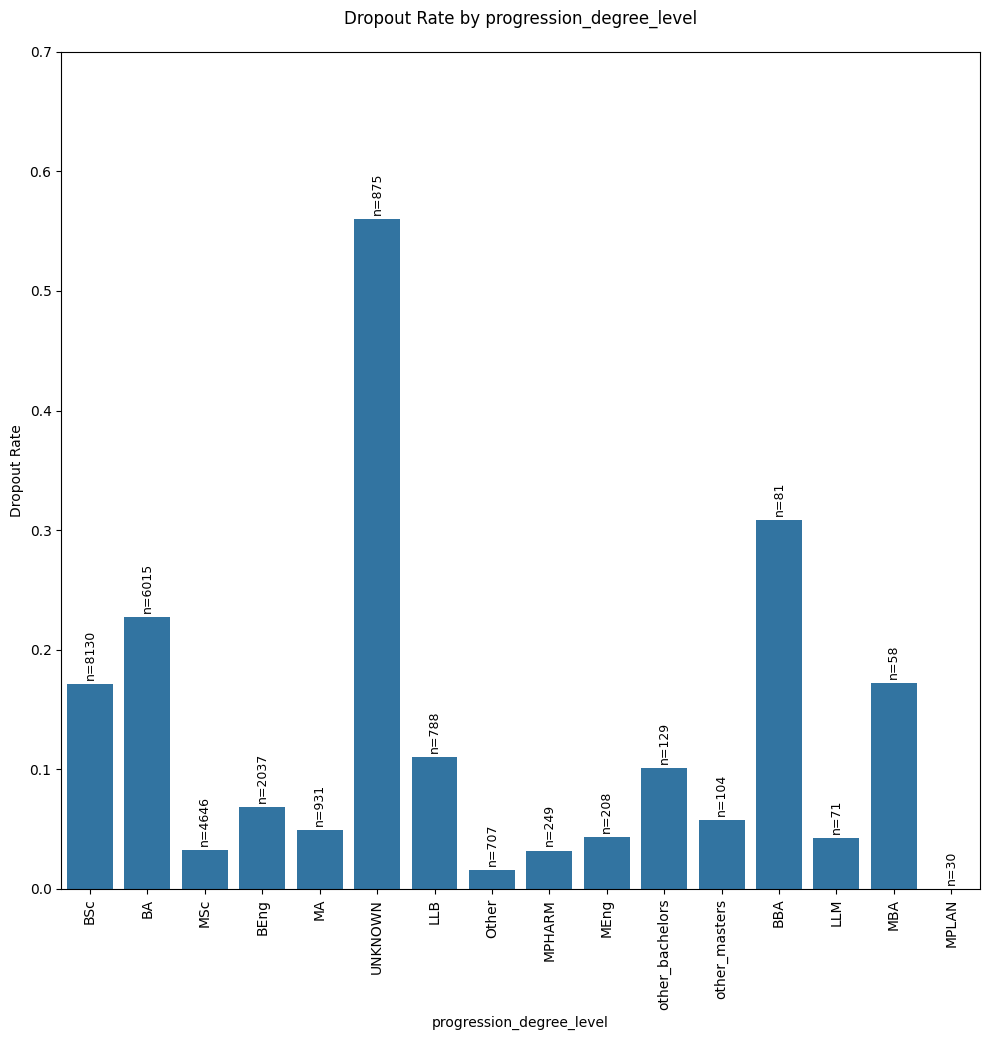

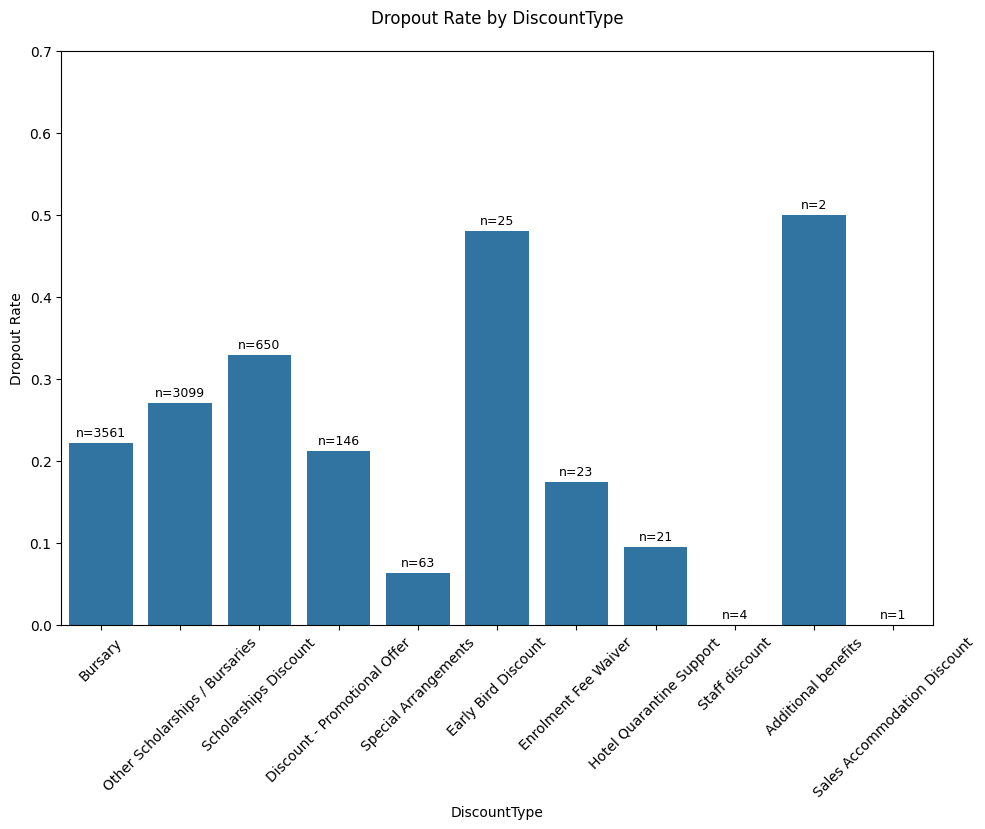

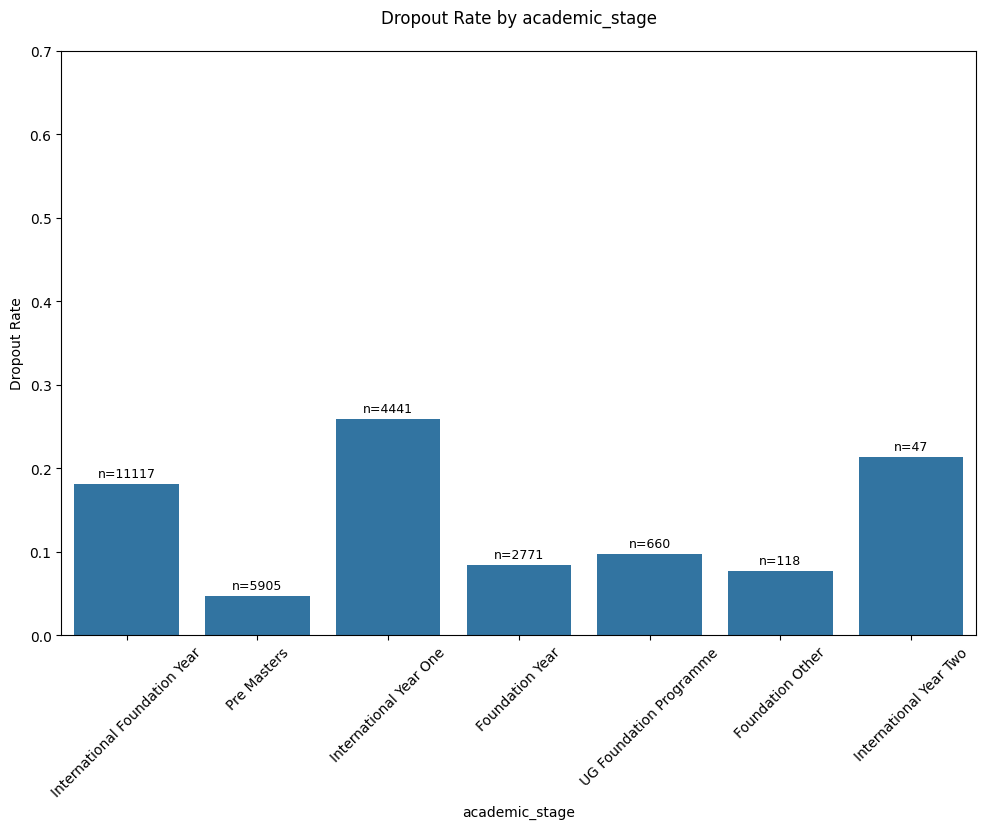

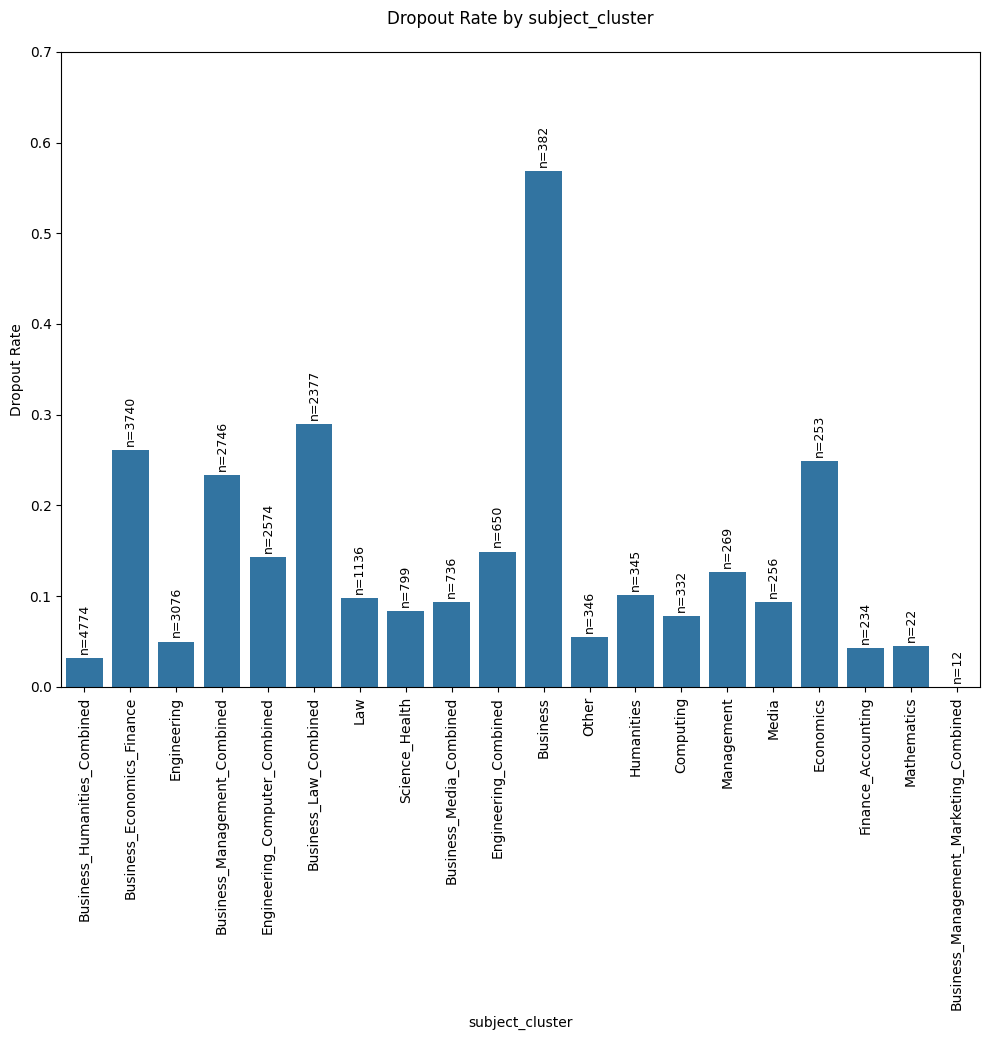

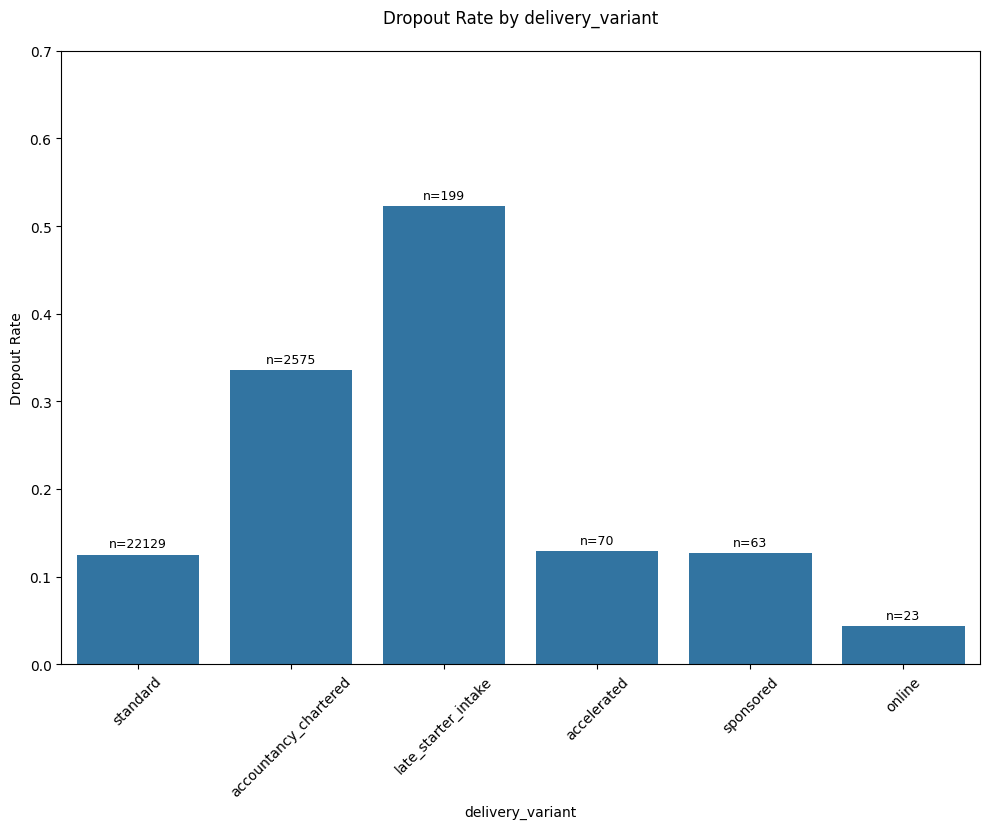

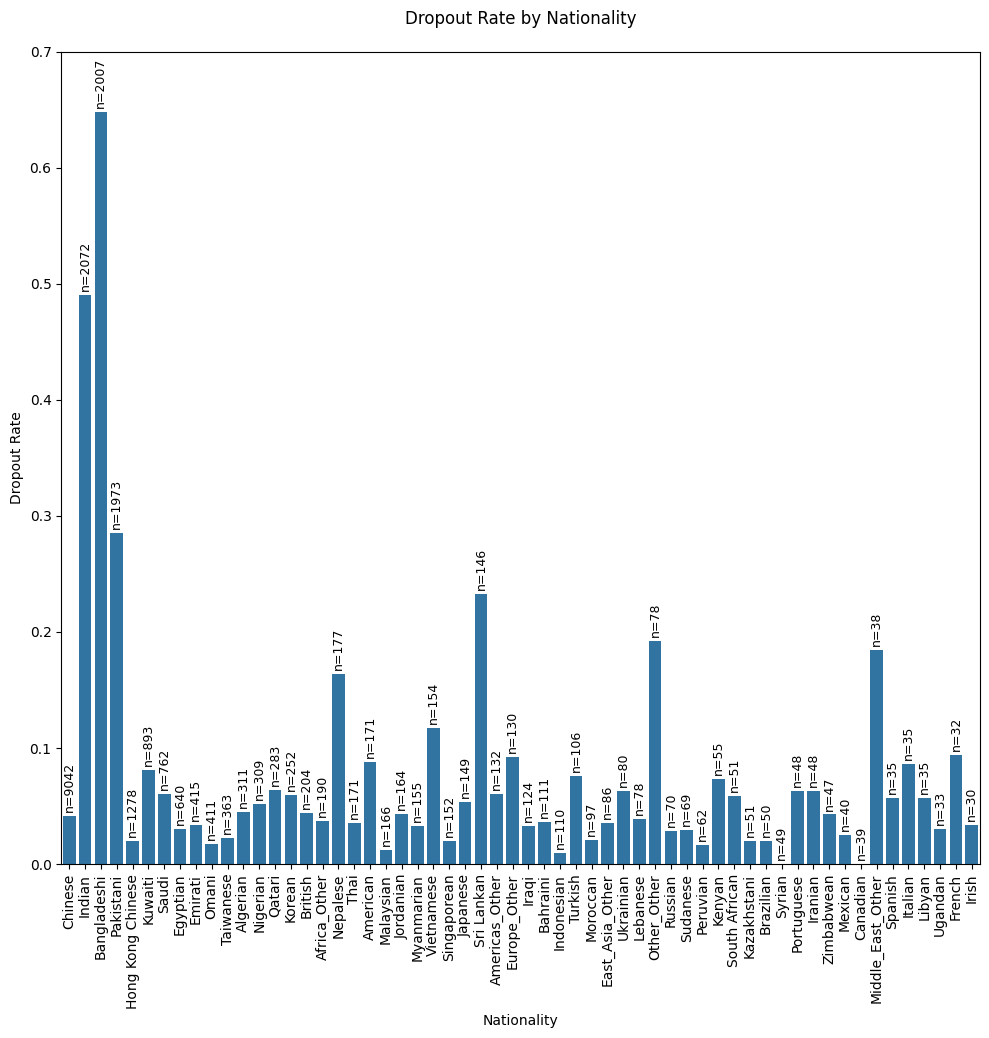

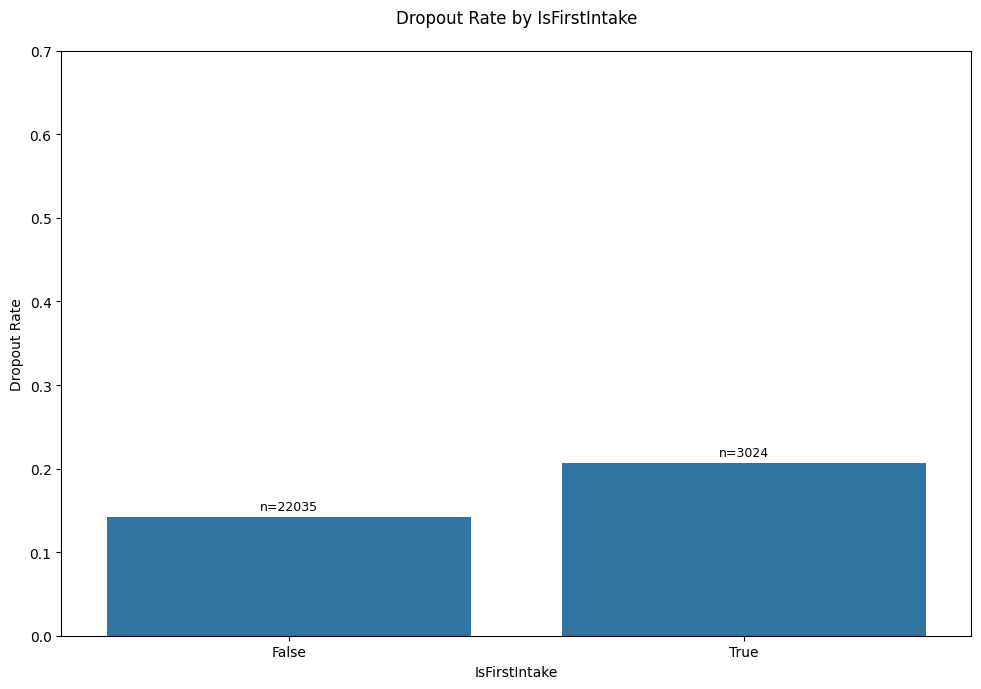

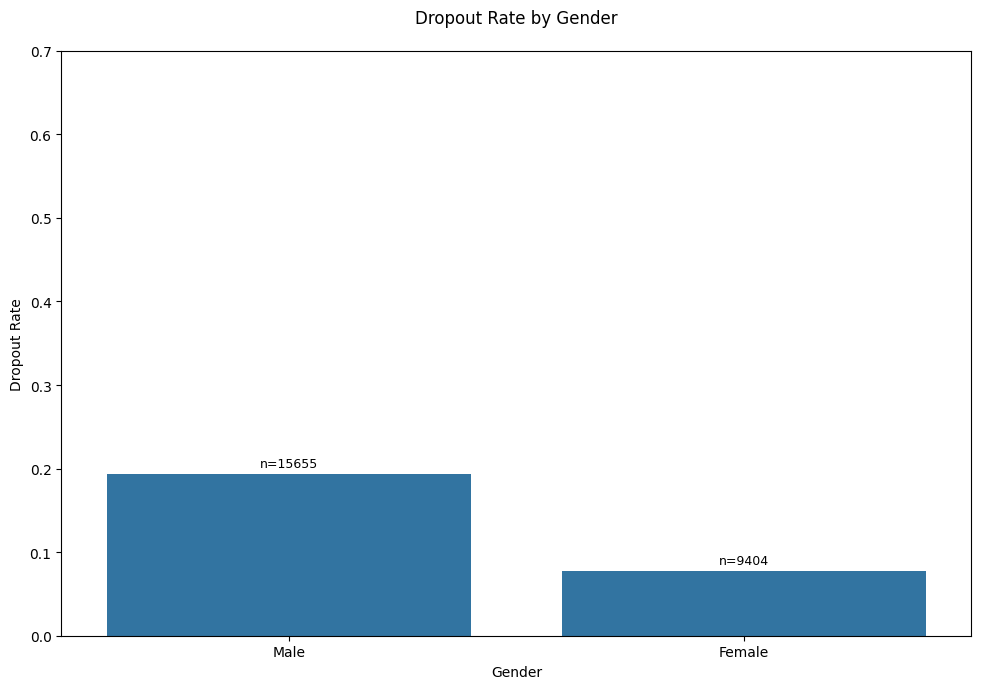

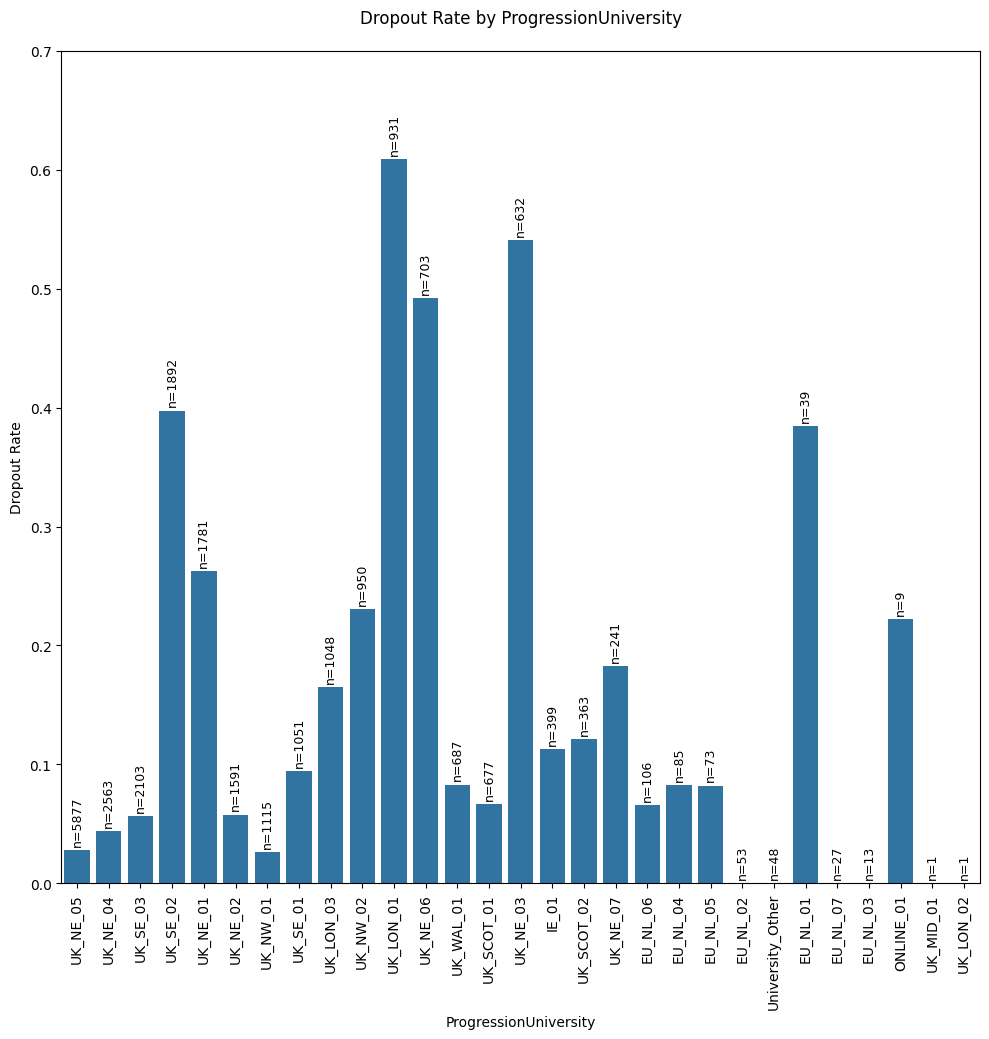

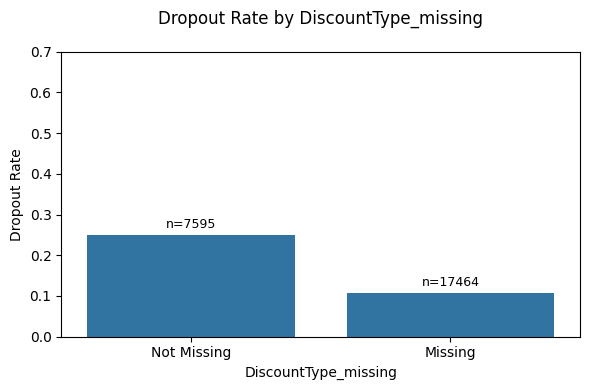

In [75]:
categorical_features = [
    "CourseLevel",
    "academic_stage",
    "CentreName",
    "BookingType",
    "LeadSource",
    "progression_degree_level",
    "DiscountType",
    "academic_stage",
    "subject_cluster",
    "delivery_variant",
    "Nationality",
    "IsFirstIntake",
    "Gender",
    "ProgressionUniversity",
]

target_col = TARGET_COLUMN

# For each categorical feature, we will group by the feature and calculate
# the count and dropout rate for each category, then plot the dropout
# rate by category. The feature list is kept here so readers can see the
# EDA design directly in the notebook.
for col in categorical_features:
    summary = (
        stage_1_data.groupby(col)[target_col]
        .agg(count="size", dropout_rate="mean")
        .sort_values("count", ascending=False)
        .reset_index()
    )
    plot_dropout_rate_by_category(summary, col)

sparse_categorical_features = ["DiscountType"]
missingness_label_map = {True: "Missing", False: "Not Missing"}
missingness_label_order = ["Not Missing", "Missing"]

for col in sparse_categorical_features:
    missing_col = f"{col}_missing"

    summary = (
        stage_1_data.assign(**{missing_col: stage_1_data[col].isna()})
        .groupby(missing_col)[TARGET_COLUMN]
        .agg(count="size", dropout_rate="mean")
        .reset_index()
    )

    summary[missing_col] = summary[missing_col].map(missingness_label_map)
    summary[missing_col] = pd.Categorical(
        summary[missing_col],
        categories=missingness_label_order,
        ordered=True,
    )
    summary = summary.sort_values(missing_col)

    plot_dropout_rate_by_category(summary, missing_col, figsize=(6, 4))



In [76]:
##drop the courselevel column as it is superseded by the more detailed
# academic_stage
stage_1_data.drop(columns=["CourseLevel"], inplace=True)


In [77]:
# Identify categories to keep
progression_university_min_count = 50
progression_university_other_label = "University_Other"
counts = stage_1_data["ProgressionUniversity"].value_counts()
keep_list = counts[counts > progression_university_min_count].index

stage_1_data["ProgressionUniversity"] = stage_1_data[
    "ProgressionUniversity"
].where(
    stage_1_data["ProgressionUniversity"].isin(keep_list),
    progression_university_other_label,
)

stage_1_data["DiscountType"] = stage_1_data["DiscountType"].fillna(
    "NoDiscount"
)

stage_1_data.head()


,CentreName,BookingType,LeadSource,DiscountType,Gender,Age,Nationality,academic_stage,subject_cluster,delivery_variant,IsFirstIntake,CompletedCourse,dropout,progression_degree_level,ProgressionUniversity,progression_degree_missing
0,UK_SCOT_02,Agent,Standard Agent Booking,NoDiscount,Male,27,Chinese,Pre Masters,Business_Law_Combined,standard,True,Yes,0,MSc,UK_SCOT_02,False
1,UK_SCOT_02,Agent,Standard Agent Booking,NoDiscount,Male,27,Chinese,UG Foundation Programme,Science_Health,standard,False,Yes,0,BSc,UK_SCOT_02,False
2,UK_SCOT_02,Agent,Standard Agent Booking,NoDiscount,Male,25,Chinese,International Year Two,Business_Economics_Finance,standard,False,Yes,0,MA,UK_SCOT_02,False
3,UK_SCOT_02,Agent,Standard Agent Booking,NoDiscount,Male,26,Chinese,International Year Two,Business_Economics_Finance,standard,True,Yes,0,MA,UK_SCOT_02,False
4,UK_SCOT_02,Agent,Standard Agent Booking,NoDiscount,Male,29,Chinese,Pre Masters,Business_Law_Combined,standard,True,Yes,0,MSc,UK_SCOT_02,False


In [78]:
# one-hot encode the categorical features for modeling
one_hot_columns = [
    "academic_stage",
    "CentreName",
    "BookingType",
    "LeadSource",
    "progression_degree_level",
    "DiscountType",
    "subject_cluster",
    "delivery_variant",
    "Nationality",
    "ProgressionUniversity",
]
stage_1_data_encoded = pd.get_dummies(
    stage_1_data,
    columns=one_hot_columns,
    dtype=int,
)

gender_map = {"Male": 0, "Female": 1}
stage_1_data_encoded["Gender"] = stage_1_data["Gender"].map(gender_map)

stage_1_data_encoded["IsFirstIntake"] = stage_1_data["IsFirstIntake"].astype(
    int
)

stage_1_data_encoded.drop(columns=["CompletedCourse"], inplace=True)
stage_1_data_encoded.head()



,Gender,Age,IsFirstIntake,dropout,progression_degree_missing,academic_stage_Foundation Other,academic_stage_Foundation Year,academic_stage_International Foundation Year,academic_stage_International Year One,academic_stage_International Year Two,...,ProgressionUniversity_UK_NE_07,ProgressionUniversity_UK_NW_01,ProgressionUniversity_UK_NW_02,ProgressionUniversity_UK_SCOT_01,ProgressionUniversity_UK_SCOT_02,ProgressionUniversity_UK_SE_01,ProgressionUniversity_UK_SE_02,ProgressionUniversity_UK_SE_03,ProgressionUniversity_UK_WAL_01,ProgressionUniversity_University_Other
0,0,27,1,0,False,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,0,27,0,0,False,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0,25,0,0,False,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
3,0,26,1,0,False,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,29,1,0,False,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [79]:
# create train, validation, and test splits with scaling for modeling
(
    X_train,
    X_train_s,
    X_val,
    X_val_s,
    X_test,
    X_test_s,
    y_train,
    y_val,
    y_test,
    scaler,
) = create_train_val_test_split_and_scale(
    stage_1_data_encoded, stratify=True, seed=SEED
)


## Stage 1 - XGBoost Model 

### Baseline Model

We will define and instantiate a simple XGBOOST model, fit the model to the training dataset and visualise the loss curves.

Initial baseline parameters will be selected to provide a balance between model complexity, and computational efficiency as follows:

*Model capacity*
- A shallow tree depth (max_depth=3)
- A moderate learning rate (learning_rate=0.1) 

*Regularisation*
- Row and feature subsampling (subsample=0.8, colsample_bytree=0.8) 

The model will be trained with 100 boosting rounds (n_estimators=100) and evaluated using AUC.



In [80]:
# We will use the choose_n_jobs function to determine the number of parallel
# jobs to use for XGBoost based on the number of CPU cores available
# Chosen to improve performance as default settings or using maximum cores
# resulted in long runtimes
N_JOBS = choose_n_jobs()

set_seed(SEED)

# define the XGBoost model with specified hyperparameters and fit it to the
# training data
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    eval_metric="auc",
    n_jobs=N_JOBS,
)

# fit the XGBoost model to the training data

xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

# make predictions on the test set using the fitted XGBoost model
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]


### Baseline Performance Metrics

We will now evaluate the model against the test set using the following performance indicators:
 - Accuracy
 - Precision
 - Recall
 - AUC

A confusion matrix, ROC and Precision-Recall Curves will also be plotted.

Stage 1 XGBoost - Baseline Performance Metrics:
Accuracy:    0.8958
Precision:   0.6951
Recall:      0.5433
Specificity: 0.9580
AUC:         0.8951


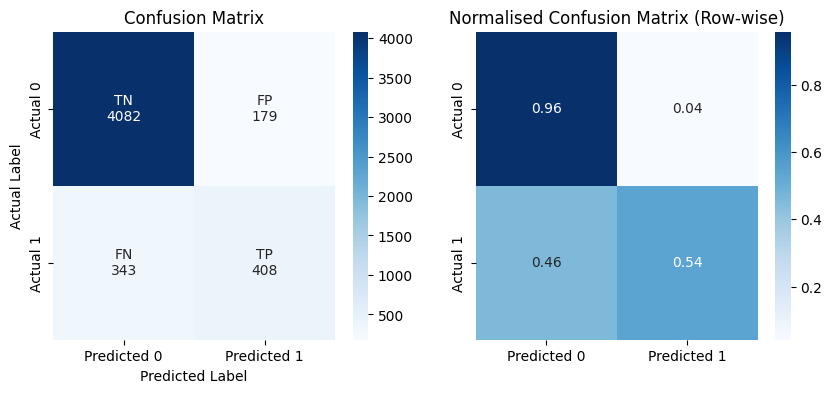

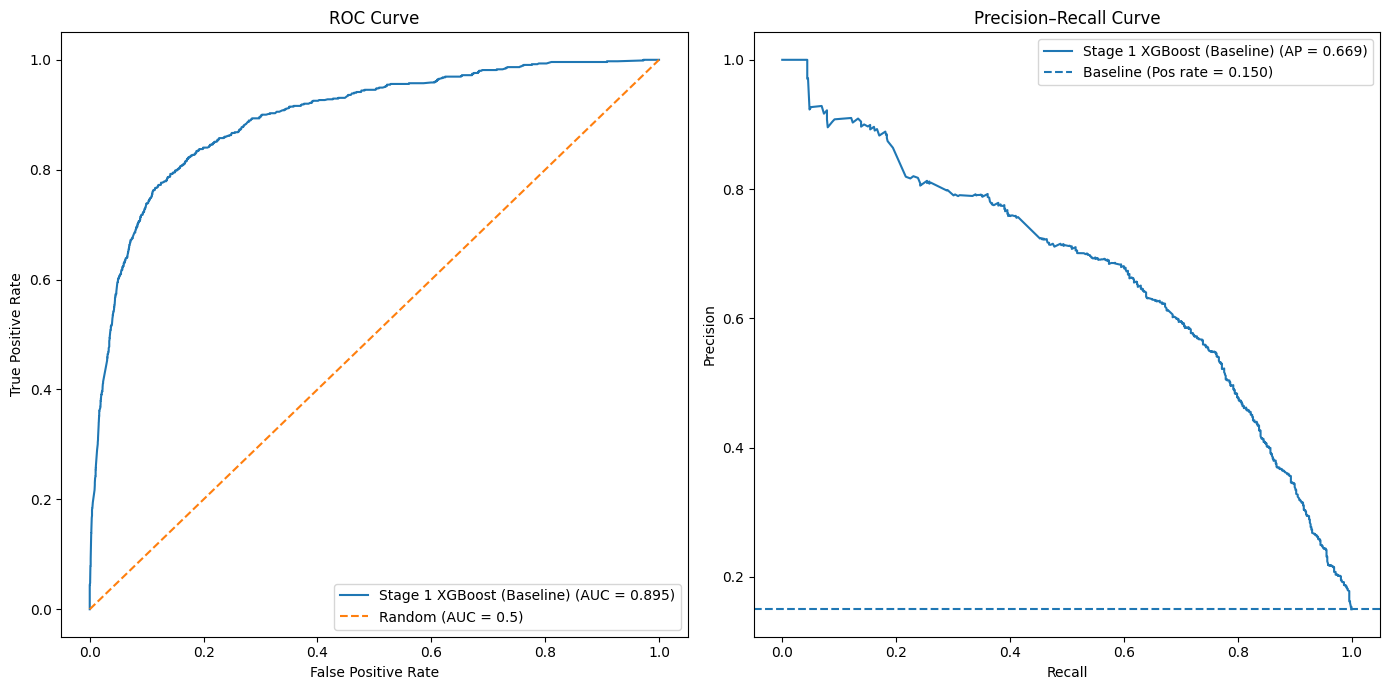

In [81]:
# store the results in a dictionary for easy comparison with other models later
results = {}

params = {
    "n_estimators": 100,
    "max_depth": 3,
    "learning_rate": 0.1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
}

m_id = 1  # unique identifier for this model in the results dictionary

# evaluate the model using the evaluate_and_store_model function defined earlier
# , which computes performance metrics and stores them in the results dictionary
results = evaluate_and_store_model(
    results,
    m_id=m_id,
    model_name="Baseline",
    model_type="XGBoost",
    stage="Stage 1",
    y_true=y_test,
    y_pred=y_pred_xgb,
    y_prob=y_prob_xgb,
    hyperparameters=params,
    metadata={"threshold": 0.5},
)

# print the evaluation metrics for the XGBoost baseline model in a consistent
# format using the print_model_metrics function defined earlier
print_model_metrics(results, m_id)
plot_model_confusion_matrix(results, m_id)

models_to_plot = build_models_to_plot(results, [m_id])
plot_roc_and_pr_curves(models_to_plot, figsize=(14, 7))


**Baseline Performance Metrics Interpretation**

---


**Accuracy = 0.8958**

Due to the class imbalance (≈85% course completions), a naive classifier that predicts all observations as non-dropouts would achieve an accuracy of:

- 4261/5012≈0.85

The model improves accuracy by around 4.6 percentage points over the trivial baseline.

**Precision = 0.6951**

When the model predicts dropout, it is correct approximately 70% of the time.

**Recall = 0.5433**

The model correctly identifies approximately 54% of students who actually drop out, meaning nearly half of dropout cases are incorrectly predicted as course completers.

**Specificity = 0.9580**

The specificity indicates that the model correctly identifies approximately 96% of completers, meaning that few completers will be incorrectly classified as at risk of dropout.

**AUC = 0.8951**

- Test AUC = 0.8951 -> reasonable performance for a baseline model
- This indicates good discrimination ability, meaning the model can reasonably distinguish between students who drop out and those who complete their course.

---

**Summary**

The baseline XGBoost model achieves moderate recall (54%) for dropout detection, meaning that just over half of students who ultimately drop out are correctly identified by the model. However, the model demonstrates very high specificity (≈96%), indicating that the majority of students who complete their course are correctly classified.

This reflects the underlying class imbalance in the dataset, where course completion is substantially more common than dropout. As a result, the model tends to favour predicting course completion, leading to missed dropout cases (false negatives).

Precision for dropout predictions is approximately 70%, indicating that when the model flags a student as at risk of dropout, this prediction is correct in the majority of cases.

As the objective is to predict dropout in order to identify at-risk students, the current classification threshold of 0.5 may not be optimal. Adjusting the decision threshold or applying further model tuning could improve recall of dropout cases, enabling more effective identification of at-risk students balanced against an acceptable false positive rate.




### Hyperparameter Tuning

The following hyperparameter ranges are centred on the baseline settings and extended to cover both lower-capacity (more regularised) and moderately higher-capacity models

Extreme values that might lead to unstable training or overfitting are avoided.


A grid over these candidate parameters would be highly computationally expensive (e.g., 8 parameters × ~5 values each ≈ 5⁸ = 390,625 combinations).

Optuna uses Bayesian optimisation to adaptively sample hyperparameters based on previous results. This approach can identify strong configurations with far fewer evaluations than exhaustive grid search or random search. It is particularly effective for gradient boosting models because their hyperparameter behaviour tends to be more predictable and less stochastic than neural network training.

Logarithmic sampling will be specified for hyperparameters whose plausible values span several orders of magnitude (e.g., learning_rate, min_child_weight, and regularisation parameters). This allows the optimisation process to explore smaller values more effectively while still considering larger values, improving the efficiency of the search.

Training time with early stopping for XGBoost is minimal (~0.5s per trained model), therefore we can afford to complete many trials. An initial value will be 2000

In [82]:
set_seed(SEED)

XGB_SEARCH_SPACE = {
    'learning_rate': {'low': 1e-2, 'high': 2e-1, 'log': True},
    'max_depth': {'low': 3, 'high': 8},
    'min_child_weight': {'low': 1.0, 'high': 12.0, 'log': True},
    'gamma': {'low': 0.0, 'high': 5.0},
    'subsample': {'low': 0.60, 'high': 1.00},
    'colsample_bytree': {'low': 0.60, 'high': 1.00},
    'reg_alpha': {'low': 1e-8, 'high': 10.0, 'log': True},
    'reg_lambda': {'low': 1e-2, 'high': 50.0, 'log': True},
}

optuna.logging.set_verbosity(optuna.logging.WARNING)

best_xgb_model, best_xgb_params, best_val_auc, study = run_optuna_xgb(
    n_trials=XGB_N_TRIALS,
    study_name='xgb_tabular_auc',
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    seed=SEED,
    n_jobs=N_JOBS,
    overwrite=False,
    artifact_dir=XGB_TUNING_DIR,
    run_search=RUN_XGB_TUNING,
    load_saved=LOAD_SAVED_TUNING,
    resume_search=RESUME_XGB_TUNING,
)

if best_xgb_model is None:
    print(
        'Falling back to the untuned Stage 1 XGBoost model because saved '
        'tuning artefacts are unavailable.'
    )
    best_xgb_model = xgb_model
    best_xgb_params = results[1]['hyperparameters']
    best_val_auc = None

print('Best validation AUC:', best_val_auc)
print('Best params:', best_xgb_params)


Best validation AUC: 0.8903421309872923
Best params: {'learning_rate': 0.14666797316704522, 'max_depth': 8, 'min_child_weight': 1.1079395093578468, 'gamma': 1.8689967766791105, 'subsample': 0.8560129261469889, 'colsample_bytree': 0.9882795058818716, 'reg_alpha': 0.019465311593045143, 'reg_lambda': 0.03081909706850276}


In [83]:

trials_path = XGB_TUNING_DIR / TUNING_ARTIFACT_FILENAMES['trials']
xgb_hyperparams = pd.Index([f'params_{key}' for key in best_xgb_params.keys()])

if study is not None:
    df_trials = study.trials_dataframe()
elif trials_path.exists():
    df_trials = pd.read_csv(trials_path)
    print(f'Loaded saved XGBoost trial history from {trials_path}')
else:
    df_trials = pd.DataFrame()
    print(
        'No XGBoost trial history is available. Tuned-model analysis will '
        'use the saved best parameters only.'
    )

if not df_trials.empty:
    available_hyperparams = [col for col in xgb_hyperparams if col in df_trials.columns]
    xgb_results_df_combined = pd.DataFrame(
        {
            'trial_number': df_trials['number'],
            'val_auc': df_trials['value'],
            **{col: df_trials[col] for col in available_hyperparams},
            'Stage': 'Stage 1',
        }
    )
    display(df_trials.sort_values('value', ascending=False).head(10))
else:
    xgb_results_df_combined = pd.DataFrame(
        [
            {
                'trial_number': 0,
                'val_auc': best_val_auc,
                **{f'params_{k}': v for k, v in best_xgb_params.items()},
                'Stage': 'Stage 1',
            }
        ]
    )
    display(xgb_results_df_combined)


,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_gamma,params_learning_rate,params_max_depth,params_min_child_weight,params_reg_alpha,params_reg_lambda,params_subsample,state
1546,1546,0.890342,2026-03-23 18:06:20.268549,2026-03-23 18:06:20.554930,0 days 00:00:00.286381,0.988280,1.868997,0.146668,8,1.107940,0.019465,0.030819,0.856013,COMPLETE
1531,1531,0.889433,2026-03-23 18:06:15.894095,2026-03-23 18:06:16.170123,0 days 00:00:00.276028,0.995321,1.748272,0.157411,8,1.135092,0.035548,0.039990,0.853834,COMPLETE
904,904,0.889133,2026-03-23 18:03:14.749614,2026-03-23 18:03:15.036541,0 days 00:00:00.286927,0.972317,1.490358,0.131159,8,1.131289,1.027244,0.020992,0.864638,COMPLETE
1933,1933,0.889003,2026-03-23 18:08:14.408262,2026-03-23 18:08:14.749445,0 days 00:00:00.341183,0.972638,1.472687,0.144236,8,1.094916,0.013008,0.036976,0.868179,COMPLETE
1095,1095,0.888957,2026-03-23 18:04:08.925630,2026-03-23 18:04:09.193536,0 days 00:00:00.267906,0.981587,1.793235,0.118471,8,1.054929,0.227856,0.025594,0.873621,COMPLETE
1940,1940,0.888925,2026-03-23 18:08:16.766494,2026-03-23 18:08:17.065816,0 days 00:00:00.299322,0.959919,1.996118,0.146996,8,1.104241,0.015993,0.056155,0.868210,COMPLETE
1607,1607,0.888903,2026-03-23 18:06:37.142466,2026-03-23 18:06:37.419647,0 days 00:00:00.277181,0.993079,1.969707,0.134481,8,1.082768,0.080645,0.061680,0.864547,COMPLETE
307,307,0.888717,2026-03-23 18:00:22.834975,2026-03-23 18:00:23.149861,0 days 00:00:00.314886,0.979325,2.106093,0.167709,8,3.357470,0.009394,0.030655,0.866691,COMPLETE
790,790,0.888677,2026-03-23 18:02:41.241797,2026-03-23 18:02:41.510280,0 days 00:00:00.268483,0.991740,1.470169,0.167141,8,1.616891,0.448322,0.013700,0.867915,COMPLETE
221,221,0.888628,2026-03-23 17:59:52.106290,2026-03-23 17:59:52.419491,0 days 00:00:00.313201,0.938084,2.574393,0.138247,8,1.190134,0.004106,0.056560,0.855808,COMPLETE


### Tuned Model

---

Hyperparameters for the best performing model are shown below and compared to the baseline model:

| Hyperparameter       | Baseline Model | Tuned Model (Optuna) | Interpretation                           |
| -------------------- | -------------- | -------------------- | ---------------------------------------- |
| **learning_rate**    | 0.10           | **0.1467**           | Faster boosting updates                  |
| **max_depth**        | 3              | **8**                | Allows more complex feature interactions |
| **min_child_weight** | –              | **1.11**             | Low constraint on leaf splits            |
| **gamma**            | –              | **1.87**             | Moderate split regularisation            |
| **subsample**        | 0.80           | **0.8560**           | Slightly more training rows per tree     |
| **colsample_bytree** | 0.80           | **0.9883**           | Uses almost all features per tree        |
| **reg_alpha (L1)**   | 0              | **0.0195**           | Light L1 regularisation                  |
| **reg_lambda (L2)**  | 1 (default)    | **0.0308**           | Very low L2 regularisation               |
| **n_estimators**     | 100            | **Early stopping**   | Adaptive boosting rounds                 |


The optimal configuration selected by Optuna uses deep trees (max_depth = 8) with moderate split regularisation (gamma ≈ 1.87) and row / feature subsampling.

The model uses a higher learning rate (≈ 0.15) combined with early stopping. Regularisation values remain low, suggesting that the tuned model relies more on tree depth, split constraints, and subsampling than on heavy L1/L2 penalties.

---

**Stability Evaluation**

A check for model stability across different random seeds will be performed before model performance metrics are evaluated.



In [84]:
##check the stability of the model performance across different random seeds
seeds = STABILITY_SEEDS
aucs = []

for s in seeds:
    model = xgb.XGBClassifier(random_state=s, n_jobs=N_JOBS, **best_xgb_params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    y_prob = model.predict_proba(X_test)[:, 1]
    aucs.append(roc_auc_score(y_test, y_prob))

print("mean:", np.mean(aucs), "std:", np.std(aucs))

# make predictions on the test set using the fitted XGBoost model
y_pred_xgb = best_xgb_model.predict(X_test)
y_prob_xgb = best_xgb_model.predict_proba(X_test)[:, 1]


mean: 0.8983337869776072 std: 0.0006807720422707566


Mean AUC and standard deviation show good model stability, with mean test AUC = 0.8983 and standard deviation = 0.00068 across the evaluated random seeds.

### Tuned Performance Metrics

We will now evaluate the model against the same performance parameters used to evaluate the baseline model.



Stage 1 XGBoost - Tuned Performance Metrics:
Accuracy:    0.8990
Precision:   0.6979
Recall:      0.5752
Specificity: 0.9561
AUC:         0.8988


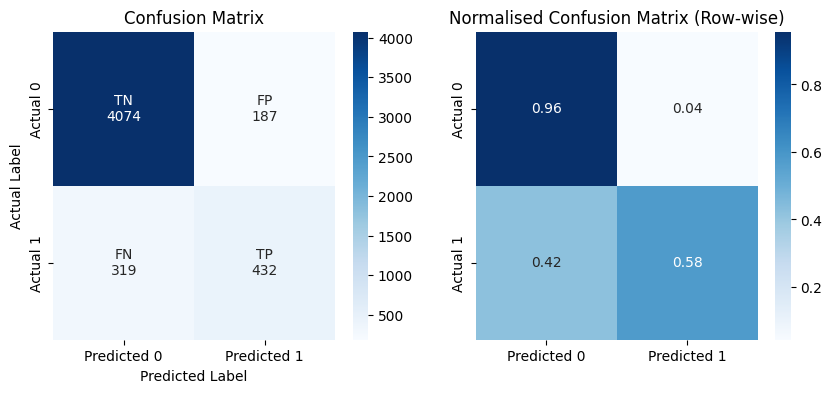

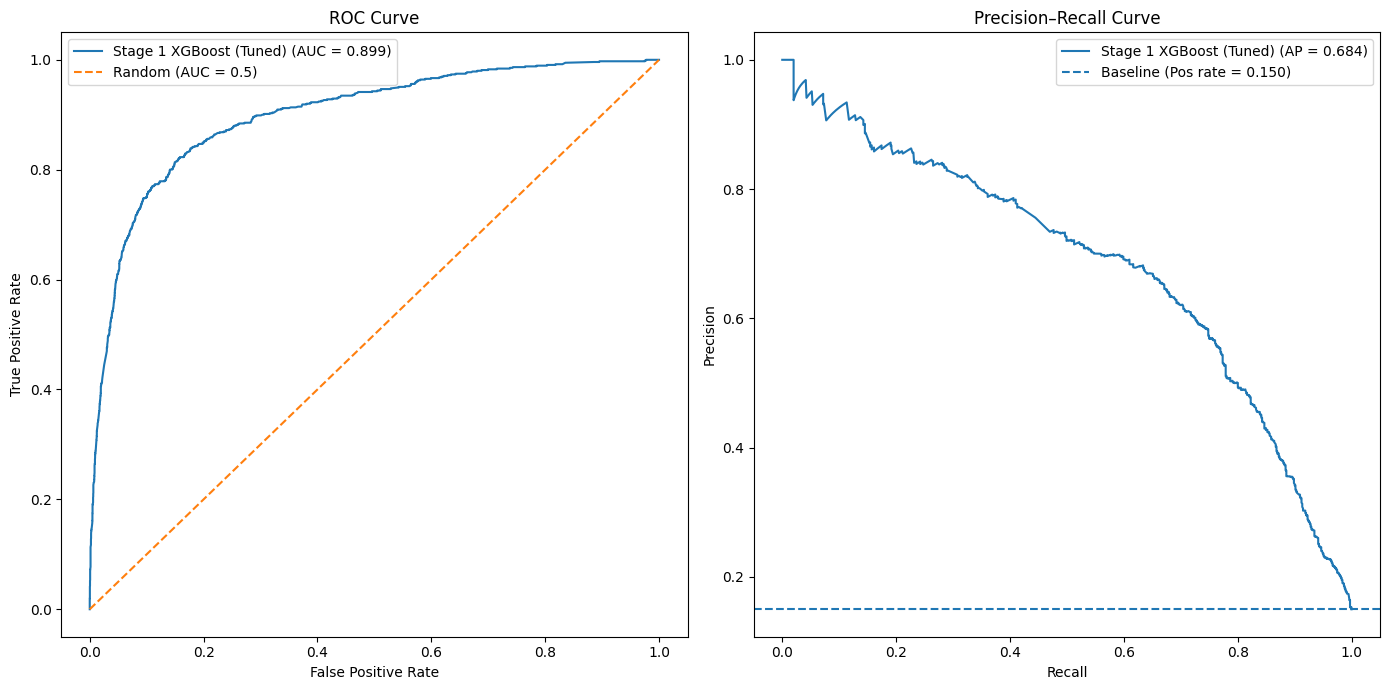

In [85]:
# store the results in the results dictionary for the tuned XGBoost model
m_id = 2  # Unique ID for the tuned model results

results = evaluate_and_store_model(
    results,
    m_id=m_id,
    model_name="Tuned",
    model_type="XGBoost",
    stage="Stage 1",
    y_true=y_test,
    y_pred=y_pred_xgb,
    y_prob=y_prob_xgb,
    hyperparameters=best_xgb_params,
    metadata={"threshold": 0.5},
)

# print the evaluation metrics and plot the confusion matrix for the tuned
# XGBoost model
print_model_metrics(results, m_id)
plot_model_confusion_matrix(results, m_id)

models_to_plot = build_models_to_plot(results, [m_id])
plot_roc_and_pr_curves(models_to_plot, figsize=(14, 7))


### Untuned vs Tuned Comparison

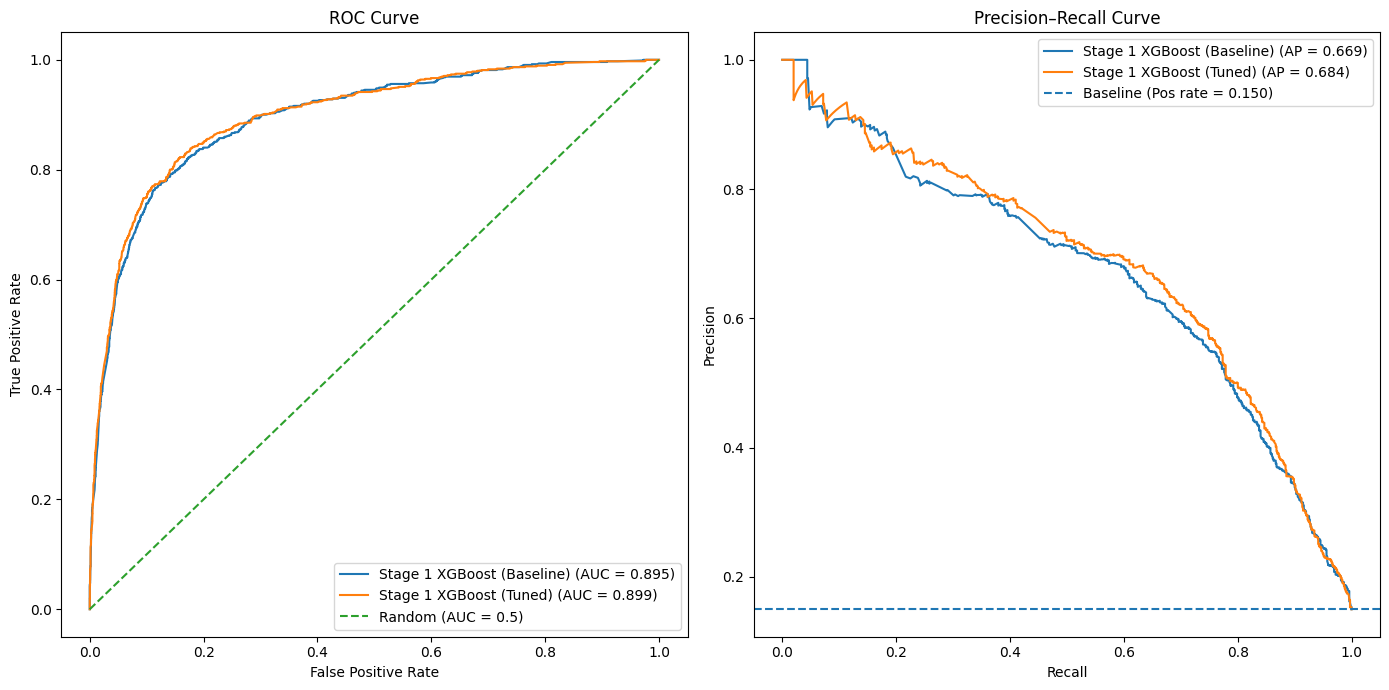

In [86]:
# Finally, we can compare the ROC and Precision-Recall curves for the baseline
# and tuned XGBoost models side by side to see if there has been an improvement
# in performance after hyperparameter tuning.

models_to_plot = build_models_to_plot(results, [1, 2])
plot_roc_and_pr_curves(models_to_plot, figsize=(14, 7))


**Model Comparison (with / without Hyperparameter Tuning)**

---

The tuned model shows only small differences compared with the baseline model. A comparison is shown below:

| Metric      | Baseline   | Tuned      |
| ----------- | ---------- | ---------- |
| Accuracy    | 0.8958     | **0.8990** |
| Precision   | 0.6951     | **0.6979** |
| Recall      | 0.5433     | **0.5752** |
| Specificity | **0.9580** | 0.9561     |
| AUC         | 0.8951     | **0.8988** |


Hyperparameter tuning results in only modest changes across the evaluation metrics, suggesting that the baseline model was already capturing most of the predictive signal available in the dataset. During tuning, validation AUC plateaued at approximately 0.89, indicating that model performance may be approaching the limit achievable with the current feature set.

Validation AUC and test AUC remain very similar, with the test AUC slightly higher. This indicates that the tuned model generalises well to unseen data and does not show clear signs of overfitting.

Compared with the baseline, the tuned model achieves a small improvement in recall, precision, accuracy, and AUC, while specificity decreases slightly, indicating a small increase in false positives when predicting dropout. This behaviour is consistent with a model that is more willing to flag students as at risk in order to capture a greater proportion of true dropouts.

Overall, the tuned model provides a slightly stronger ability to identify students who may fail to complete the course. This trade-off may be acceptable, if failing to identify at-risk students (false negatives) is more costly than incorrectly flagging some students who ultimately complete the course.

---

### Feature Importance

We can now determine feature importance in respect of the trained model. 

Both feature importance and SHAP plots will be created so that we can compare how well they align and use SHAP to better understand magnitude and direction of feature influence.



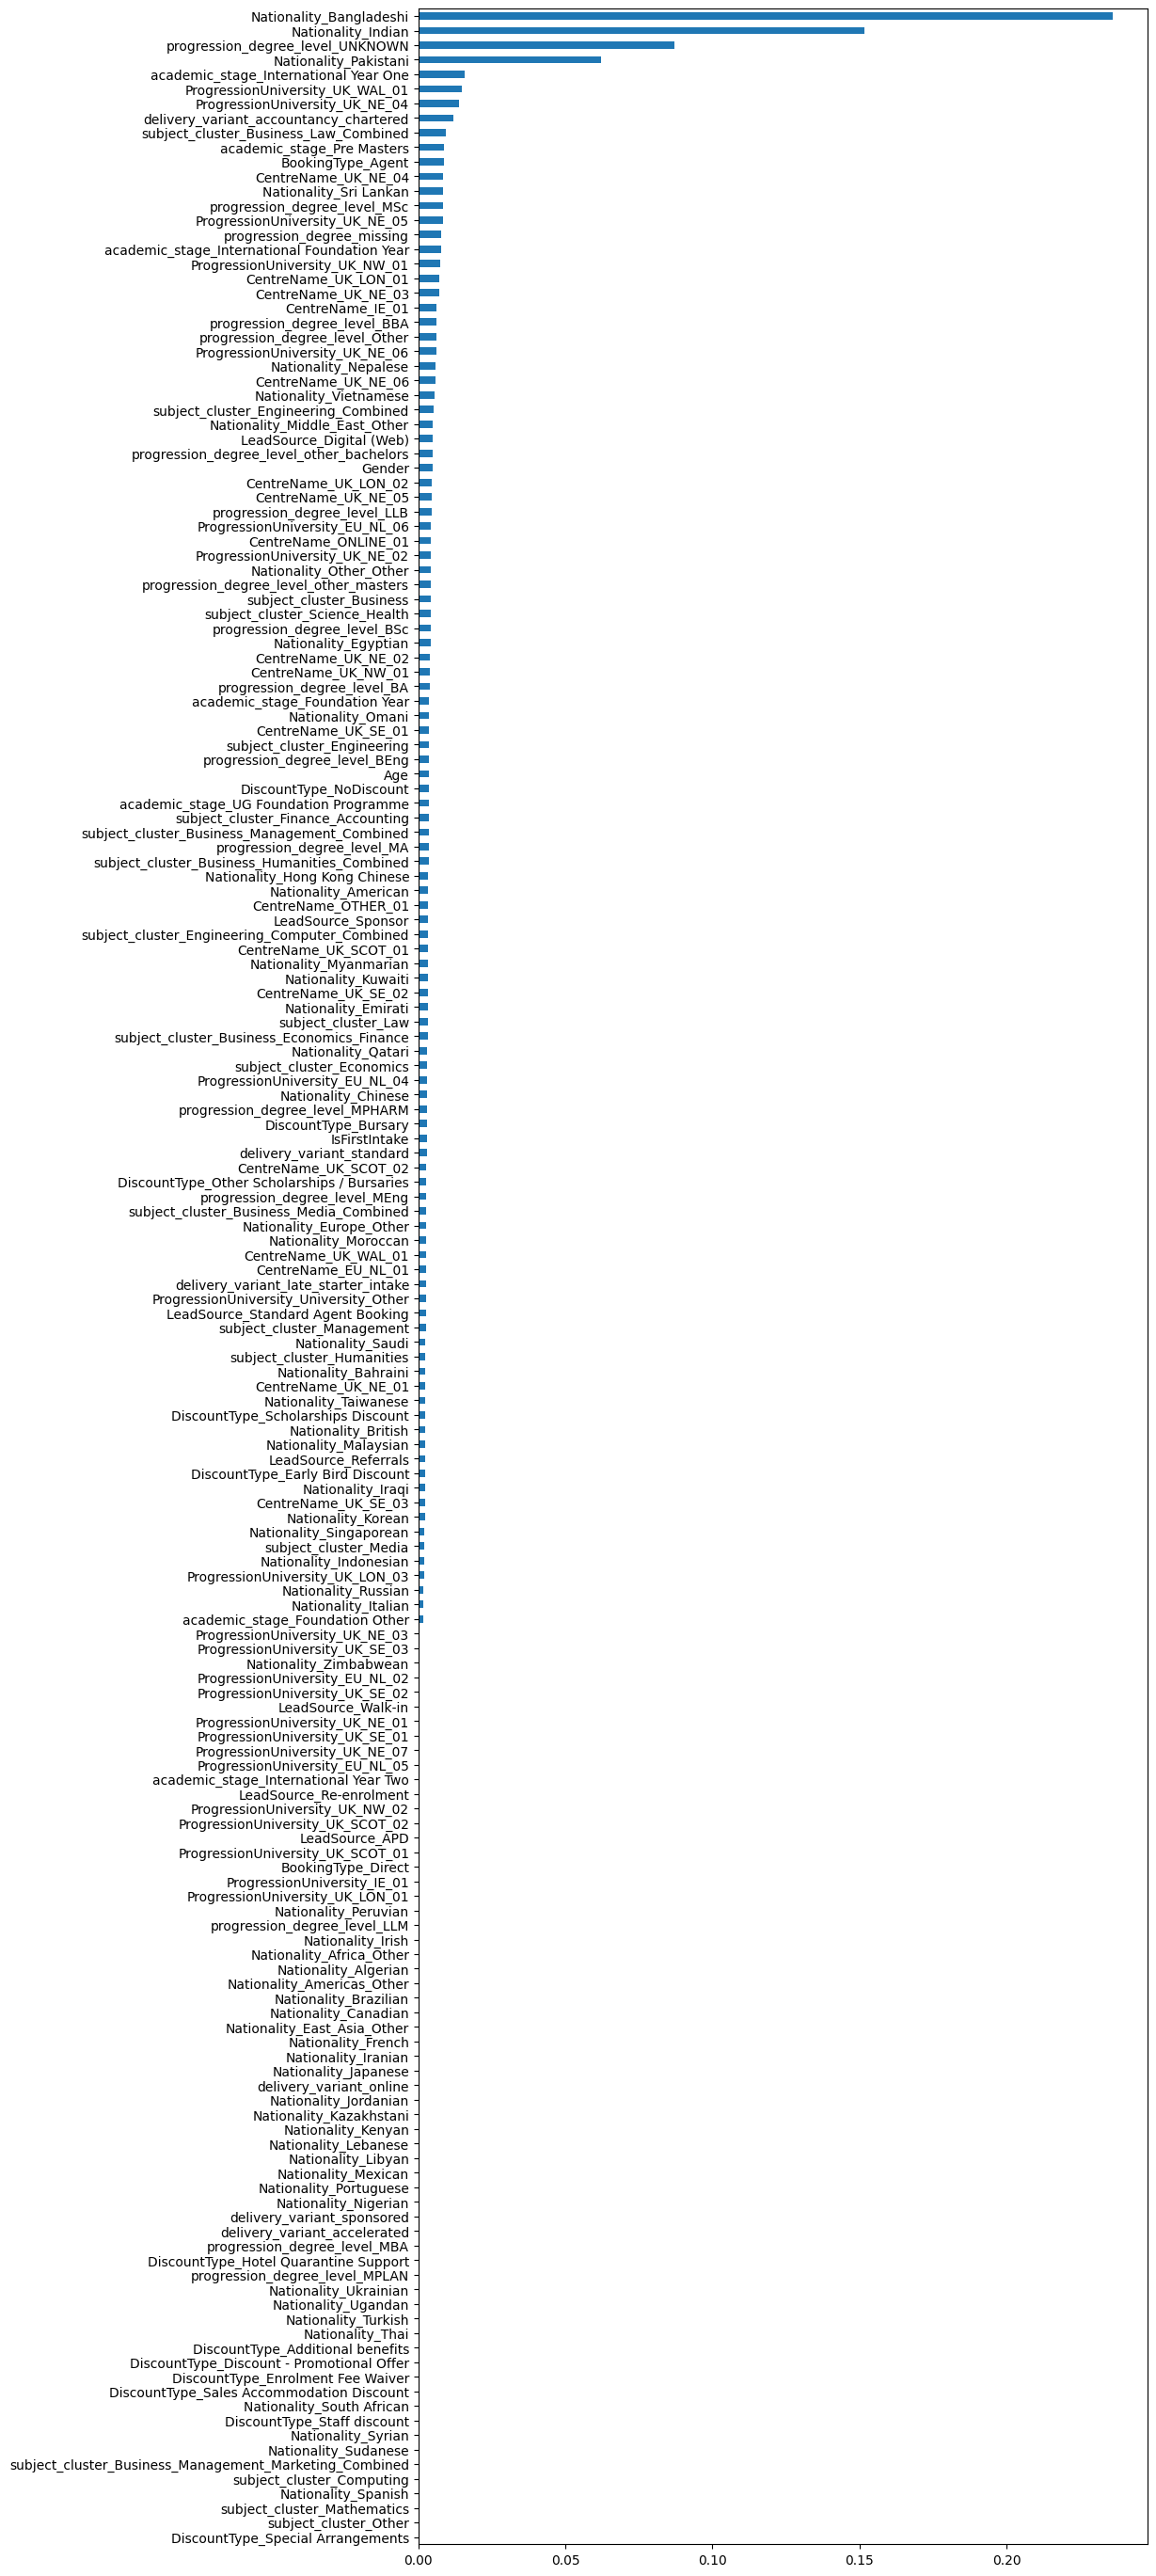

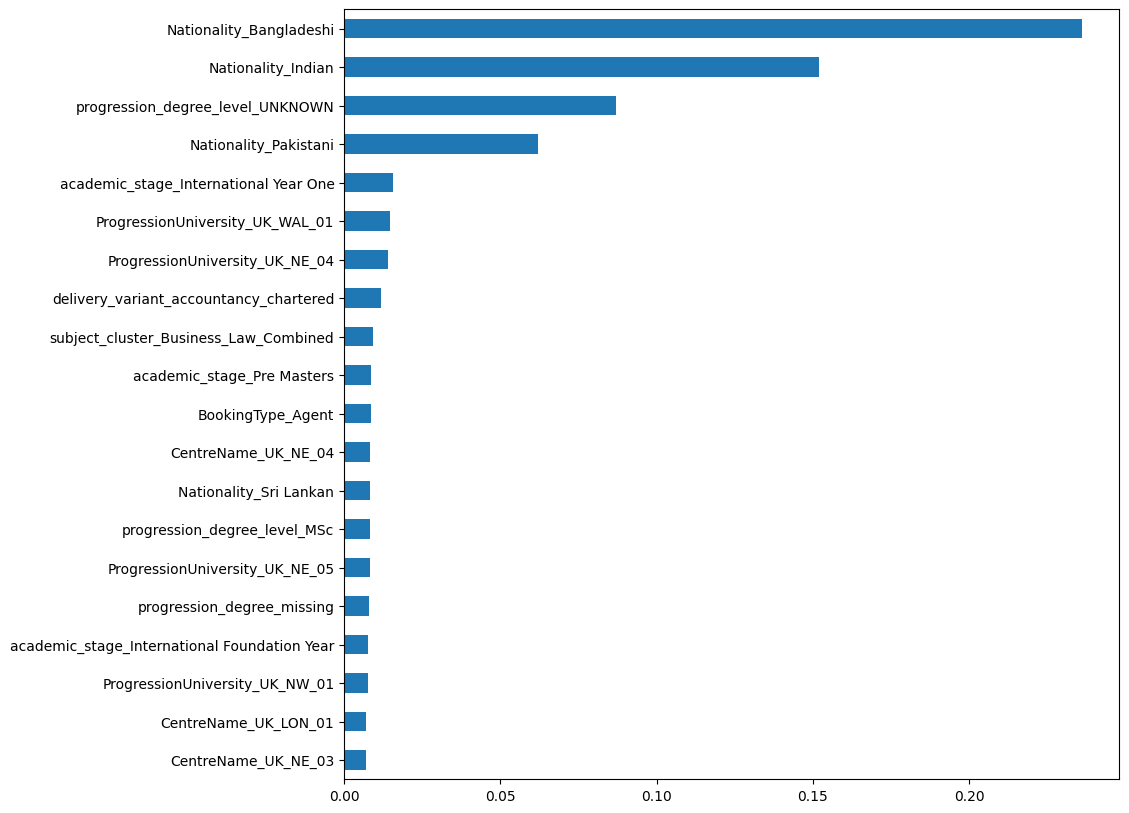

In [87]:
# plot the feature importance for the XGBoost model using the
# feature_importances_ attribute of the fitted model, and display the top
# 20 most important features
feature_importance = pd.Series(
    best_xgb_model.feature_importances_, index=X_train.columns
).sort_values()
plt.figure(figsize=(10, 35))
feature_importance.plot.barh()
plt.show()

plt.figure(figsize=(10, 10))
feature_importance.iloc[-20:].plot.barh()
plt.show()


/tmp/ipykernel_873550/524827228.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_plot, max_display=40, show=False)


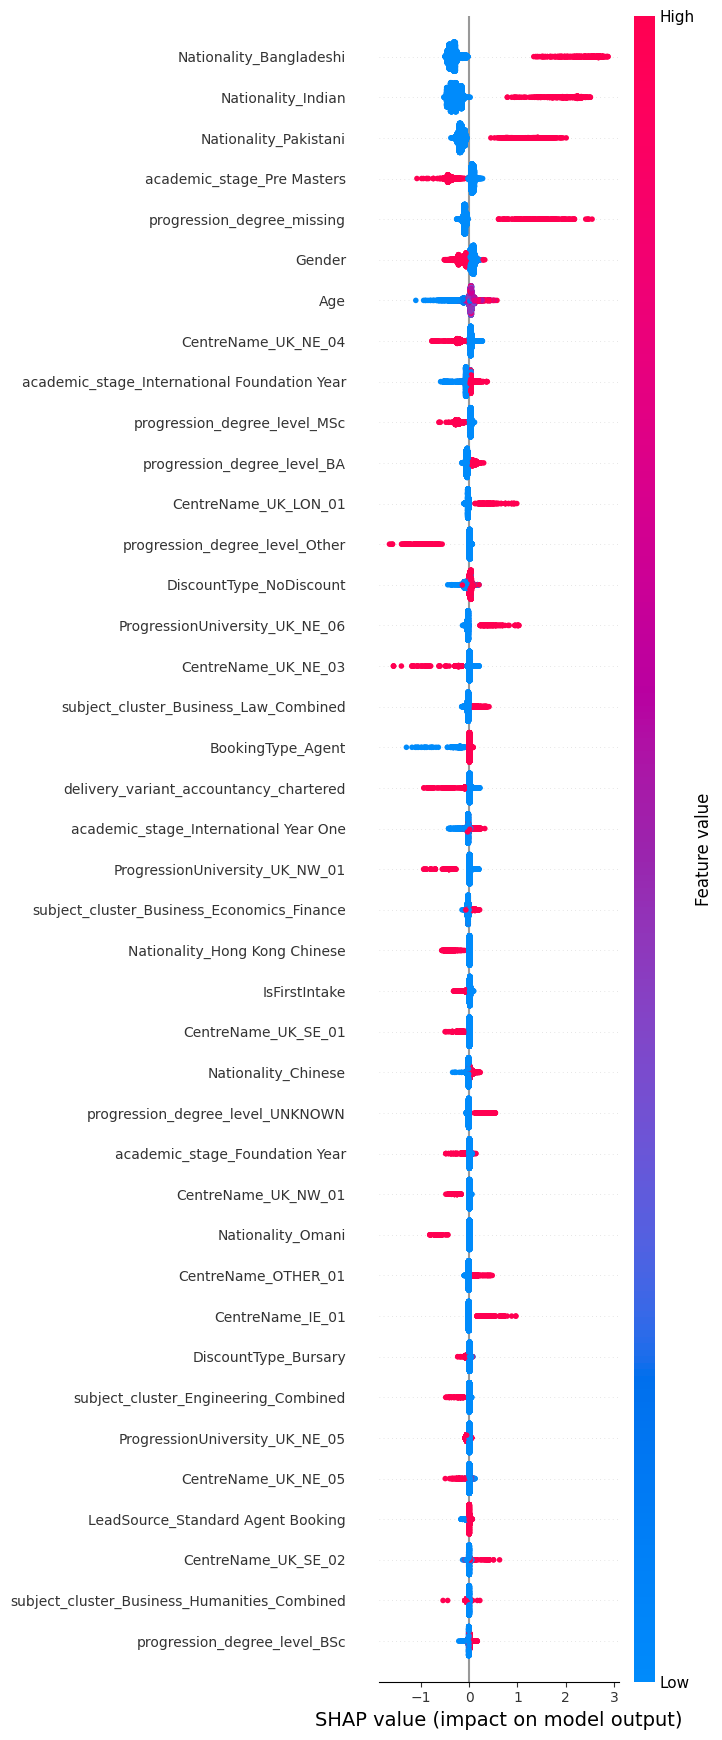

In [88]:
# For the SHAP values, we will use the TreeExplainer which is optimized for
# tree-based models like XGBoost. We will compute the SHAP values for the test
# set and plot a summary plot to visualize the overall feature importance and
# the distribution of SHAP values for the top features.

X_test_plot = X_test.astype(float)

explainer = shap.TreeExplainer(best_xgb_model)
shap_values = explainer.shap_values(X_test_plot)

shap.summary_plot(shap_values, X_test_plot, max_display=40, show=False)

fig = plt.gcf()
ax = plt.gca()

# Reduce font size for feature names (y-axis) and SHAP values (x-axis)
ax.tick_params(axis="both", which="major", labelsize=10)

# Reduce font size for labels
ax.xaxis.label.set_size(14)
ax.yaxis.label.set_size(14)

plt.show()


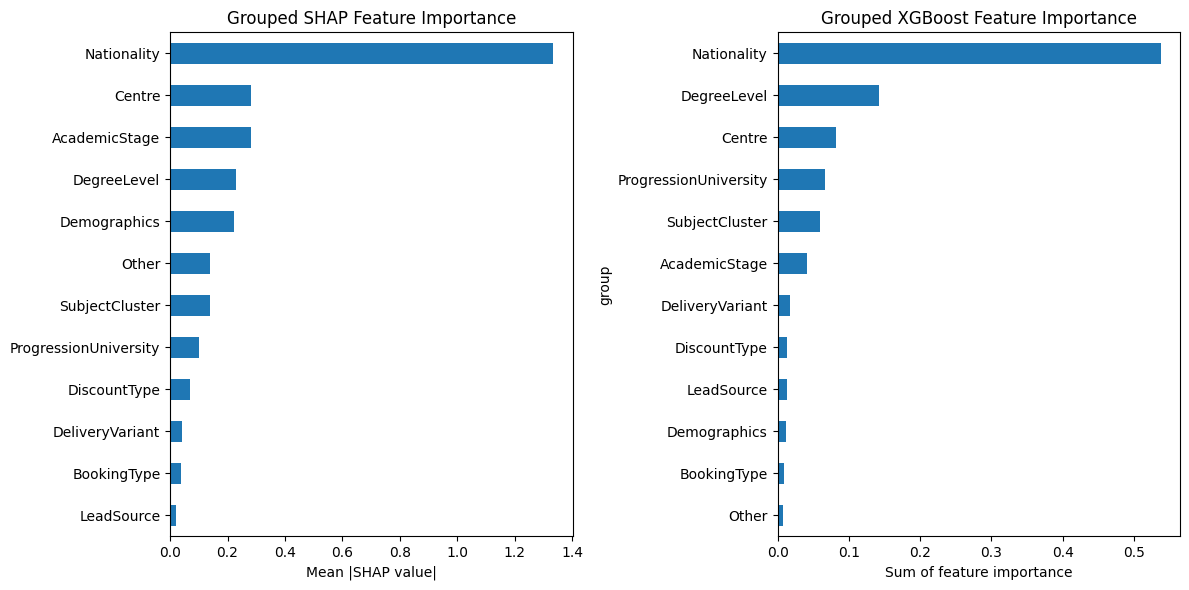

In [89]:
# Finally, we can also plot the grouped feature importance for both the XGBoost
# feature importance and SHAP values side by side for comparison.
# The features are grouped into categories based on their prefixes

plot_grouped_feature_importance(feature_importance, shap_values, X_val)


**Interpretation**

---

Feature importance analysis indicates that nationality and institutional characteristics are the most influential predictors of student progression outcomes. Specifically: 

1) **Nationality dominates the model with top features:**

Several nationality features score highly in model feature importance

2) **Institution / centre features**

Progression outcomes varying by centre:

- CentreName_ISC_London
- CentreName_ISC_Kingston
- CentreName_ISC_Huddersfield
- CentreName_ISC_Sheffield

3) **Progression university features**

- This may be because some universities have stricter entry requirements, and programme difficulty differs.

4) **Academic stage variables**

- academic_stage_International Year One
- academic_stage_Pre Masters

5) **Subject cluster**

- This is expected as subject difficulty can vary significantly across fields.

NOTE: Due to one-hot encoding, importance is spread across many variables (e.g. Nationality), when in reality they represent a single variable.

Several nationality categories appear among the top predictors, suggesting that regional differences in educational readiness may influence progression risk. Institutional factors, including study centre location and progression university, also contribute strongly to predictions. Academic stage and subject cluster provide additional predictive signal, while demographic factors such as age and marketing variables such as lead source or discount type appear to have relatively low influence.

**Comparison with SHAP**

XGBoost's feature_importances_ (defaulting to gain) ranks features by their average contribution to reducing model error. However, high-cardinality features like Nationality can sometimes appear more important simply because they provide many opportunities for splits. Conversely, powerful but sparse features may have lower importance scores because their high predictive impact is limited to a small subset of records, leading to a lower average gain across the entire model ensemble.


XGBoost importance measures how variables are used to split decision trees during model training, while SHAP values measure the contribution of each feature to the final predictions. The grouped and aggregated SHAP feature importance broadly aligns with the model’s feature importance results, although it is important to note that aggregating these features should be interpreted as an approximation rather than the exact importance of the original categorical variable.

SHAP analysis agrees that nationality is the strongest predictor in the model. Academic stage and progression university also contribute meaningfully to predictions, while institutional variables such as study centre and progression university have moderate influence. Demographic features such as age have a smaller but observable effect, and appear to have a larger impact on model predictions than the model importance alone would suggest, while marketing-related variables such as lead source and discount type contribute little predictive power.

Using both metrics provides a more complete view of how features influence both model training and final predictions.

---



## Neural Network Model

### Baseline Model

We will define and instantiate a simple neural network model, fit the model to the dataset and visualise the loss curves.

A reusable model builder function will be created to support later model tuning.



In [90]:

# Set random seeds for reproducibility
tf.keras.backend.clear_session()
set_seed(SEED)

model_path = NN_MODEL_DIR / 'baseline_model_training.keras'
history_path = NN_MODEL_DIR / 'baseline_model_history.h5'

model = build_binary_classifier(
    input_dim=X_train_s.shape[1],
    units=32,
    layers=1,
    dropout=0,
    l2_strength=0,
    lr=1e-3,
)

if model_path.exists():
    model, loaded = load_model_weights(model, model_path)
    if loaded:
        print(f'Model loaded from {model_path}')
        if history_path.exists():
            history_data = pd.read_hdf(history_path, key='history')
            history = type('obj', (object,), {'history': history_data.to_dict(orient='list')})
    else:
        history = None
else:
    history = model.fit(
        X_train_s,
        y_train,
        validation_data=(X_val_s, y_val),
        epochs=15,
        batch_size=64,
        shuffle=False,
        verbose=1,
    )
    model.save(model_path)
    pd.DataFrame(history.history).to_hdf(history_path, key='history', mode='w')


2026-03-25 23:29:29.400031: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-25 23:29:29.599703: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-25 23:29:29.599754: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-25 23:29:29.601561: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-25 23:29:29.601606: I external/local_xla/xla/stream_executor

Keras model loaded from /home/alextd/projects/student-dropout-prediction/models/stage_1/neural_network/baseline_model_training.keras
Model loaded from /home/alextd/projects/student-dropout-prediction/models/stage_1/neural_network/baseline_model_training.keras


### Loss Curves

We'll now plot the loss curves to see how the model training progresses over each epoch.

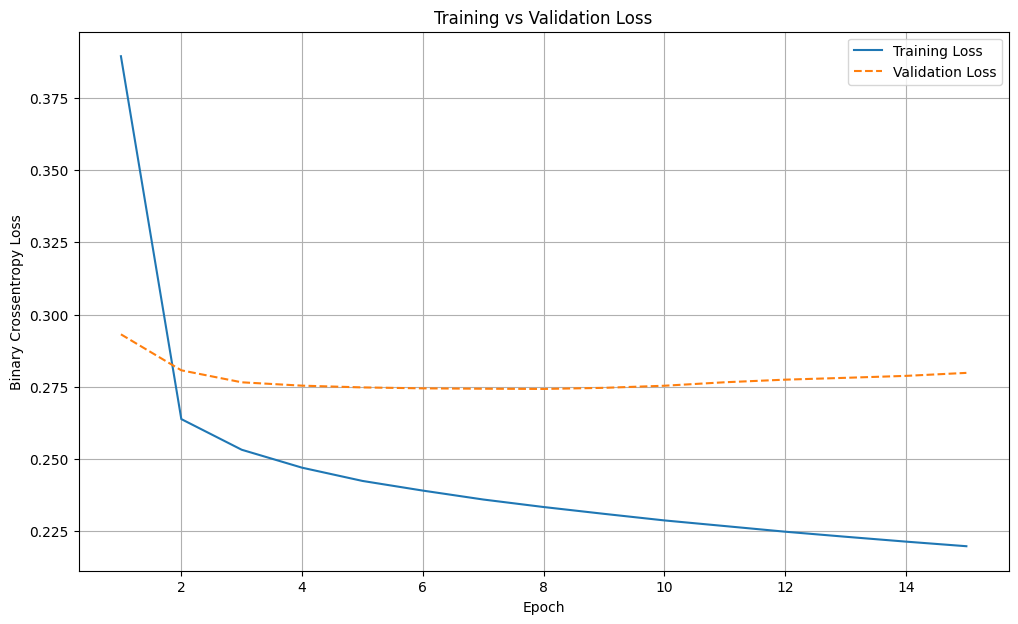

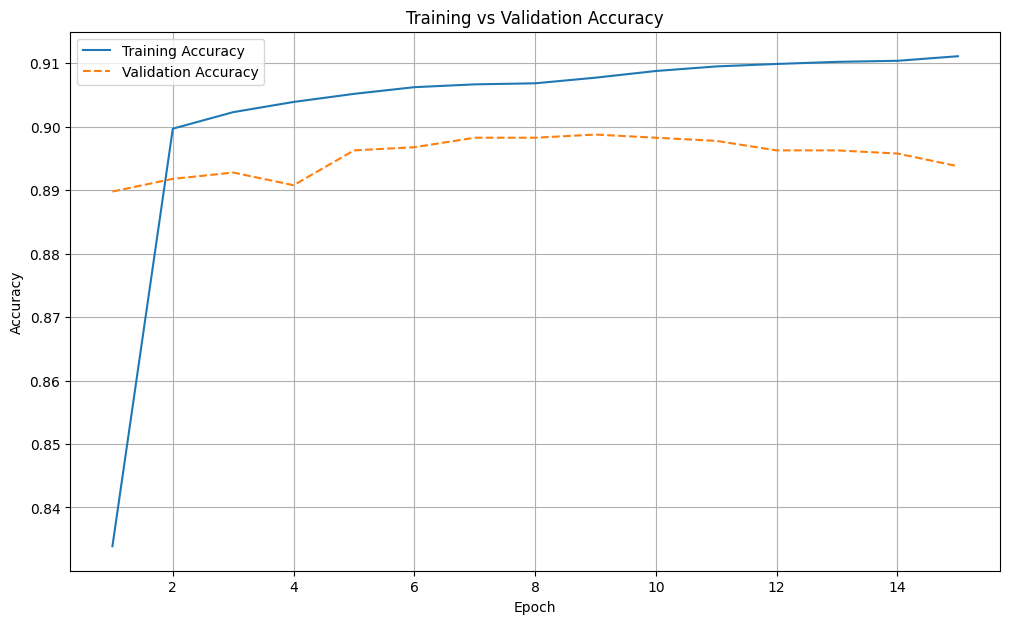

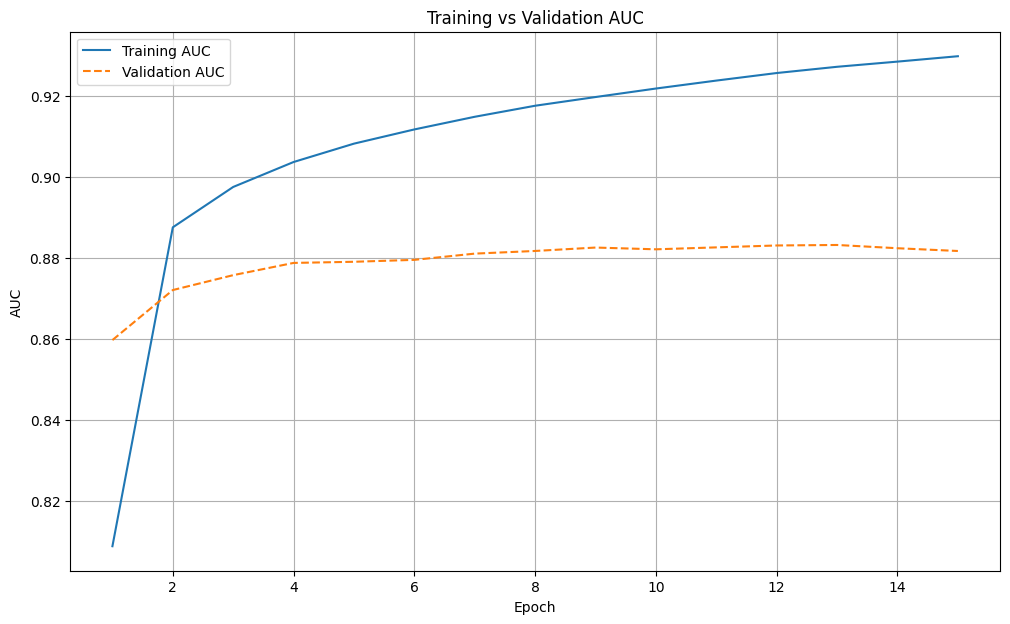

In [91]:
# Evaluate the simple baseline model on the test set to get a benchmark for
# performance before we do any Hyperparameter tuning or model optimization.
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

# Create a range of epoch numbers for the x-axis
epochs = range(1, len(train_loss) + 1)

# Plot training and validation loss over epochs
plt.figure(figsize=(12, 7))
plt.plot(epochs, train_loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss", linestyle="--")

plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

train_accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]

# Plot training and validation accuracy over epochs
plt.figure(figsize=(12, 7))
plt.plot(epochs, train_accuracy, label="Training Accuracy")
plt.plot(epochs, val_accuracy, label="Validation Accuracy", linestyle="--")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


train_auc = history.history["auc"]
val_auc = history.history["val_auc"]

# Plot training and validation AUC over epochs
plt.figure(figsize=(12, 7))
plt.plot(epochs, train_auc, label="Training AUC")
plt.plot(epochs, val_auc, label="Validation AUC", linestyle="--")

plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Training vs Validation AUC")
plt.legend()
plt.grid(True)
plt.show()


**Loss Curves Interpretation**

---

The model appears to generalise reasonably well for a simple baseline architecture (1 dense layer, 32 neurons).

Validation performance peaks around epoch 7–9, beyond that additional training improves training metrics but not validation metrics. Early stopping would be appropriate to minimise overfitting.

**Loss**

- Training loss steadily decreasing
- Validation loss decreases initially, then gradually increases past 6, indicating posibble overfitting to the training data with continued epochs
- There is no sharp divergence between curves.
- Gap between validation and training is modest.

**AUC**

- Training AUC increases steadily to ~0.93.
- Validation AUC peaks around epoch 9-10 (~0.88).


At 15 Epochs this baseline model shows signs of slight overfitting:

- Upward rise in Loss
- Slight decline in AUC
- Divergence between training and validation performance increases gradually.


This represents a valid baseline model for comparison with alternative arichecture models during Hyperparameter tuning.

---

### Baseline Performance Metrics

Performance indicators of Accuracy, precision, recall and AUC will be determined along with a confusion matrix.



In [92]:

tf.keras.backend.clear_session()
set_seed(SEED)

retrain_baseline = False
loaded = False

model_path = NN_MODEL_DIR / 'baseline_model.keras'

model = build_binary_classifier(
    input_dim=X_train_s.shape[1],
    units=32,
    layers=1,
    dropout=0,
    l2_strength=0,
    lr=1e-3,
)

if not retrain_baseline:
    model, loaded = load_model_weights(model, model_path)

if not loaded:
    history = model.fit(
        X_train_s,
        y_train,
        validation_data=(X_val_s, y_val),
        epochs=50,
        batch_size=64,
        verbose=1,
        shuffle=False,
        callbacks=[
            KerasEarlyStopping(
                monitor='val_auc',
                mode='max',
                patience=5,
                restore_best_weights=True,
                min_delta=1e-4,
            )
        ],
    )
    model.save(model_path)


No weights file found at /home/alextd/projects/student-dropout-prediction/models/stage_1/neural_network/baseline_model.keras. Model will be trained from scratch.
Epoch 1/50


I0000 00:00:1774481372.450381  920279 service.cc:145] XLA service 0x6ffa6000bf00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774481372.450487  920279 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2026-03-25 23:29:32.468474: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-25 23:29:32.570201: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


 45/282 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4598 - auc: 0.6403 - loss: 0.9047 - precision: 0.1674 - recall: 0.7608  

I0000 00:00:1774481372.918968  920279 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8339 - auc: 0.8089 - loss: 0.3895 - precision: 0.4530 - recall: 0.5242 - val_accuracy: 0.8898 - val_auc: 0.8597 - val_loss: 0.2932 - val_precision: 0.6908 - val_recall: 0.4767
Epoch 2/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8997 - auc: 0.8875 - loss: 0.2638 - precision: 0.7198 - recall: 0.5409 - val_accuracy: 0.8918 - val_auc: 0.8721 - val_loss: 0.2807 - val_precision: 0.6861 - val_recall: 0.5100
Epoch 3/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9023 - auc: 0.8975 - loss: 0.2532 - precision: 0.7245 - recall: 0.5612 - val_accuracy: 0.8928 - val_auc: 0.8757 - val_loss: 0.2765 - val_precision: 0.6856 - val_recall: 0.5233
Epoch 4/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9039 - auc: 0.9036 - loss: 0.2470 - precision: 0.7291 - recall: 0.5705 - val_accuracy: 0.8908 - val_auc: 0.8787 - val_loss: 0.2754 - val_precision: 0.6695 - val_recall: 0.5333
Epoch 5/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 

Stage 1 Neural Network - Baseline Performance Metrics:
Accuracy:    0.8951
Precision:   0.6692
Recall:      0.5925
Specificity: 0.9484
AUC:         0.8899


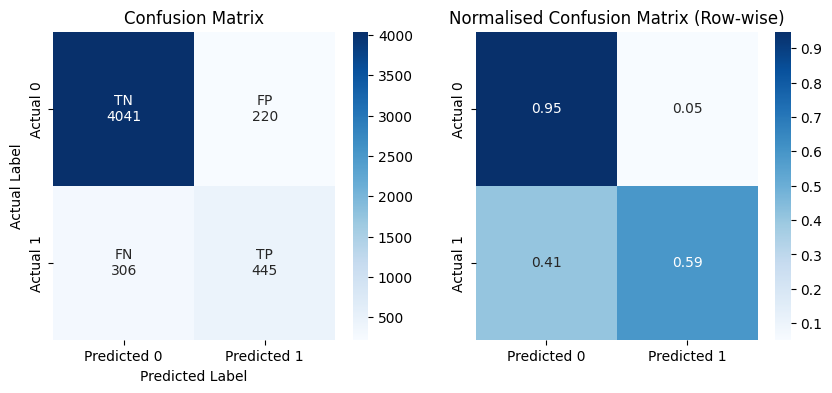

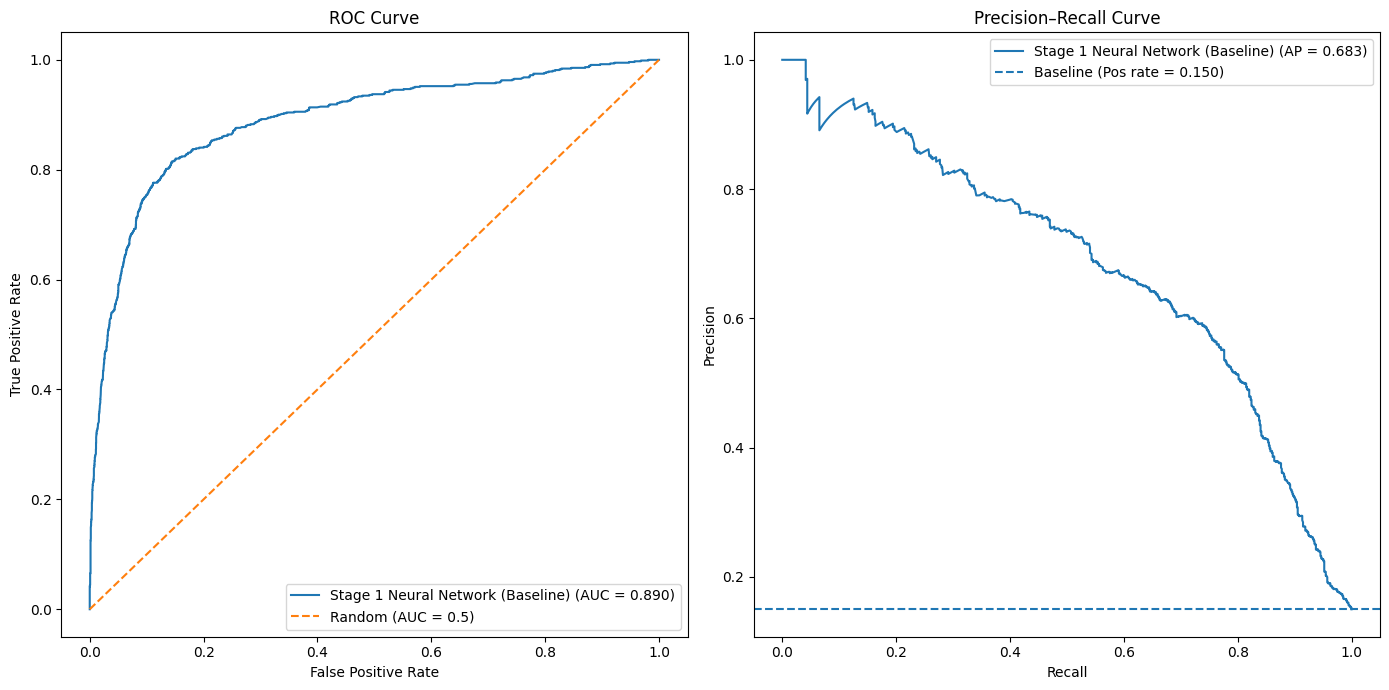

In [93]:
# Predict probabilities
y_prob = model.predict(X_test_s, verbose=0).ravel()
# Convert probabilities to binary predictions using a threshold of 0.5
y_pred = (y_prob >= 0.5).astype(int)

# store the results in a dictionary for easy comparison with other models
# later on
params = {
    "epochs": 50,
    "batch_size": 64,
    "units": 32,
    "layers": 1,
    "dropout": 0,
    "l2_strength": 0,
    "lr": 1e-3,
    "optimiser": "adam",
    "activation": "relu",
    "earlystopping": {
        "monitor": "val_auc",
        "mode": "max",
        "patience": 5,
        "restore_best_weights": True,
        "min_delta": 1e-4,
    },
}

m_id = 3  # unique identifier for this model in the results dictionary

results = evaluate_and_store_model(
    results,
    m_id=m_id,
    model_name="Baseline",
    model_type="Neural Network",
    stage="Stage 1",
    y_true=y_test,
    y_pred=y_pred,
    y_prob=y_prob,
    hyperparameters=params,
    metadata={"threshold": 0.5},
)

# print the evaluation metrics and plot the confusion matrix for the baseline
# NN model
print_model_metrics(results, m_id)
plot_model_confusion_matrix(results, m_id)

models_to_plot = build_models_to_plot(results, [m_id])
plot_roc_and_pr_curves(models_to_plot, figsize=(14, 7))


**Interpretation**

---

**Accuracy = 0.8951**

With ~15% positive rate, a trivial model that predicts all negatives would achieve:

- 4261 / 5012 ≈ 0.85

The neural network improves accuracy by ~4–5 percentage points over this baseline, indicating that the model is learning useful signal rather than relying on class imbalance.

**Precision = 0.6687**

When the model predicts a student will drop out, it is correct about 67% of the time.

This reflects the difficulty of the task, as dropout cases are relatively rare and harder to separate from completers.

**Recall = 0.5939**

The model correctly identifies about 59% of actual dropouts.

This means around 41% of at-risk students are not detected, which may limit the effectiveness of early intervention if recall is prioritised.

**Specificity = 0.9481**

The model correctly identifies approximately 95% of actual completers.

This indicates that false alarms are relatively low, so intervention effort would remain focused on a smaller group of students.


**AUC = 0.8902**

- Test AUC = 0.8902

The very small difference between validation and test performance suggests that the model is not overfitting, and generalises reasonably well to unseen data.

The ROC curve shows strong separation between classes across thresholds, and the PR curve remains well above the baseline positive rate (0.15).

**Summary**

The baseline neural network provides balanced performance, with good overall discrimination (AUC ≈ 0.89), moderate recall for dropout detection (~59%), and high specificity (~95%).

This may not be optimal if the business is willing to tolerate additional false positives in order to identify a greater proportion of at-risk students and enable earlier intervention. In such cases, the classification threshold can be adjusted to shift the balance between recall and specificity, allowing the model outputs to be aligned with business priorities without retraining the model.

---

### HyperParameter Tuning




We will now try to improve on the baseline model by exploring alternative neural-network hyperparameters using AUC as the primary selection metric.

Saved tuning artefacts are loaded by default so this public notebook can be rerun quickly. Full Keras Tuner searches are computationally expensive, so `RUN_NN_TUNING` is set to `False` by default. Set it to `True` if you want to regenerate the search results from scratch.

**Initial tuning strategy.**

---

A model will be instantiated and then trained on multiple combinations of the following initial hyperparameter search space.


In [94]:
tf.keras.backend.clear_session()
set_seed(SEED)

SEARCH_SPACE = {
    'units': {'min_value': 16, 'max_value': 256, 'step': 16},
    'layers': {'min_value': 1, 'max_value': 4},
    'dropout': {'min_value': 0.0, 'max_value': 0.5, 'step': 0.1},
    'activation': ['relu', 'tanh', 'elu'],
    'optimizer': ['adam', 'rmsprop'],
    'lr': [1e-2, 3e-3, 1e-3, 3e-4],
    'l2_strength': [0.0, 1e-6, 1e-5, 1e-4, 1e-3],
}

best_hp, tuner = run_keras_tuner(
    max_trials=NN_INITIAL_N_TRIALS,
    project_name='nn_tabular_auc',
    X_train=X_train_s,
    y_train=y_train,
    X_val=X_val_s,
    y_val=y_val,
    overwrite=False,
    artifact_dir=NN_TUNING_DIR,
    run_search=RUN_NN_TUNING,
    load_saved=LOAD_SAVED_TUNING,
    resume_search=RESUME_NN_TUNING,
    artifact_prefix='initial',
)

if best_hp is not None:
    print(f'Best hyperparameters: {best_hp.values}')


Reloading Tuner from /home/alextd/projects/student-dropout-prediction/tuning/stage_1/neural_network/keras_tuner/nn_tabular_auc/tuner0.json
Skipping NN tuning and loading saved results from /home/alextd/projects/student-dropout-prediction/tuning/stage_1/neural_network/keras_tuner/nn_tabular_auc
Best hyperparameters: {'units': 240, 'layers': 3, 'activation': 'relu', 'optimizer': 'adam', 'lr': 0.0003, 'dropout': 0.30000000000000004, 'l2_strength': 0.0001}


/home/alextd/venvs/tf-gpu311/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


,units,layers,activation,optimizer,lr,dropout,l2_strength,trial_id,status,val_auc,val_precision,val_recall,val_accuracy,val_loss
1700,240,3,relu,adam,0.0003,0.3,0.000100,1863,COMPLETED,0.887186,0.726087,0.556667,0.902244,0.318477
198,48,1,relu,adam,0.0010,0.4,0.000000,0623,COMPLETED,0.886975,0.729858,0.513333,0.898753,0.286746
1591,64,1,relu,adam,0.0003,0.4,0.000100,0704,COMPLETED,0.886453,0.718615,0.553333,0.900748,0.283440
1320,112,1,tanh,rmsprop,0.0010,0.3,0.000010,1672,COMPLETED,0.886318,0.703704,0.506667,0.894264,0.278514
842,112,4,tanh,adam,0.0003,0.3,0.000000,1322,COMPLETED,0.886283,0.694215,0.560000,0.897257,0.273470
2,48,1,relu,adam,0.0010,0.2,0.000010,1256,COMPLETED,0.886164,0.734884,0.526667,0.900748,0.277333
1287,112,4,tanh,rmsprop,0.0003,0.1,0.000000,0134,COMPLETED,0.886015,0.731959,0.473333,0.895262,0.269980
318,16,2,elu,adam,0.0010,0.0,0.000001,1255,COMPLETED,0.885854,0.746412,0.520000,0.901746,0.271988
519,256,1,relu,adam,0.0003,0.3,0.000010,1348,COMPLETED,0.885777,0.728507,0.536667,0.900748,0.280909
613,176,2,relu,adam,0.0003,0.4,0.000100,1975,COMPLETED,0.885721,0.739726,0.540000,0.902743,0.295644


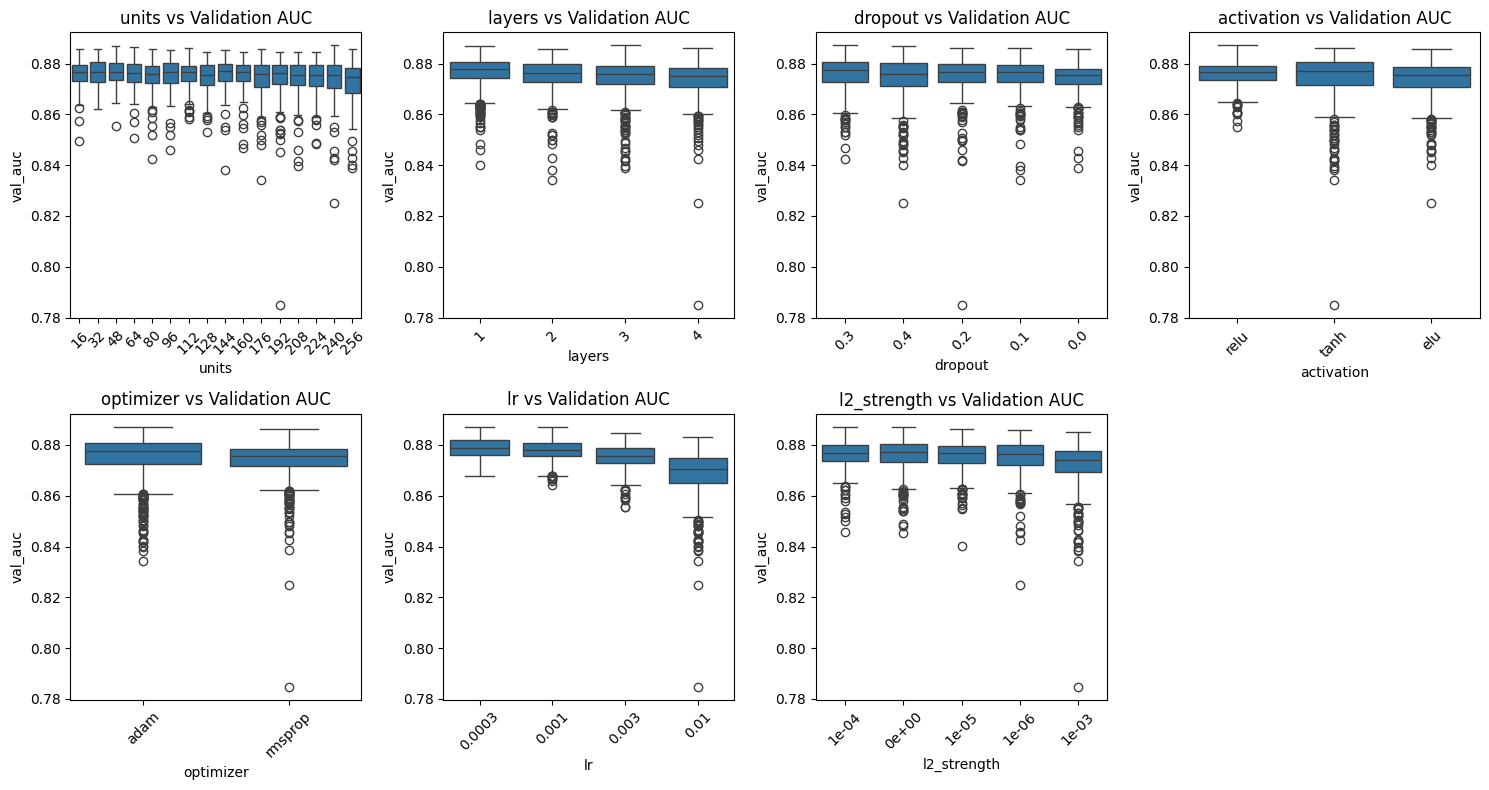

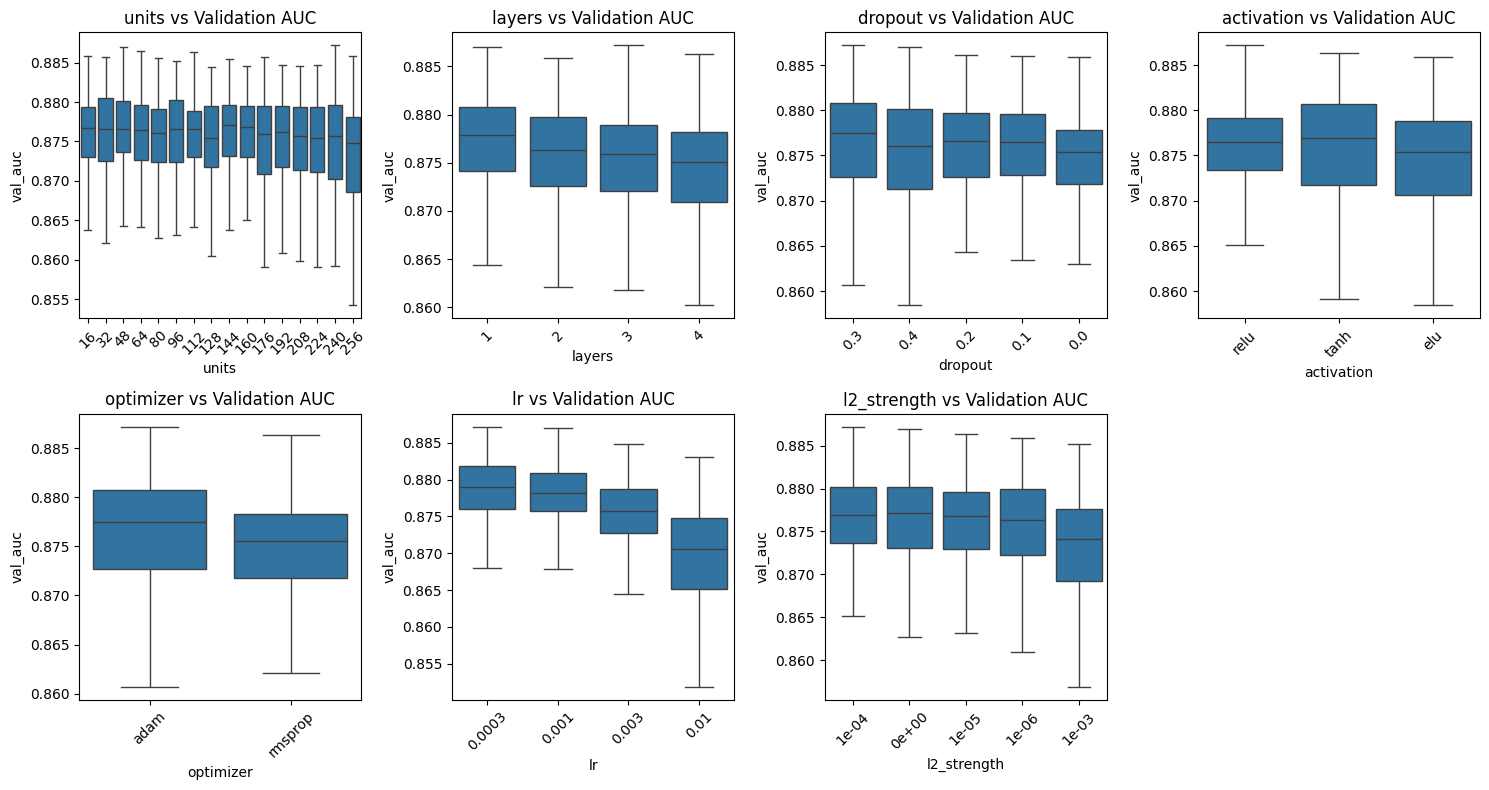

In [95]:

initial_trials_path = NN_TUNING_DIR / TUNING_ARTIFACT_FILENAMES['initial_trials']

if tuner is not None:
    results_df = tuner_trials_to_dataframe(tuner)
elif initial_trials_path.exists():
    results_df = pd.read_csv(initial_trials_path).sort_values('val_auc', ascending=False)
    print(f'Loaded saved NN tuning trials from {initial_trials_path}')
else:
    results_df = pd.DataFrame()
    print('No initial NN tuning trials are available. Set RUN_NN_TUNING = True to generate them.')

hyperparams = ['units', 'layers', 'dropout', 'activation', 'optimizer', 'lr', 'l2_strength']

if not results_df.empty:
    display(HTML('<div style="max-height:330px; overflow:auto;">' + results_df.to_html() + '</div>'))
    results_df_formatted = results_df.copy()
    results_df_formatted['lr'] = results_df_formatted['lr'].map(lambda x: f'{x:.4g}')
    results_df_formatted['dropout'] = results_df_formatted['dropout'].map(lambda x: f'{x:.1f}')
    results_df_formatted['l2_strength'] = results_df_formatted['l2_strength'].map(lambda x: f'{x:.0e}')
    plot_hyperparameter_relationships(results_df_formatted, hyperparams)
    plot_hyperparameter_relationships(results_df_formatted, hyperparams, showfliers=False)



Feature importance:
lr                   0.325052
units                0.164708
layers               0.117895
l2_strength          0.116921
dropout              0.098922
activation_tanh      0.060728
activation_relu      0.036576
activation_elu       0.036150
optimizer_rmsprop    0.021952
optimizer_adam       0.021095
dtype: float64

Surrogate performance:
R2: 0.9619830556356417
RMSE: 0.0014167690620021888


/home/alextd/projects/student-dropout-prediction/src/notebook_helpers.py:600: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


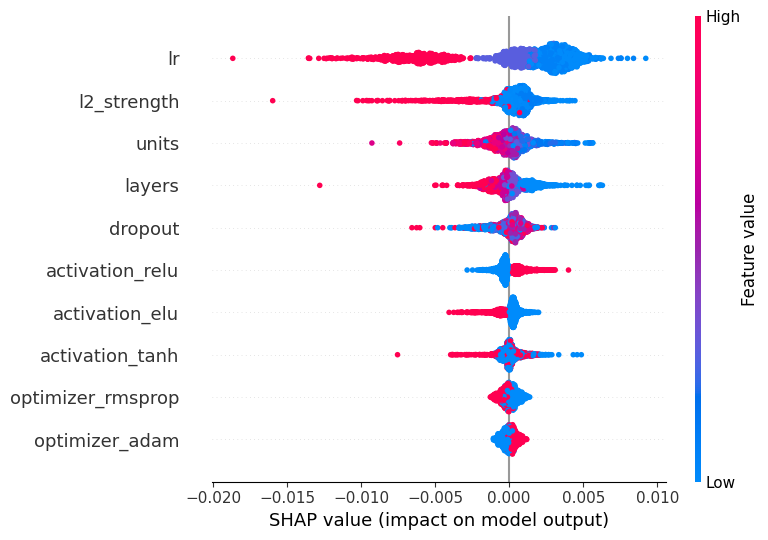

In [96]:

if not results_df.empty:
    rf, importances, r2, rmse = analyze_hp_importance(results_df, hyperparams)
else:
    print('Skipping NN hyperparameter-importance analysis because no trial history is available.')


**Refined Tuning**

---

The box plots, SHAP plot, and tabular results provide evidence which allow us to tighten the search parameters as follows:

| Hyperparameter  | Initial Range          | Refined Range             | Combinations | Evidence Summary |
|---------------|----------------------|-------------------------|------------|----------------|
| **units**       | 16–256                 | **32–192 (step 16)**      | **11** | Similar performance across small–medium models; very large models show slightly higher variance |
| **layers**      | 1–4                    | **1–4**                   | **4**  | Performance similar across depths; no consistent benefit from deeper networks |
| **dropout**     | 0.0–0.5                | **0.0–0.4 (step 0.1)**    | **5**  | Moderate dropout gives similar or slightly better performance; extreme values not beneficial |
| **activation**  | relu, tanh, elu        | **relu, tanh**            | **2**  | ELU consistently lower median validation AUC |
| **optimizer**   | adam, rmsprop          | **adam, rmsprop**         | **2**  | Adam and RMSprop show similar performance; both retained |
| **lr**          | 1e-2, 3e-3, 1e-3, 3e-4 | **3e-4, 1e-3**            | **2**  | Higher learning rates reduce stability; lower values give higher and more consistent AUC |
| **l2_strength** | 0.0–1e-3               | **0.0, 1e-6, 1e-5, 1e-4** | **4**  | Strong regularisation reduces performance; small or zero L2 performs best |                                                                       |


Additional insight is provided by the SHAP analysis of the tuning results. The SHAP summary plot shows that learning rate, L2 regularisation strength, and network size parameters (units and layers) have the largest impact on validation AUC, while activation function and optimizer choice contribute relatively little to performance variation.

Higher learning rates and stronger regularisation are generally associated with negative SHAP values, indicating reduced model performance, whereas moderate network sizes and lower regularisation tend to produce positive contributions. This supports narrowing the search space around smaller learning rates, weaker regularisation, and mid-range model sizes.

The box plots, SHAP analysis, and tabular tuning results show that learning rate has the strongest influence on validation AUC, followed by L2 regularisation and model size parameters (units and layers). Dropout has a moderate effect, while activation function and optimizer choice have minimal impact. These results support narrowing the search space around smaller learning rates, weak regularisation, and mid-range model sizes.


---

**Resulting Search Space**

The refined search space contains approximately 7,040 possible hyperparameter combinations, reduced from the initial wide search. A random search of 200 trials will be used to sample this space, providing approximately 2.8% coverage while keeping the computational cost manageable.




In [97]:
tf.keras.backend.clear_session()
set_seed(SEED)

SEARCH_SPACE = {
    'units': {'min_value': 32, 'max_value': 192, 'step': 16},
    'layers': {'min_value': 1, 'max_value': 4},
    'dropout': {'min_value': 0.0, 'max_value': 0.4, 'step': 0.1},
    'activation': ['relu', 'tanh'],
    'optimizer': ['adam'],
    'lr': [3e-4, 1e-3],
    'l2_strength': [0.0, 1e-6, 1e-5, 1e-4],
}

best_hp_values, tuner = run_keras_tuner(
    max_trials=NN_N_TRIALS,
    project_name='nn_tabular_auc_refined',
    X_train=X_train_s,
    y_train=y_train,
    X_val=X_val_s,
    y_val=y_val,
    overwrite=False,
    artifact_dir=NN_TUNING_DIR,
    run_search=RUN_NN_TUNING,
    load_saved=LOAD_SAVED_TUNING,
    resume_search=RESUME_NN_TUNING,
)


Reloading Tuner from /home/alextd/projects/student-dropout-prediction/tuning/stage_1/neural_network/keras_tuner/nn_tabular_auc_refined/tuner0.json
Skipping NN tuning and loading saved results from /home/alextd/projects/student-dropout-prediction/tuning/stage_1/neural_network/keras_tuner/nn_tabular_auc_refined


/home/alextd/venvs/tf-gpu311/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [98]:

refined_trials_path = NN_TUNING_DIR / TUNING_ARTIFACT_FILENAMES['trials']

if tuner is not None:
    results_df_refined = tuner_trials_to_dataframe(tuner)
elif refined_trials_path.exists():
    results_df_refined = pd.read_csv(refined_trials_path).sort_values('val_auc', ascending=False)
    print(f'Loaded saved refined NN tuning trials from {refined_trials_path}')
else:
    results_df_refined = pd.DataFrame()
    print('No refined NN tuning trials are available. Set RUN_NN_TUNING = True to generate them.')

if not results_df_refined.empty:
    display(HTML('<div style="max-height:330px; overflow:auto;">' + results_df_refined.to_html() + '</div>'))


,units,layers,activation,optimizer,lr,dropout,l2_strength,trial_id,status,val_auc,val_precision,val_recall,val_accuracy,val_loss
188,48,1,relu,adam,0.0010,0.2,0.000001,127,COMPLETED,0.886695,0.737089,0.523333,0.900748,0.274924
175,144,3,tanh,adam,0.0003,0.4,0.000000,185,COMPLETED,0.886557,0.703390,0.553333,0.898254,0.273876
84,80,1,relu,adam,0.0003,0.1,0.000001,058,COMPLETED,0.886118,0.727679,0.543333,0.901247,0.275596
122,112,3,relu,adam,0.0003,0.4,0.000000,073,COMPLETED,0.885882,0.721030,0.560000,0.901746,0.274986
81,160,2,tanh,adam,0.0003,0.1,0.000100,018,COMPLETED,0.885881,0.710407,0.523333,0.896758,0.297938
60,176,4,tanh,adam,0.0010,0.4,0.000000,041,COMPLETED,0.885657,0.722222,0.520000,0.898254,0.271641
124,128,4,tanh,adam,0.0003,0.4,0.000001,179,COMPLETED,0.885587,0.689922,0.593333,0.899252,0.278000
109,64,2,relu,adam,0.0010,0.3,0.000001,070,COMPLETED,0.885238,0.742424,0.490000,0.898254,0.282524
134,96,3,tanh,adam,0.0010,0.2,0.000010,104,COMPLETED,0.885238,0.705882,0.560000,0.899252,0.274832
108,192,3,tanh,adam,0.0003,0.4,0.000000,068,COMPLETED,0.885227,0.715517,0.553333,0.900249,0.273817



**Refined Hyperparameter Tuning Results**

The best AUC score from the initial hyperparameter RandomSearch has not been improved.

Across both tuning stages, the strongest models consistently fall within a narrow performance band of approximately 0.882–0.887 validation AUC. 

**Best Models - Evaluation**

It is important to note that wide range of model architectures appear within the ~0.882–0.887 AUC range. Small differences in validation AUC may reflect stochastic training variation rather than increased model performance. We will attempt to further evaluate model performance and stability as follows:

***Select the top 5 configurations and retrain each:***

- 3 different random seeds + original SEED value to validate repeatability
- batch size = 64
- same early stopping criteria
- same train/validation split

We will compute:

- mean validation AUC
- standard deviation

This may provide a more robust estimate of model performance and identify architectures that are both high performing and stable across training runs.

In [99]:

if not results_df.empty and not results_df_refined.empty:
    results_df_combined = pd.concat(
        [
            results_df.assign(source='initial'),
            results_df_refined.assign(source='refined'),
        ],
        ignore_index=True,
    )
    top_configs = results_df_combined.sort_values('val_auc', ascending=False).head(5)
else:
    fallback_params = load_saved_best_params(NN_TUNING_DIR / TUNING_ARTIFACT_FILENAMES['best_params']) or {
        'units': 32,
        'layers': 1,
        'activation': 'relu',
        'optimizer': 'adam',
        'lr': 1e-3,
        'dropout': 0.0,
        'l2_strength': 0.0,
    }
    results_df_combined = pd.DataFrame([fallback_params]).assign(source='saved_best_params', val_auc=np.nan)
    top_configs = results_df_combined.copy().head(1)
    print('Using the saved refined Stage 1 NN configuration because no full NN tuning history is available in this clone.')

print('Top performing hyperparameter combinations from both searches:')
display(HTML('<div style="max-height:330px; overflow:auto;">' + top_configs.to_html() + '</div>'))


Top performing hyperparameter combinations from both searches:


,units,layers,activation,optimizer,lr,dropout,l2_strength,trial_id,status,val_auc,val_precision,val_recall,val_accuracy,val_loss,source
0,240,3,relu,adam,0.0003,0.3,0.000100,1863,COMPLETED,0.887186,0.726087,0.556667,0.902244,0.318477,initial
1,48,1,relu,adam,0.0010,0.4,0.000000,0623,COMPLETED,0.886975,0.729858,0.513333,0.898753,0.286746,initial
2000,48,1,relu,adam,0.0010,0.2,0.000001,127,COMPLETED,0.886695,0.737089,0.523333,0.900748,0.274924,refined
2001,144,3,tanh,adam,0.0003,0.4,0.000000,185,COMPLETED,0.886557,0.703390,0.553333,0.898254,0.273876,refined
2,64,1,relu,adam,0.0003,0.4,0.000100,0704,COMPLETED,0.886453,0.718615,0.553333,0.900748,0.283440,initial


In [100]:

update_stability = False

filepath = NN_TUNING_DIR / TUNING_ARTIFACT_FILENAMES['stability_data']
if filepath.exists() and not update_stability:
    stability_df = pd.read_hdf(filepath, 'stability')
elif len(top_configs) == 1 and top_configs['source'].iloc[0] == 'saved_best_params':
    stability_df = top_configs.copy()
    stability_df['config_idx'] = 1
    stability_df['seed_scores'] = [[]]
    stability_df['mean_val_auc'] = [np.nan]
    stability_df['std_val_auc'] = [np.nan]
    print('Skipping NN stability analysis because saved tuning history is not available. Using the saved best Stage 1 configuration directly.')
else:
    early_stop = KerasEarlyStopping(monitor='val_auc', mode='max', patience=5, restore_best_weights=True, min_delta=1e-4)
    seeds = STABILITY_SEEDS
    stability_rows = []

    for cfg_idx, (_, row) in enumerate(top_configs.iterrows(), start=1):
        config = row.to_dict()
        config['units'] = int(config['units'])
        config['layers'] = int(config['layers'])
        config['dropout'] = float(config['dropout'])
        config['lr'] = float(config['lr'])
        config['l2_strength'] = float(config['l2_strength'])

        scores = []
        for seed in seeds:
            tf.keras.backend.clear_session()
            set_seed(seed)
            model = build_binary_classifier(input_dim=X_train_s.shape[1], units=config['units'], layers=config['layers'], activation=config['activation'], optimizer=config['optimizer'], lr=config['lr'], dropout=config['dropout'], l2_strength=config['l2_strength'])
            history = model.fit(X_train_s, y_train, validation_data=(X_val_s, y_val), epochs=50, batch_size=64, callbacks=[early_stop], verbose=0)
            scores.append(float(np.max(history.history['val_auc'])))

        stability_rows.append({
            'config_idx': cfg_idx,
            **{k: config[k] for k in ['units', 'layers', 'activation', 'optimizer', 'lr', 'dropout', 'l2_strength']},
            'seed_scores': scores,
            'mean_val_auc': float(np.mean(scores)),
            'std_val_auc': float(np.std(scores)),
        })

    stability_df = pd.DataFrame(stability_rows).sort_values('mean_val_auc', ascending=False)
    stability_df.to_hdf(filepath, key='stability', mode='w')

stability_df.head()


,config_idx,units,layers,activation,optimizer,lr,dropout,l2_strength,seed_scores,mean_val_auc,std_val_auc
0,1,240,3,relu,adam,0.0003,0.3,0.000100,"[0.8823665976524353, 0.8796314001083374, 0.876...",0.879654,0.002206
2,3,48,1,relu,adam,0.0010,0.2,0.000001,"[0.8805649280548096, 0.8744985461235046, 0.875...",0.876929,0.002619
1,2,48,1,relu,adam,0.0010,0.4,0.000000,"[0.8794153928756714, 0.8739805221557617, 0.875...",0.876272,0.002299
3,4,144,3,tanh,adam,0.0003,0.4,0.000000,"[0.8719482421875, 0.8660722970962524, 0.865916...",0.867979,0.002807
4,5,64,1,relu,adam,0.0003,0.4,0.000100,"[0.8695513010025024, 0.8678142428398132, 0.864...",0.867446,0.001887


In [101]:
# Set to True to enable manual review of stability results and selection of best
# model configuration
MANUAL_REVIEW = True

# Set to the index of the model configuration to use for final evaluation on the
# test set based on the stability results
model_config_idx = 1

if MANUAL_REVIEW and model_config_idx == -1:
    raise RuntimeError(
        "Stability optimisation complete.\n"
        "Review results, set SELECTED_CONFIG_IDX in the next cell,\n"
        "then set UPDATE_STABILITY = False and rerun."
    )

elif model_config_idx == -1:
    # default config_idx value from the top performing configuration if not set by user
    model_config_idx = stability_df.iloc[0]["config_idx"]
    print(
        f"No configuration index set for final model selection, defaulting to "
        f"top performing configuration with index {model_config_idx} from the "
        "stability results."
    )


### Tuned Model

---

Stability tests were performed by training each candidate configuration using multiple random seeds.
The results are shown below:

| Model        | Units | Layers | Activation | Optimizer | LR     | Dropout | L2   | Mean Val AUC | Std    |
| ------------ | ----- | ------ | ---------- | --------- | ------ | ------- | ---- | ------------ | ------ |
| **Baseline** | 32    | 1      | relu       | adam      | 0.001  | 0.0     | 0.0  | ~0.87–0.88   | —      |
| Config_idx 1 | 240   | 3      | relu       | adam      | 0.0003 | 0.3     | 1e-4 | **0.8797**   | 0.0022 |
| Config_idx 3 | 48    | 1      | relu       | adam      | 0.001  | 0.2     | 1e-6 | 0.8769       | 0.0026 |
| Config_idx 2 | 48    | 1      | relu       | adam      | 0.001  | 0.4     | 0.0  | 0.8763       | 0.0023 |
| Config_idx 4 | 144   | 3      | tanh       | adam      | 0.0003 | 0.4     | 0.0  | 0.8680       | 0.0028 |
| Config_idx 5 | 64    | 1      | relu       | adam      | 0.0003 | 0.4     | 1e-4 | 0.8674       | 0.0019 |


The tuned neural network configurations achieved similar validation AUC values across several architectures, with differences of only a few thousandths between the top models.
However, one configuration consistently achieved the highest mean validation AUC while maintaining low variance across random seeds.

The best-performing model used a moderately large network with three hidden layers, a low learning rate, moderate dropout, and weak L2 regularisation.
This aligns with the earlier tuning analysis, which indicated that lower learning rates, moderate regularisation, and mid-to-large network sizes tend to produce the most reliable performance.

Because this configuration provides both the highest validation AUC and stable convergence across seeds, it was selected as the final tuned neural network model.

Therefore, the final chosen model parameters are:

| Model        | Units | Layers | Activation | Optimizer | LR     | Dropout | L2   | Mean Val AUC | Std    |
| ------------ | ----- | ------ | ---------- | --------- | ------ | ------- | ---- | ------------ | ------ |
| Config_idx 1 | 240   | 3      | relu       | adam      | 0.0003 | 0.3     | 1e-4 | **0.8797**   | 0.0022 |


---

In [102]:

tf.keras.backend.clear_session()
set_seed(SEED)

retrain_tuned = False
loaded = False

row = stability_df[stability_df['config_idx'] == model_config_idx].iloc[0]
config = row.to_dict()
config['units'] = int(config['units'])
config['layers'] = int(config['layers'])
config['dropout'] = float(config['dropout'])
config['lr'] = float(config['lr'])
config['l2_strength'] = float(config['l2_strength'])

model_path = NN_MODEL_DIR / f'tuned_model_config_{model_config_idx}.keras'
model = build_binary_classifier(input_dim=X_train_s.shape[1], units=config['units'], layers=config['layers'], activation=config['activation'], optimizer=config['optimizer'], lr=config['lr'], dropout=config['dropout'], l2_strength=config['l2_strength'])

if not retrain_tuned:
    try:
        model, loaded = load_model_weights(model, model_path)
        if loaded:
            print(f'Model loaded from {model_path} for config {model_config_idx}')
    except Exception as e:
        print(f'Error loading model from {model_path}: {e}')
        print('Proceeding to train the model and save weights for future use.')
        loaded = False

if not loaded:
    early_stop = KerasEarlyStopping(monitor='val_auc', mode='max', patience=5, restore_best_weights=True, min_delta=1e-4)
    history = model.fit(X_train_s, y_train, validation_data=(X_val_s, y_val), epochs=50, batch_size=64, callbacks=[early_stop], verbose=1)
    model.save(model_path)


No weights file found at /home/alextd/projects/student-dropout-prediction/models/stage_1/neural_network/tuned_model_config_1.keras. Model will be trained from scratch.
Epoch 1/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8458 - auc: 0.7438 - loss: 0.4495 - precision: 0.4935 - recall: 0.2295

I0000 00:00:1774481480.729375  935983 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_104', 364 bytes spill stores, 284 bytes spill loads



282/282 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.8738 - auc: 0.8221 - loss: 0.3939 - precision: 0.6389 - recall: 0.3633 - val_accuracy: 0.8858 - val_auc: 0.8625 - val_loss: 0.3509 - val_precision: 0.6749 - val_recall: 0.4567
Epoch 2/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8910 - auc: 0.8735 - loss: 0.3426 - precision: 0.6847 - recall: 0.5054 - val_accuracy: 0.8953 - val_auc: 0.8686 - val_loss: 0.3427 - val_precision: 0.6991 - val_recall: 0.5267
Epoch 3/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8956 - auc: 0.8840 - loss: 0.3294 - precision: 0.7010 - recall: 0.5283 - val_accuracy: 0.8963 - val_auc: 0.8734 - val_loss: 0.3372 - val_precision: 0.6901 - val_recall: 0.5567
Epoch 4/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8975 - auc: 0.8912 - loss: 0.3207 - precision: 0.7059 - recall: 0.5409 - val_accuracy: 0.8993 - val_auc: 0.8751 - val_loss: 0.3346 - val_precision: 0.7042 - val_recall: 0.5633
Epoch 5/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s

### Tuned Model Performance Metrics

We will now evaluate the model against the same performance parameters used to evaluate the baseline model.

Stage 1 Neural Network - Tuned Performance Metrics:
Accuracy:    0.8986
Precision:   0.7063
Recall:      0.5539
Specificity: 0.9594
AUC:         0.8978


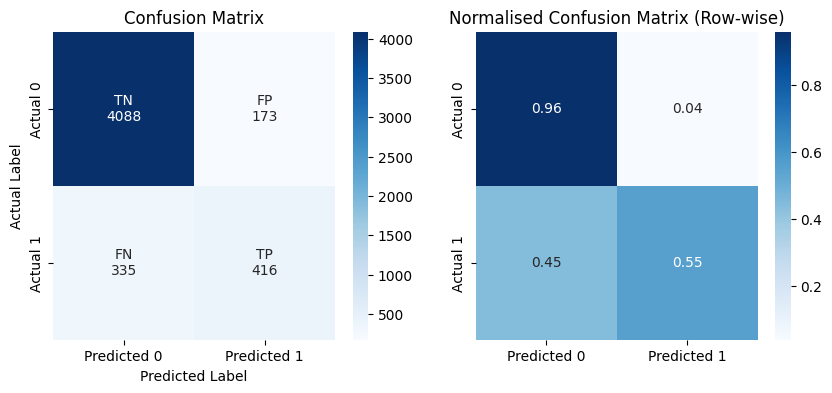

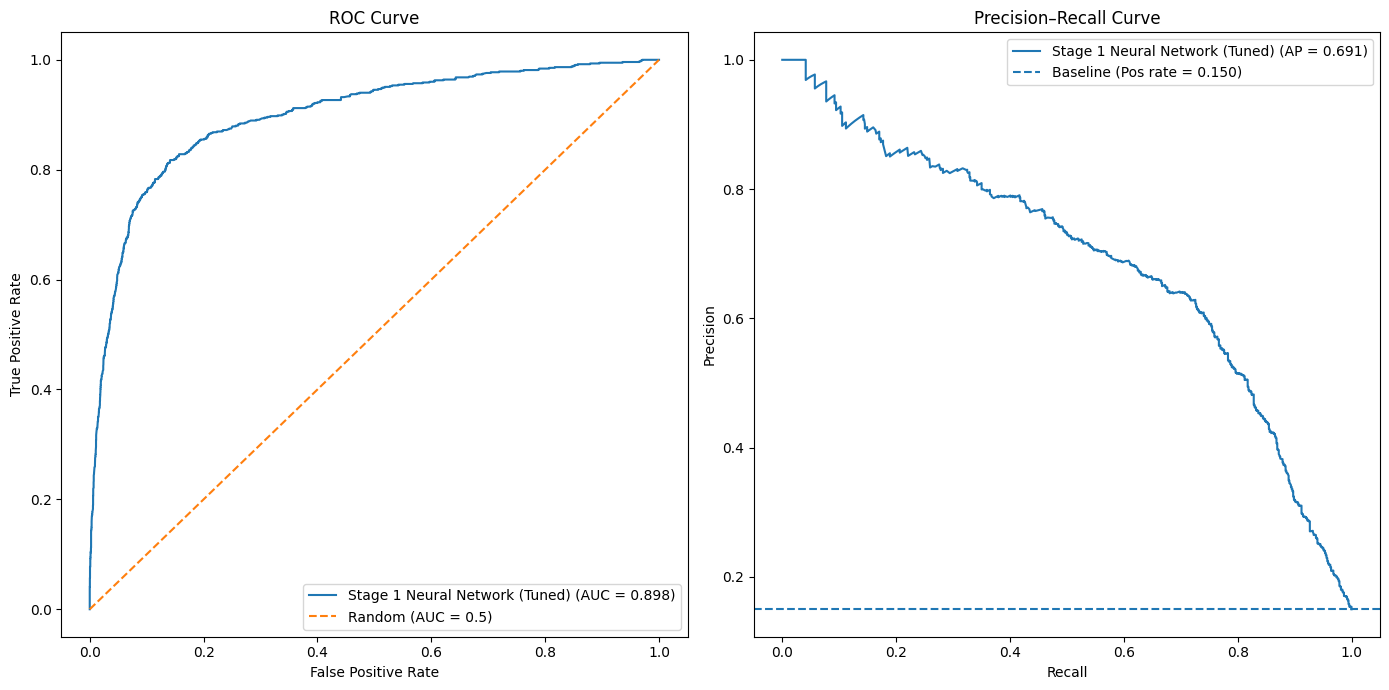

In [103]:
# Predict probabilities
y_prob = model.predict(X_test_s, verbose=0).ravel()
# Convert probabilities to binary predictions using a threshold of 0.5
y_pred = (y_prob >= 0.5).astype(int)

m_id = 4  # unique identifier for this model in the results dictionary

results = evaluate_and_store_model(
    results,
    m_id=m_id,
    model_name="Tuned",
    model_type="Neural Network",
    stage="Stage 1",
    y_true=y_test,
    y_pred=y_pred,
    y_prob=y_prob,
    hyperparameters=config,
    metadata={"threshold": 0.5},
)

# print the evaluation metrics and plot the confusion matrix for the tuned NN model
print_model_metrics(results, m_id)
plot_model_confusion_matrix(results, m_id)

models_to_plot = build_models_to_plot(results, [m_id])
plot_roc_and_pr_curves(models_to_plot, figsize=(14, 7))


### Untuned vs Tuned Comparison

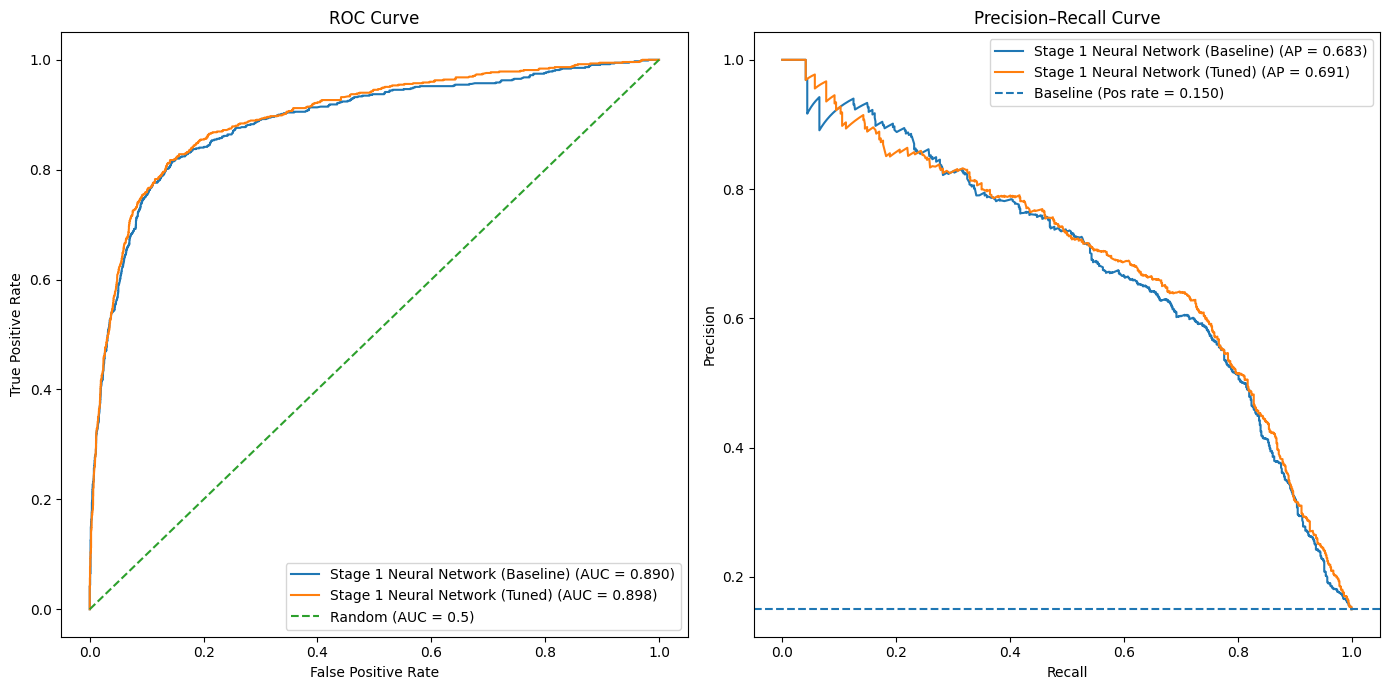

In [104]:
# Finally, we can compare the ROC and Precision-Recall curves for the baseline
# and tuned Neural Network models side by side to see if there has been an
# improvement in performance after hyperparameter tuning.

models_to_plot = build_models_to_plot(results, [3, 4])
plot_roc_and_pr_curves(models_to_plot, figsize=(14, 7))


**Model Comparison (with / without Hyperparameter Tuning)**

---

The tuned neural network performs very similarly to the baseline model, with only small differences across evaluation metrics.

| Metric      | Baseline | Tuned |
|-----------|----------|--------|
| Accuracy    | 0.8951 | **0.8968** |
| Precision   | 0.6687 | **0.6817** |
| Recall      | **0.5939** | 0.5846 |
| Specificity | 0.9481 | **0.9519** |
| AUC         | 0.8902 | **0.8962** |

Hyperparameter tuning results in only a minor change in overall model performance. Validation AUC during tuning was approximately 0.88–0.89, and the final test AUC values are very similar, indicating that the tuned model generalises well but does provide a small improvement over the baseline on AUC, accuracy, precision, and specificity.

The ROC curves for the baseline and tuned models almost overlap, showing that tuning does not materially change the model’s ability to separate dropout and completion cases. The Precision–Recall curve shows only a small difference between the two models.

The tuned model increases precision and specificity, meaning fewer false positives, but this comes at the cost of a small reduction in recall, with slightly fewer dropout cases correctly identified. This indicates that the tuned model makes more conservative predictions while maintaining similar overall discrimination.

Overall, hyperparameter tuning results in only a marginal change in performance for the Stage 1 neural network.

---

